#**PROBLEM STATEMENT**

##**CONTEXT**

We are all aware of how crucial the health care industry is. Since it is closely related to an individual's life, we must constantly be proactive in this domain. Money is critical in this field because, at times, medical care can be extremely expensive, and if a person's insurance does not cover them, they may find themselves in a difficult financial situation. Since we all know that a healthy body is solely the responsibility of the individual, the medical insurance companies also aim to lower their risk by optimising the insurance cost. A person's risk of illness is significantly decreased if they eat a healthy diet and exercise regularly.

# **OBJECTIVE**

This project's goal is to create a model that uses data to determine an individual's optimal insurance cost. For the estimated cost of insurance, we must use the parameters associated with individuals habits and health.

# **Business / Social Opportunity**

- This project **adds great value to the insurance companies and the customers**.

- **For the insurance companies**, the model can be useful in the **proper risk assessment** and determination of the premium price that the customers need to pay. This will help the **companies save from the losses** incurred by the customers who are at a higher risk.

- **For the customers**, the model will **help in the determination of the premium price that the customers need to pay according to their health and lifestyle habits**. This will encourage the customers to adopt healthy habits such as regular exercise and health checkups.

- From a larger perspective, this **solution will help in the development of a more efficient healthcare insurance system** that is accessible and affordable for the customers.

# **DATA DESCRIPTION**

- **applicant_id:** Applicant unique ID.

- **years_of_insurance_with_us:** Since how many years customer is taking policy from the same company only.

- **regular_checkup_lasy_year:** Number of times customers has done the regular health check up in last one year.

- **adventure_sports:** Customer is involved with adventure sports like climbing, diving etc.

- **Occupation:** Occupation of the customer.

- **visited_doctor_last_1_year:** Number of times customer has visited doctor in last one year.

- **cholesterol_level:** Cholesterol level of the customers while applying for insurance.

- **daily_avg_steps:** Average daily steps walked by customers age Age of the customer.


- **Age:** Age of the customer.

- **heart_decs_history:** Any past heart diseases.

- **other_major_decs_history:** Any past major diseases apart from heart like any operation.

- **Gender:** Gender of the customer.

- **avg_glucose_level:** Average glucose level of the customer while applying the insurance.

- **bmi:** BMI of the customer while applying the insurance.

- **smoking_status:** Smoking status of the customer.

- **Year_last_admitted:** When customer have been admitted in the hospital last time.

- **Location:** Location of the hospital.

- **weight:** Weight of the customer.

- **covered_by_any_other_copmpany:** Customer is covered by any other insurance
company.

- **Alcohol:** Alcohol consumption status of the customer.

- **exercise:** Regular exercise status of the customer.

- **weight_change_in_last_one_year:** How much variation has been seen in the weight of the customer in last year.

- **fat_percentage:** Fat percentage of the customer while applying the insurance.

- **insurance_cost:** Total Insurance cost.

# **Data Collection and Background**

- The data set utilized in this project comprises **25,000 data points with 24 features**, focusing on various aspects of an individual's demographic information, medical history, and lifestyle.

- The data appears to be structured to current customers applying for or holding health insurance policies, where each record corresponds to an individual applicant.

- The features in this data set include various numerical and categorical data, such as age, BMI, glucose level, and lifestyle, among others, which are useful in determining an individual's health risks.

- The data set is assumed to be from a system that provides insurance to its customers, and it is useful in determining various factors that affect insurance costs.

- Since the data set's source is unknown, various assumptions have been made about its origin and its usefulness in real-world scenarios.

#**IMPORTING LIBRARIES**

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import matplotlib # Explicitly import matplotlib to access its __version__

# libaries to help with data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Library to split data
from sklearn.model_selection import GridSearchCV, train_test_split


# for scaling
from sklearn.preprocessing import StandardScaler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV


#For Regression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

#Supress warnings
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')


# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()


# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

print('Numpy Version',np.__version__)
print('Pandas Version',pd.__version__)
print('Seaborn Version',sns.__version__)
print('Matplotlib Version',matplotlib.__version__)

Numpy Version 2.0.2
Pandas Version 2.2.2
Seaborn Version 0.13.2
Matplotlib Version 3.10.0


#**DATA OVERVIEW**

**The objective of this step is to get an overview of our dataset by:**

* Observing the first few rows of the dataset, to check whether the dataset has been loaded properly or not.
* Fetching information regarding the number of rows and columns in the dataset.
* Finding out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
* Checking the statistical summary of the dataset to get an overview of the numerical columns of the dataset.

**Upload the dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Data.csv to Data (1).csv


**Reading the dataset**

In [3]:
#reading csv file into a pandas Dataframe
data = pd.read_csv('Data.csv')

# copying data to another variable to avoid any changes to original data
df = data.copy()

**Display Top 5 Rows**

In [4]:
df.head()

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,...,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
0,5000,3,1,1,Salried,2,125 to 150,4866,28,1,...,Unknown,NaN,Chennai,67,N,Rare,Moderate,1,25,20978
1,5001,0,0,0,Student,4,150 to 175,6411,50,0,...,formerly smoked,NaN,Jaipur,58,N,Rare,Moderate,3,27,6170
2,5002,1,0,0,Business,4,200 to 225,4509,68,0,...,formerly smoked,NaN,Jaipur,73,N,Daily,Extreme,0,32,28382
3,5003,7,4,0,Business,2,175 to 200,6214,51,0,...,Unknown,NaN,Chennai,71,Y,Rare,No,3,37,27148
4,5004,3,1,0,Student,2,150 to 175,4938,44,0,...,never smoked,2004.0,Bangalore,74,N,No,Extreme,0,34,29616


**Display Bottom 5 Rows**

In [5]:
df.tail()

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,...,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
24995,29995,3,0,0,Salried,4,225 to 250,5614,22,0,...,smokes,2000.0,Kanpur,79,Y,Rare,Moderate,4,40,39488
24996,29996,6,0,0,Business,4,200 to 225,4719,58,0,...,never smoked,2009.0,Kanpur,66,N,Rare,Moderate,2,28,14808
24997,29997,7,0,1,Student,2,150 to 175,5624,34,0,...,Unknown,NaN,Bhubaneswar,76,N,Rare,Moderate,1,35,33318
24998,29998,1,0,0,Salried,2,225 to 250,10777,27,0,...,Unknown,NaN,Surat,74,N,Rare,Moderate,0,40,30850
24999,29999,8,2,0,Business,4,150 to 175,5882,22,1,...,formerly smoked,2014.0,Chennai,57,N,No,No,4,21,6170


**Checking shape of dataset.**

In [6]:
df.shape

(25000, 24)

**Observations:**

* Dataset has 25,000 rows and 24 columns.

**Checking Data Types**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   applicant_id                    25000 non-null  int64  
 1   years_of_insurance_with_us      25000 non-null  int64  
 2   regular_checkup_lasy_year       25000 non-null  int64  
 3   adventure_sports                25000 non-null  int64  
 4   Occupation                      25000 non-null  object 
 5   visited_doctor_last_1_year      25000 non-null  int64  
 6   cholesterol_level               25000 non-null  object 
 7   daily_avg_steps                 25000 non-null  int64  
 8   age                             25000 non-null  int64  
 9   heart_decs_history              25000 non-null  int64  
 10  other_major_decs_history        25000 non-null  int64  
 11  Gender                          25000 non-null  object 
 12  avg_glucose_level               

In [8]:
# Identify Numerical Columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# Identify Categorical (and other non-numeric) Columns
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()

# Print summary of data types
print(f"Total Numerical Columns: {len(num_cols)}")
print(f"Numerical List: {num_cols}")
print("-" * 30)
print(f"Total Categorical Columns: {len(cat_cols)}")
print(f"Categorical List: {cat_cols}")

Total Numerical Columns: 16
Numerical List: ['applicant_id', 'years_of_insurance_with_us', 'regular_checkup_lasy_year', 'adventure_sports', 'visited_doctor_last_1_year', 'daily_avg_steps', 'age', 'heart_decs_history', 'other_major_decs_history', 'avg_glucose_level', 'bmi', 'Year_last_admitted', 'weight', 'weight_change_in_last_one_year', 'fat_percentage', 'insurance_cost']
------------------------------
Total Categorical Columns: 8
Categorical List: ['Occupation', 'cholesterol_level', 'Gender', 'smoking_status', 'Location', 'covered_by_any_other_company', 'Alcohol', 'exercise']


**Observations:**

***Data Types:***
*  ***There are 8 categorical variables with object data type***: 'Occupation', 'cholesterol_level', 'Gender', 'smoking_status', 'Location', 'covered_by_any_other_company', 'Alcohol', 'exercise'.

* ***There are only 16 numerical variables with "int" and "float" data types***: 'applicant_id', 'years_of_insurance_with_us', 'regular_checkup_lasy_year', 'adventure_sports', 'visited_doctor_last_1_year', 'daily_avg_steps', 'age', 'heart_decs_history', 'other_major_decs_history', 'avg_glucose_level', 'bmi', 'Year_last_admitted', 'weight', 'weight_change_in_last_one_year', 'fat_percentage', 'insurance_cost' (***target variable***).

* There is a spelling mistake in the column name "regular_checkup_lasy_year", which we will fix in data cleaning stage.

**Checking Statistical Summary**

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
applicant_id,25000.0,17499.500000,7217.022701,5000.0,11249.75,17499.5,23749.25,29999.0
years_of_insurance_with_us,25000.0,4.089040,2.606612,0.0,2.00,4.0,6.00,8.0
regular_checkup_lasy_year,25000.0,0.773680,1.199449,0.0,0.00,0.0,1.00,5.0
adventure_sports,25000.0,0.081720,0.273943,0.0,0.00,0.0,0.00,1.0
visited_doctor_last_1_year,25000.0,3.104200,1.141663,0.0,2.00,3.0,4.00,12.0
daily_avg_steps,25000.0,5215.889320,1053.179748,2034.0,4543.00,5089.0,5730.00,11255.0
age,25000.0,44.918320,16.107492,16.0,31.00,45.0,59.00,74.0
heart_decs_history,25000.0,0.054640,0.227281,0.0,0.00,0.0,0.00,1.0
other_major_decs_history,25000.0,0.098160,0.297537,0.0,0.00,0.0,0.00,1.0
avg_glucose_level,25000.0,167.530000,62.729712,57.0,113.00,168.0,222.00,277.0


**Observations:**

***Applicant ID (applicant_id):***

* The average applicant ID is 17,499, with a standard deviation of 7,217. This is normal because it is just a sequential number.
* The minimum and maximum values are between 5,000 and 29,999, which shows that it is an index-like column and doesn't have any analytical value.
* The first quartile (Q1) is 11,249.75 and the third quartile (Q3) is approximtely 23,749, giving an interquartile range (IQR) of 12,500.
* This feature should be removed from the model because it doesn't help with prediction.

***Years of Insurance with Us (years_of_insurance_with_us):***

* The average length of time is about four years, with a standard deviation of about 2.6.
* The lowest number is 0, which means new customers, and the highest number is 8 years.
* A lot of the company's customers are new, with 75% of them having been with the company for 6 years or less.
* The IQR is 6 to 2, which is 4 years, indicating 50% of customers have been associated with the company between 2 and 6 years, suggesting moderate spread.


***Regular Checkups Last Year (regular_checkup_lasy_year):***

* The average number of checkups is 0.77, which means that most customers don't get regular health checkups very often.
* The median is 0, which means that more than half of the customers did not have a checkup.
* The highest value is 5, which means that there are a few people who care about their health.
* The IQR is 1 - 0, which is 1, suggesting very low variability.


***Sports for Adventure (adventure_sports):***

* This is a binary feature with a mean of 0.08, which means that only about 8% of customers take part in adventure sports.
* The IQR is 0 because all quartiles (Q1, Q2, and Q3) are 0.
* This shows that the distribution is very unbalanced, with most customers not doing high-risk things.


***Last Year's Doctor Visits (visited_doctor_last_1_year):***

* The average number of times people go to the doctor is 3.10, and the standard deviation is 1.14.
* The numbers can be anywhere from 0 to 12 visits.
* The interquartile range (IQR) is 4 to 2, equal to 2 years, which means that the data is not very variable.
* In the past year, most customers saw a doctor between two and four times.


***Average Daily Steps (daily_avg_steps):***

* The average number of steps taken each day is about 5,216, with a standard deviation of 1,053.
* The numbers go from 2,034 to 11,255.
* The interquartile range (IQR) is 5,730 - 4,543, which is equal to 1,187 steps, which means that the data is spread out fairly evenly.
* This indicates differences in levels of physical activity among people.


***Heart Disease History (heart_decs_history):***

* This is a binary variable with a mean of 0.054, implying that 5.4% of the customers have heart disease.
* All quartiles are equal to 0, hence IQR is also 0.
* This is evidence of a strong imbalance in favor of people without heart disease.


***Other Major Disease History (other_major_decs_history):***

* The mean is equal to 0.098, implying that 9.8% of the customers have had major diseases.
* All quartiles are equal to 0, hence IQR is zero.
* This is evidence of a strong imbalance in favor of people without major diseases.


***Average Glucose Level (avg_glucose_level):***

* The average glucose level is  approximately around 167, with a high standard deviation of 62.73.
* The values range from 57 to 277.
* The interquartile range (IQR) is 222 - 113 , which is equal to 109 of glucose level, indicating substantial variability.
* This indicates the presence of both normal and high-risk individuals, with potential outliers.


***BMI (bmi):***

* The average is 31.39, and the standard deviation is 7.88.
* The range is from 12.3 to 100.6.
* The interquartile range (IQR) is from 35.6 - 26.1, i.e., approximately 9.5, showing moderate variation.
* The maximum is extremely high and not realistic, indicating errors in entering the data.
* Also, we observed some missing values, thus proper imputation is required.


***Year Last Admitted (Year_last_admitted):***

* The average is 2003.89, and the standard deviation is 7.58.
* The range is from 1990 to 2018.
* The interquartile range (IQR) is from 2010 to 1997, i.e., approximately 13 years, showing moderate variation.
* There is significant missing data, i.e., approximately 48%, indicating that many people may not have been hospitalized.


***Weight (weight):***

* The average is 71.61, and the standard deviation is 9.33.
* The range is from 52 to 96.
* The interquartile range (IQR) is from 78 - 64, i.e., approximately 14, showing moderate variation.
* There are no significant anomalies in the data.


***Weight Change in Last One Year (weight_change_in_last_one_year):***

* The average weight change is 2.52, and the standard deviation is 1.69.
* The values range from 0 to 6.
* The interquartile range (IQR) is 4 - 1 = 3, indicating that the variability is under control.
* This indicates that the weight changes for the population are moderate and consistent.


***Fat Percentage (fat_percentage):***

* The average fat percentage is 28.81%, and the standard deviation is 8.63.
* The values range from 11% to 42%.
* The interquartile range (IQR) is from 36 to 21, which is equal to 15.
* The values seem realistic for the population.


***Conclusion and Inference:***

* The dataset provided appears to be structured and has the necessary demographic, medical, and lifestyle information to effectively predict insurance costs.

* There are some data quality issues to be addressed, including missing information in BMI and Year_last_admitted, as well as outliers in BMI and avg_glucose_level.

* There are several binary variables that are imbalanced, and insurance_cost and avg_glucose_level have high variability.

* Overall, this dataset has the potential to effectively predict insurance costs after handling missing information, outliers, and binary variables, and the key factors that would likely impact insurance costs would be lifestyle and health factors.





**Converting object-type columns to the category data type helps reduce memory usage.**

In [10]:
cols = df.select_dtypes(['object'])
print(cols.columns)

for i in cols.columns:
    df[i] = df[i].astype('category')

print("-" * 30)

df.info()

Index(['Occupation', 'cholesterol_level', 'Gender', 'smoking_status',
       'Location', 'covered_by_any_other_company', 'Alcohol', 'exercise'],
      dtype='object')
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   applicant_id                    25000 non-null  int64   
 1   years_of_insurance_with_us      25000 non-null  int64   
 2   regular_checkup_lasy_year       25000 non-null  int64   
 3   adventure_sports                25000 non-null  int64   
 4   Occupation                      25000 non-null  category
 5   visited_doctor_last_1_year      25000 non-null  int64   
 6   cholesterol_level               25000 non-null  category
 7   daily_avg_steps                 25000 non-null  int64   
 8   age                             25000 non-null  int64   
 9   heart_

**Observations:**

* We can observe that the memory usage has decreased from 4.6+ MB to 3.2 MB, this technique is generally useful for bigger datasets.



**Checking Unique Values & Counts**

In [11]:
unique_counts = df.nunique()
print("Unique values are:")
print(unique_counts)

# Loop through categorical columns and display their unique values
cat_cols = df.select_dtypes(include='category').columns

for col in cat_cols:
    print("-" * 30)
    print(f"\nColumn: {col}")
    print(df[col].unique())

Unique values are:
applicant_id                      25000
years_of_insurance_with_us            9
regular_checkup_lasy_year             6
adventure_sports                      2
Occupation                            3
visited_doctor_last_1_year           12
cholesterol_level                     5
daily_avg_steps                    4914
age                                  59
heart_decs_history                    2
other_major_decs_history              2
Gender                                2
avg_glucose_level                   221
bmi                                 465
smoking_status                        4
Year_last_admitted                   29
Location                             15
weight                               45
covered_by_any_other_company          2
Alcohol                               3
exercise                              3
weight_change_in_last_one_year        7
fat_percentage                       32
insurance_cost                       54
dtype: int64
--------

In [12]:
for i in cat_cols:
    print('Unique values in',i, 'are :')
    print(df[i].value_counts())
    print('*'*50)

Unique values in Occupation are :
Occupation
Student     10169
Business    10020
Salried      4811
Name: count, dtype: int64
**************************************************
Unique values in cholesterol_level are :
cholesterol_level
150 to 175    8763
125 to 150    8339
200 to 225    2963
175 to 200    2881
225 to 250    2054
Name: count, dtype: int64
**************************************************
Unique values in Gender are :
Gender
Male      16422
Female     8578
Name: count, dtype: int64
**************************************************
Unique values in smoking_status are :
smoking_status
never smoked       9249
Unknown            7555
formerly smoked    4329
smokes             3867
Name: count, dtype: int64
**************************************************
Unique values in Location are :
Location
Bangalore      1742
Jaipur         1706
Bhubaneswar    1704
Mangalore      1697
Delhi          1680
Ahmedabad      1677
Guwahati       1672
Chennai        1669
Kanpur         1664


In [13]:
df.describe(include=['category']).T

,count,unique,top,freq
Occupation,25000,3,Student,10169
cholesterol_level,25000,5,150 to 175,8763
Gender,25000,2,Male,16422
smoking_status,25000,4,never smoked,9249
Location,25000,15,Bangalore,1742
covered_by_any_other_company,25000,2,N,17418
Alcohol,25000,3,Rare,13752
exercise,25000,3,Moderate,14638


**Observations:**


***Unique Value Analysis***

The dataset consists of a combination of low, moderate, and high cardinality features.

   - ***High cardinality features:***
  
     - **applicant_id (25,000 unique)** - This feature acts as an identifier and needs to be dropped.
     - **daily_avg_steps, bmi, avg_glucose_level** - These are continuous variables and have high variability.
     
   - **Moderate cardinality features:**
      - age (59), weight (45), fat_percentage (32), insurance_cost (54).
      - These are good examples of numerical variability.

   - ***Low cardinality/categorical features:***
     
      - Binary variables such as adventure_sports, heart_decs_history, Gender, covered_by_any_other_company have limited variability.
      - Features such as Occupation, Alcohol, exercise, smoking_status have limited distinct values.


***Categorical Feature Insights***

***Occupation:***
 - Has 3 categories: Salaried, Student, Business.
 - An inconsistency in the spelling of one category, “Salried,” is noted. This would be addressed in the preprocessing step.

***cholesterol_level:***
 - Has ordered categories, e.g., “125-150” and “150-175.”
- This feature is ordinal and should be treated as such, rather than being one-hot encoded.

***Gender:***
 - Binary feature with clean and consistent categories: Male, Female.

***smoking_status:***
 - Has 4 categories, one of which is 'Unknown' and others are 'formerly smoked', 'never smoked', 'smokes'..”

***Location:***
* Has 15 categories corresponding to city names. This feature exhibits moderate diversity.
* Location may be encoded in ways such as one-hot encoding or target encoding, depending on the model.

***covered_by_any_other_company:***
 - Binary feature with clean and consistent categories: Y/N.

***Alcohol Consumption (Alcohol):***
 - Has ordinal categories such as “No,” “Rare,” and “Daily.”

***Exercise:***
 - Also ordinal, with categories “No,” “Moderate,” and “Extreme.”


 **Insights:**
- Top region is Bangalore.
- Top occupation found to be student.
- There are more male customers as compared to female.

##**Initial Data Inspection and Preparation**

###**Dropping Unnecessary Variables**

We dropped the applicant_id column because it is a unique identifier and will not be useful for prediction.

In [14]:
# we will copy the original dataset to preserve it.
df1 = df.copy()

#dropping case_id
df1.drop(['applicant_id'], axis = 1, inplace=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   years_of_insurance_with_us      25000 non-null  int64   
 1   regular_checkup_lasy_year       25000 non-null  int64   
 2   adventure_sports                25000 non-null  int64   
 3   Occupation                      25000 non-null  category
 4   visited_doctor_last_1_year      25000 non-null  int64   
 5   cholesterol_level               25000 non-null  category
 6   daily_avg_steps                 25000 non-null  int64   
 7   age                             25000 non-null  int64   
 8   heart_decs_history              25000 non-null  int64   
 9   other_major_decs_history        25000 non-null  int64   
 10  Gender                          25000 non-null  category
 11  avg_glucose_level               25000 non-null  int64   
 12  bmi               

In [15]:
df1.shape

(25000, 23)

**Observations:**

- We can observe **applicant_id** has been dropped.
- Now, we have 25000 rows and **23 columns**.


###**Checking for duplicate values**

In [16]:
df1.duplicated().sum()

np.int64(0)

**Observations:**
-  There are no duplicates in our dataset. This indicates data is fit to do further analysis.



###**Checking Missing Values**

In [17]:
print("Missing values:")
df1.isnull().sum()

Missing values:


,0
years_of_insurance_with_us,0
regular_checkup_lasy_year,0
adventure_sports,0
Occupation,0
visited_doctor_last_1_year,0
cholesterol_level,0
daily_avg_steps,0
age,0
heart_decs_history,0
other_major_decs_history,0


**Observations:**
- There are missing values in the columns **bmi(990)** and **Year_last_admitted (11881)** of the dataset.

In [18]:
# Identify numerical columns in df1
numerical_cols_df1 = df1.select_dtypes(include=np.number).columns.tolist()

# Check for negative values only in numerical columns
negative_counts = (df1[numerical_cols_df1] < 0).sum()

# Filter out columns with no negative values for cleaner output
negative_counts = negative_counts[negative_counts > 0]

print("Number of rows with negative values:")
if not negative_counts.empty:
    print(negative_counts)
else:
    print("No negative values found in numerical columns.")

Number of rows with negative values:
No negative values found in numerical columns.


**Observations:**
- No negative values found in numerical columns

###**Insights on initial inspection**

- During the initial data inspection phase, unnecesary features like applicant_id were removed as they have no predictive value and may cause data leakage.
- A new copy of the dataset was created to verify that the original data did not change.

#**EXPLORATORY DATA ANALYSIS**

##**EDA Functions**

* We will define functions below to carry out EDA.

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Function for combined histogram and box plots.
def custplot_box_hist(
    df_copy,
    column_name,
    figure_size=(10,6),
    show_kde=False,
    num_bins=20,
    box_color=None,
    hist_color=None
):
    """
    Combined boxplot + histogram for a numeric column.

    Parameters
    ----------
    df_copy : pandas.DataFrame
        DataFrame to plot.
    column_name : str
        Column to visualise.
    figure_size : tuple, optional
        Overall figure size (default (10, 6)).
    show_kde : bool
        Overlay a KDE curve on the histogram.
    num_bins : int, optional
        Number of histogram bins (default 20).
    box_color : str or None
        Colour for the boxplot (name like 'violet', 'skyblue', etc).
    hist_color : str or None
        Colour for the histogram (name or palette color).
    """

    fig, (box_ax, hist_ax) = plt.subplots(
        nrows=2,
        sharex=True,
        figsize=figure_size,
        gridspec_kw={"height_ratios": [1, 3]}
    )

    # ── Boxplot ──
    sns.boxplot(
        x=df_copy[column_name],
        ax=box_ax,
        showmeans=True,
        color=box_color,
        meanprops={"marker": "o", "markerfacecolor": "gold"} # boxplot will be created and a "o" will indicate the mean value of the column
    )
    box_ax.set(title=f"Boxplot and Histogram of {column_name}", xlabel="")

    # ── Histogram ──
    sns.histplot(
        df_copy[column_name],
        ax=hist_ax,
        bins=num_bins,
        kde=show_kde,
        color=hist_color
    )

    # Mean and Median lines
    hist_ax.axvline(df_copy[column_name].mean(),   color="red", linestyle="--", label="Mean")
    hist_ax.axvline(df_copy[column_name].median(), color="black", linestyle="-",  label="Median")
    hist_ax.legend()

    plt.tight_layout()
    plt.show()
    plt.close(fig)


In [20]:
# function to create labeled barplots
def cust_label_barplot(
    df_copy,
    column_name,
    figure_size=(10, 6),
    show_percent=False,
    top_n=None,
    palette=None        # for any matplotlib/seaborn colour or palette
):
    """
    Barplot of a categorical feature with count/percentage labels.

    Parameters
    ----------
    df_copy : pandas.DataFrame
        DataFrame to plot.
    column_name : str
        Categorical column to visualise.
    figure_size : tuple, optional
        Figure size in inches (default (10, 6)).
    show_percent : bool, optional
        If True, show percentages; else show counts.
    top_n : int or None, optional
        Limit to the top‑N most frequent categories.
    palette : str, list, dict or None, optional
        Colour palette (e.g. "Set2", ["skyblue","orange"], {"A":"teal",…}).
        If None, Seaborn’s default colour cycle is used.

    """
    print(df_copy[column_name].value_counts(dropna=False))
    print("\n")

    # order the categories by frequency, optionally truncate to top_n
    category_order = df_copy[column_name].value_counts().index[:top_n]
    bar_count      = len(category_order)


    # set up the fig size with dynamic width
    plt.figure(figsize=(max(bar_count + 2, figure_size[0]), figure_size[1]))

    # draw the bars
    ax = sns.countplot(
        data=df_copy,
        x=column_name,
        order=category_order,
        palette=palette,
    )

    # tidy x‑axis labels
    plt.xticks(rotation=45, fontsize=10)
    if ax.get_legend() is not None:
        ax.legend_.remove()     # each bar is self‑explanatory

    # annotate bars
    total = len(df_copy[column_name])
    for bar in ax.patches:
        height = bar.get_height()
        label  = f"{(height / total) * 100:.1f}%" if show_percent else f"{height}"
        x      = bar.get_x() + bar.get_width() / 2
        ax.annotate(
            label, (x, height),
            ha="center", va="bottom",
            fontsize=12,
            xytext=(0,3), textcoords="offset points" # offset to move labels within plot boundry
        )

    plt.tight_layout()
    plt.show()

    plt.close(ax.figure)        # prevents duplicate plots

In [21]:
def stacked_barplot_custom(data, predictor, target, palette='Set2'):
    """
    Creates a normalized stacked bar plot for a categorical predictor and target variable.
    Displays the raw counts and the proportional distribution.

    Parameters:
    - data (pd.DataFrame): The input dataset
    - predictor (str): The categorical independent variable to group by (x-axis)
    - target (str): The categorical target variable (segments within each bar)
    - palette (str or list): Color palette name or list of hex codes (default: 'Set2')
    """

    # Determine the number of unique categories in predictor to size the figure dynamically
    category_count = data[predictor].nunique()

    # Generate a cross-tabulation (raw counts) of predictor vs target
    raw_counts = pd.crosstab(data[predictor], data[target], margins=True)
    print(raw_counts)
    print("-" * 100)

    # Normalize the crosstab row-wise to get proportions within each predictor category
    normalized_counts = pd.crosstab(data[predictor], data[target], normalize='index')

    # Identify the least frequent target class to sort categories by it (helps consistency)
    least_frequent_class = data[target].value_counts().index[-1]
    normalized_sorted = normalized_counts.sort_values(by=least_frequent_class, ascending=False)

    # Select a color palette based on the number of target classes
    num_classes = normalized_sorted.shape[1]
    colors = sns.color_palette(palette, n_colors=num_classes)

    # Plot the normalized stacked bar chart
    ax = normalized_sorted.plot(
        kind='bar',
        stacked=True,
        figsize=(category_count + 5, 5),
        color=colors
    )

    # Add labels and adjust layout
    plt.xlabel(predictor)
    plt.ylabel('Proportion')
    plt.title(f"Stacked Bar Plot: {predictor} vs {target}")
    plt.xticks(rotation=45)

    # Move legend outside the plot and format it
    plt.legend(title=target, loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

    # Ensure layout is not clipped
    plt.tight_layout()

    # Display the plot
    plt.show()

    # Close the plot to prevent it from being duplicated in notebooks
    plt.close(ax.figure)


##**Univariate Analysis**

**We do univariate analysis on individual columns to understand the their distributions, trends and to find anomalies like outliers.
We perform analysis on all numerical columns and all categorical columns separately because numerical and categorical variables have fundamentally different mathematical properties and call for different statistical measures, data cleaning strategies, and visualisation techniques.**

###**Univariate Analysis on numerical variables**

- We will now do univariate analysis on numerical columns to analyse their distributions.

***fat_percentage***

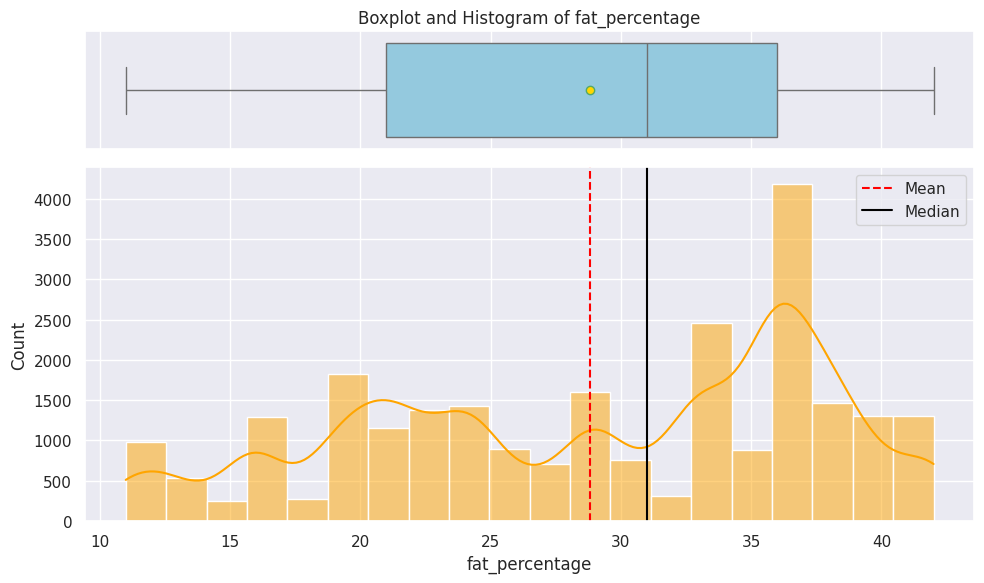

In [22]:
custplot_box_hist(df1, "fat_percentage", show_kde=True, box_color="skyblue", hist_color="orange")

In [23]:
df1["fat_percentage"].describe()

,fat_percentage
count,25000.000000
mean,28.812280
std,8.632382
min,11.000000
25%,21.000000
50%,31.000000
75%,36.000000
max,42.000000


**Observations:**

- The mean of the data is around 28.8%, and the standard deviation is 8.63, which represents a moderately varying data set.
- The data varies between 11% and 42%, which is a realistic data range for the general population.
- Since the median (31%) is slightly greater than the mean, it represents a slightly left-skewed data distribution.
- From the histogram, it is observed that most of the individuals are clustered in the higher range of fat percentage, i.e., between 30% and 38%.
- Since there are no significant extreme values in the data, as observed in the boxplot, the data is relatively stable.

**Insights:**
- Since most of the individuals are in the high body fat percentage range, which represents the moderate to high level of health risks, the data may be significant.
- Since the fat percentage is directly related to health conditions, it may be considered a significant predictor of insurance costs, as the percentage may be on the higher side.


***avg_glucose_level***

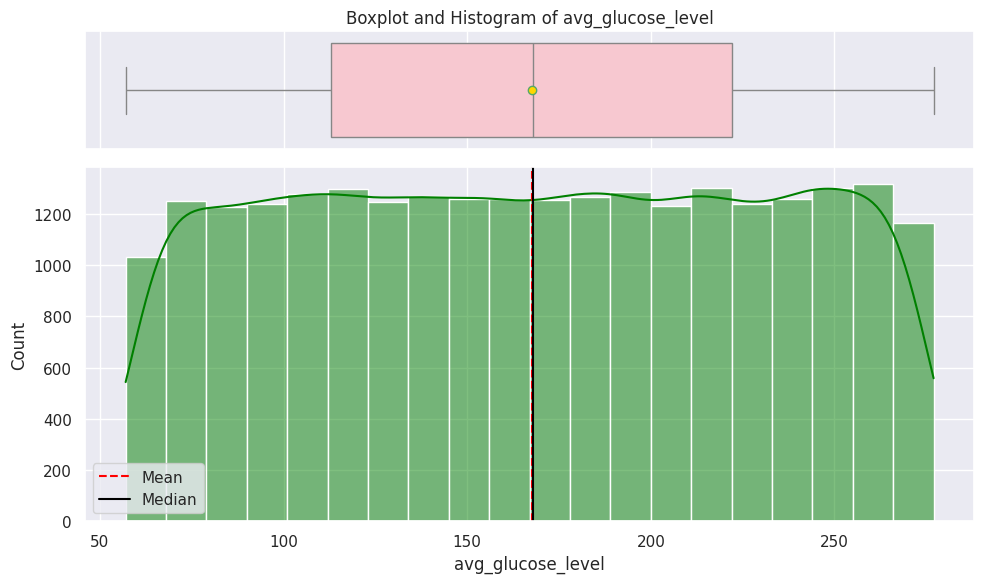

In [24]:
custplot_box_hist(df1, "avg_glucose_level", show_kde=True, box_color="pink", hist_color="green")

In [25]:
df1["avg_glucose_level"].describe()

,avg_glucose_level
count,25000.000000
mean,167.530000
std,62.729712
min,57.000000
25%,113.000000
50%,168.000000
75%,222.000000
max,277.000000


**Observations:**

- The average is approximately 167.5 with considerable variability (standard deviation approximately 62.7).
- The data points vary widely between 57 and 277.
- The average and median are almost equal, suggesting a symmetric distribution.
- From the histogram, we can infer that the data is fairly distributed over the range with little evidence of peaks or skewing.
- The boxplot also shows that the data is widely distributed with little sign of extreme outliers.

**Insights:**
- The data set comprises a broad spectrum of individuals with varying glucose levels, possibly including diabetics.
- This data is likely to be a good predictor for insurance costs because higher glucose levels imply a higher risk for medical complications.

***daily_avg_steps***

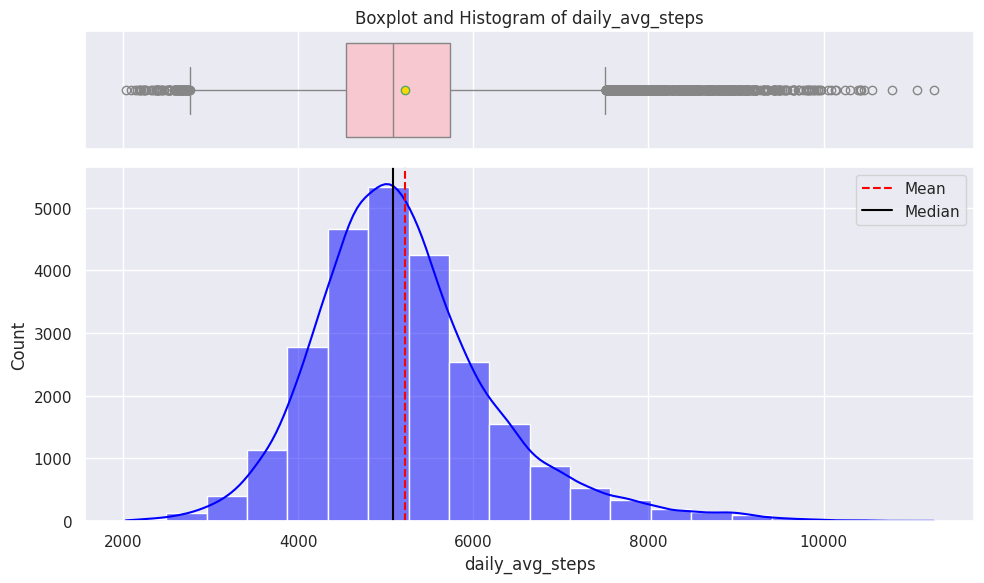

In [26]:
custplot_box_hist(df1, "daily_avg_steps", show_kde=True, box_color="pink", hist_color="blue")

In [27]:
df1["daily_avg_steps"].describe()

,daily_avg_steps
count,25000.000000
mean,5215.889320
std,1053.179748
min,2034.000000
25%,4543.000000
50%,5089.000000
75%,5730.000000
max,11255.000000


**Observations:**

- The average daily steps are approximately 5,216 with a standard deviation of around 1,053.
- The data ranges from a minimum of 2,034 steps to a maximum of 11,255 steps.
- The median is slightly lower than the average at around 5,089.
- The data is slightly skewed to the right with a majority of individuals having daily steps between 4,500 and 5,700.
- The plot also indicates that there are a few individuals with high daily steps; however, there are no clear outliers in the data using the boxplot.

**Insights:**
- The majority of individuals appear to fall under a moderately active category.
- Physical activity is inversely related to health risks; therefore, daily steps are likely to have a negative relationship with insurance cost.

***BMI***

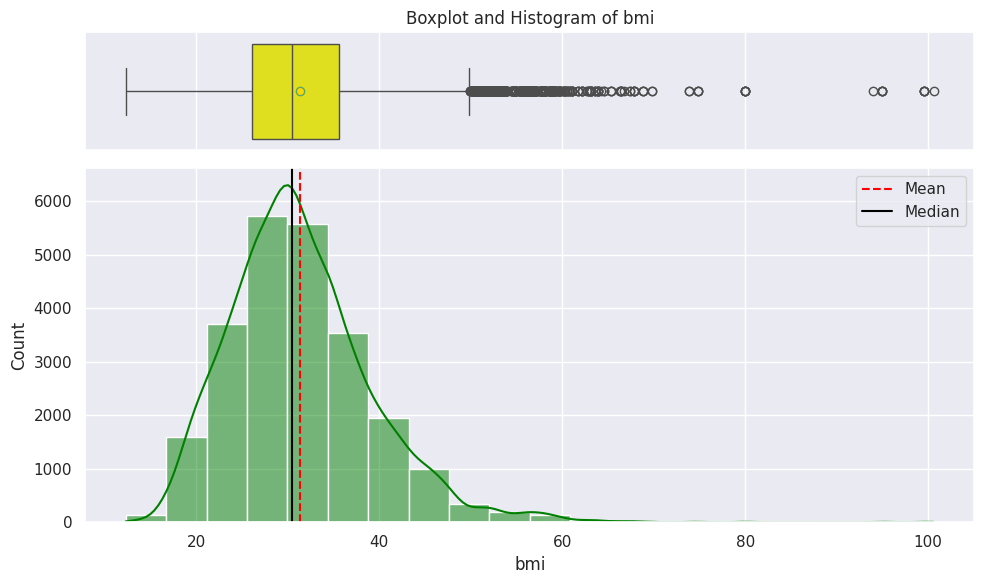

In [28]:
custplot_box_hist(df1, "bmi", show_kde=True, box_color="yellow", hist_color="green")

In [29]:
df1["bmi"].describe()

,bmi
count,24010.000000
mean,31.393328
std,7.876535
min,12.300000
25%,26.100000
50%,30.500000
75%,35.600000
max,100.600000


**Observations:**

- On average, the BMI is 31.39, and the standard deviation is 7.88.
- The range is between a minimum of 12.30 and a maximum of 100.60.
- The median is slightly lower than the average, which is 30.50.
- The data is skewed towards the right, and most individuals have a BMI between 26.10 and 35.60, which is the interquartile range.
- The plot also suggests that there are a few individuals who have very high values of BMI.
- This is different from the sample data, as the boxplot clearly shows that there is a large number of outliers on the higher end of the distribution.


**Insights:**

- It appears that most individuals fall within the overweight and obese category, as the median is higher than 30.
- Body Mass Index (BMI) is generally directly proportional to health risks, so it is likely that the BMI will have a positive relationship with insurance costs or medical expenditures.

- The maximum value of 100.60 is highly improbable, suggesting that there is exception case of obesity or some error in the data, which is a common case where data inspection & cleaning is necessary.

- Moreover, there are 990 missing values in the variable "bmi". To avoid losing any of this information, the missing values will be handled by applying a method of imputation, as will be discussed in the Data Preprocessing section. This will also assist in stabilizing the distribution.

***insurance_cost (Target variable)***

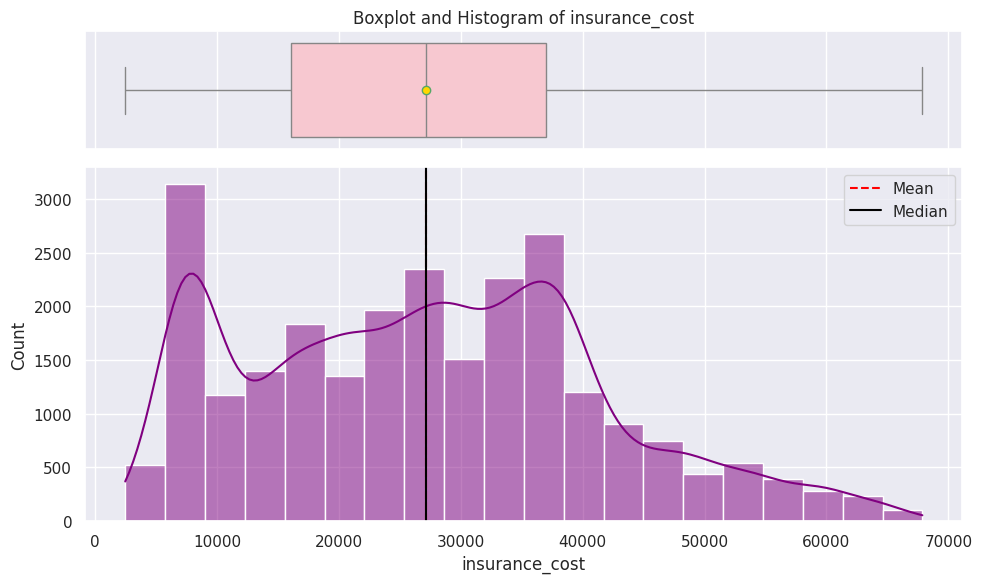

In [30]:
custplot_box_hist(df1, "insurance_cost", show_kde=True, box_color="pink", hist_color="purple")

In [31]:
df1["insurance_cost"].describe()

,insurance_cost
count,25000.000000
mean,27147.407680
std,14323.691832
min,2468.000000
25%,16042.000000
50%,27148.000000
75%,37020.000000
max,67870.000000


**Observations:**

- The average insurance cost is around 27,147.41, with a standard deviation of around 14,323.69.
- The data ranges from a minimum insurance cost of 2,468 up to a maximum of 67,870.
- The median is almost similar to the average at around 27,148.
- The data is quite broad with a majority of individuals having their insurance costs between 16,042 and 37,020.
- The plot shows a multimodal distribution with multiple peaks.
- The boxplot also shows that there are no outliers; therefore, the high insurance costs are part of the data's normal extension.

**Insights:**

- The data for insurance costs is extremely diverse with a non-normal distribution.
- The data is multimodal with peaks at around 7,000 to 8,000 and another peak at around 35,000 to 38,000.
- This may imply that the data consists of multiple groups of individuals.
- The fact that the median is almost similar to the average implies that the data is almost perfectly symmetric with no skewness.

***weight***

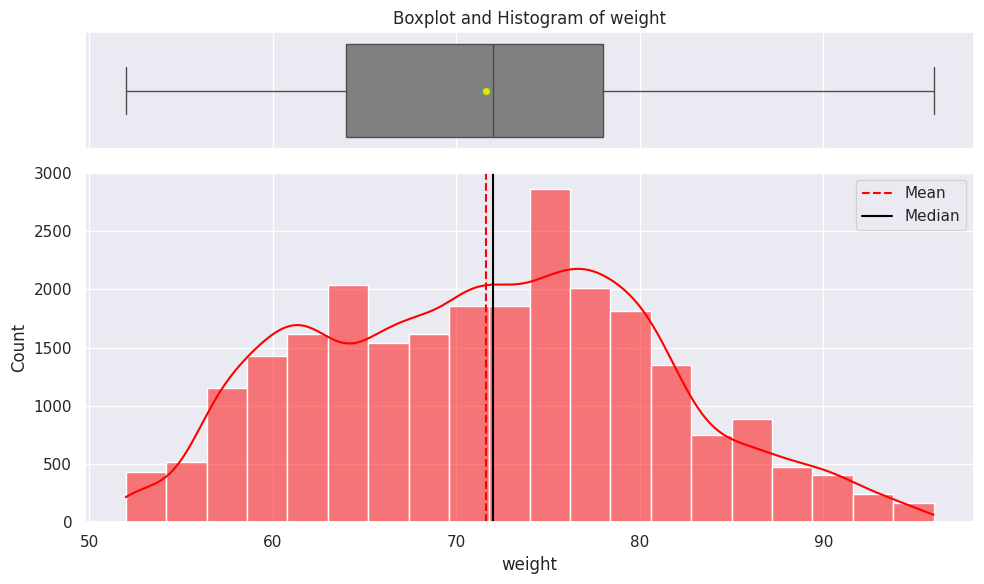

In [32]:
custplot_box_hist(df1, "weight", show_kde=True, box_color="gray", hist_color="red")

In [33]:
df1["weight"].describe()

,weight
count,25000.000000
mean,71.610480
std,9.325183
min,52.000000
25%,64.000000
50%,72.000000
75%,78.000000
max,96.000000


**Observations:**

- On average, the weight is around 71.61 units, and the standard deviation is around 9.33 units.
- The minimum weight is 52 units, and the maximum is 96 units.
- The median is slightly higher than the average at 72 units.
- There is a slight skewness to the left; however, the majority of the individuals fall between 64 units and 78 units (interquartile range).
- here are also a number of peaks; however, there are no statistical outliers according to the box plot.

**Insights:**

- There are a number of peaks in the distribution (for example, 64 units and 75 units), which may indicate the presence of a number of subpopulations (for example, males and females, short and tall individuals).
- However, the proximity between the mean (71.61 units) and median (72 units) suggests that even though the peaks are present, the overall distribution is balanced and symmetrical without a high skewness.
- There are no statistical outliers; the range (52 units to 96 units) is well within the normal limits for human beings.

***regular_checkup_lasy_year***

regular_checkup_lasy_year
0    15215
1     4644
2     2198
3     1818
4      777
5      348
Name: count, dtype: int64




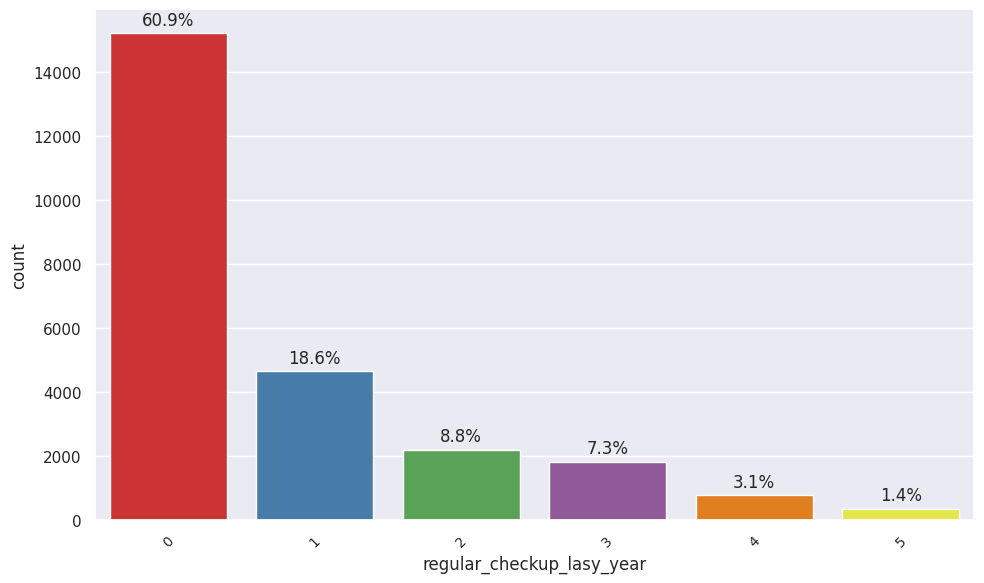

In [34]:
cust_label_barplot(df1, "regular_checkup_lasy_year", palette="Set1", show_percent=True)

**Observations:**

- The mean number of regular checkups is about 0.77, and the standard deviation is about 1.13.
- The data varies between a minimum of 0 checkups and reaches up to a maximum of 5 checkups.
- The median number of checkups is also 0.
- There is significant skewness to the right, indicating that most individuals have fewer than 5 checkups, with the vast majority of individuals (about 79.5% of the total population) having either 0 or 1 checkups.
- From the plot, the data points are decreasing sharply as the number of checkups increases, and only a small percentage of individuals (1.4%) have attended 5 checkups last year.

**Insights:**

- There is a large number of individuals who have zero checkups (about 60.9%), indicating that the level of preventative care is low.
- It is generally understood that regular health checkups are important for early disease treatment and can result in reduced healthcare costs in the future; as such, the number of individuals with zero checkups may have a positive relationship with the costs of future insurance.


***years_of_insurance_with_us***

years_of_insurance_with_us
3    2990
8    2970
5    2941
0    2912
7    2873
1    2856
4    2846
6    2804
2    1808
Name: count, dtype: int64




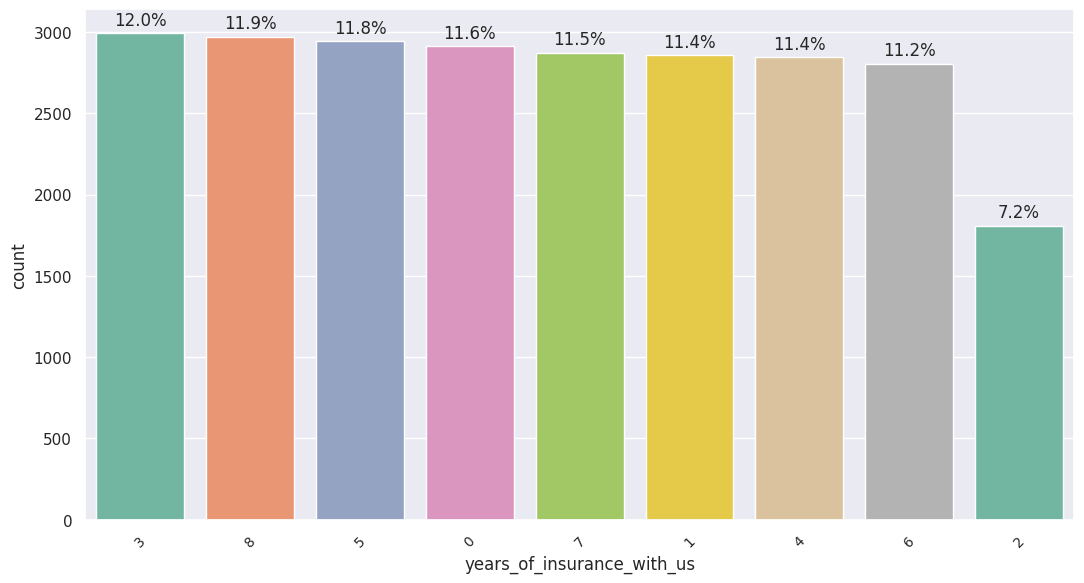

In [35]:
cust_label_barplot(df1, "years_of_insurance_with_us", palette="Set2", show_percent=True)

**Observations:**

- The average years of insurance tenure is around 4.23, and the standard deviation is around 2.62.

- The data varies between the minimum of 0 years and the maximum of 8 years.

- The median years of insurance tenure is at 4.

- The data appears to be uniformly distributed, apart from the data point at 2 years, which has dropped significantly to 7.2%.

- From the plot, the highest single tenure appears to be at 3 years, at 12.0%, while the lowest single tenure appears to be at 2 years.


**Insights:**

- It appears that there is some form of anomaly in the data, given the sudden, unnatural drop to 7.2% at the 2-year tenure group.

- However, given that the data appears to be uniformly distributed across all the years, apart from the 2-year group, it appears that the data represents a well-balanced dataset of brand-new customers, as well as long-term legacy customers.

- It appears that the longer the insurance tenure, the more likely the customer is to be given loyalty discounts, and as such, the insurance costs are likely to have an inverse relationship with the years of insurance tenure.

***Age***

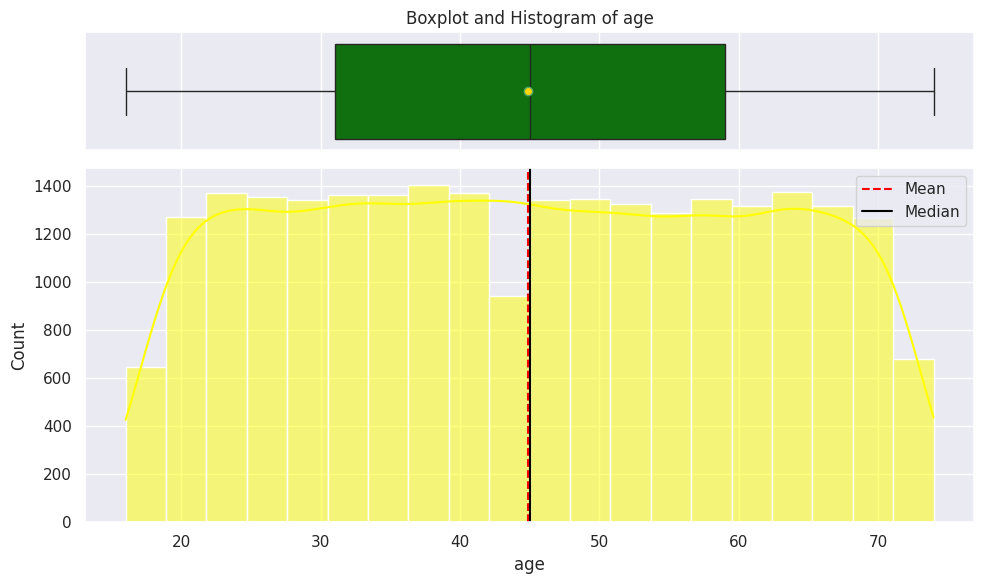

In [36]:
custplot_box_hist(df1, "age", show_kde=True, box_color="green", hist_color="yellow")

In [37]:
df1["age"].describe()

,age
count,25000.000000
mean,44.918320
std,16.107492
min,16.000000
25%,31.000000
50%,45.000000
75%,59.000000
max,74.000000


**Observations:**

- The average customer age is approximately 44.92 with a standard deviation of around 16.
- The minimum age is 16, and the maximum is 74.
- The median age is 45, which is very close to the mean.
- Most of the values are uniformly distributed, with the majority between 31 and 59 (the interquartile range).
- There appears to be a sudden and unnatural drop in the plot for the individuals between 42 and 45 years old. The boxplot does not show any statistical outliers.



**Insights:**

- There appears to be a sudden and unnatural drop in the plot for the individuals between 42 and 45 years old. This is unusual for a normal demographic set and may indicate a error in the data collection process.

- Excluding the extremes (those under 20 and over 70), the data appears to be relatively flat and uniform. This means the business has a balanced demographic for young adults, mid-life adults, and seniors.

- Age is a major factor for actuary and health calculations; therefore, it is expected to have a high positive correlation with healthcare utilisation and costs.

***adventure_sports***

adventure_sports
0    22957
1     2043
Name: count, dtype: int64




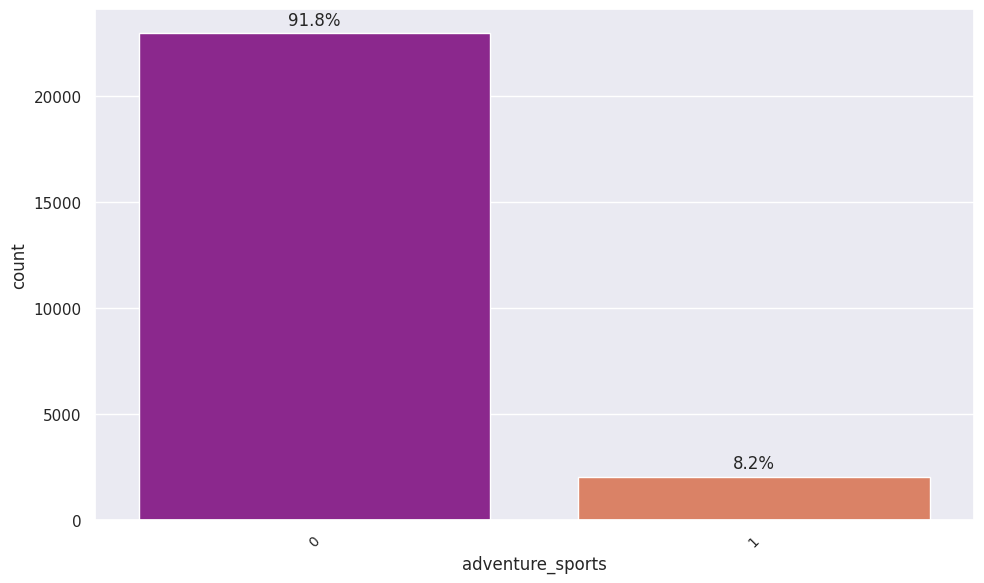

In [38]:
cust_label_barplot(df1, "adventure_sports", palette="plasma", show_percent=True)

**Observations:**

- The data type is binary, where 0 denotes the absence and 1 denotes the presence of adventure sports participation.

- The data range is from a minimum of 0 to a maximum of 1.

- The median is also 0.

- The data is highly skewed, with 91.8% of individuals not participating in adventure sports and the remaining 8.2% participating in the same.

- From the plot, we can clearly see that there is a huge class imbalance between the two data points.


**Insights:**

- The high skewness in the data indicates that the population that participates in adventure sports is a minority class.

- Adventure sports participants are more likely to have a high chance of physical injury or accidents; therefore, this data is likely to have a positive correlation with insurance costs or medical expenditure claims.


***visited_doctor_last_1_year***

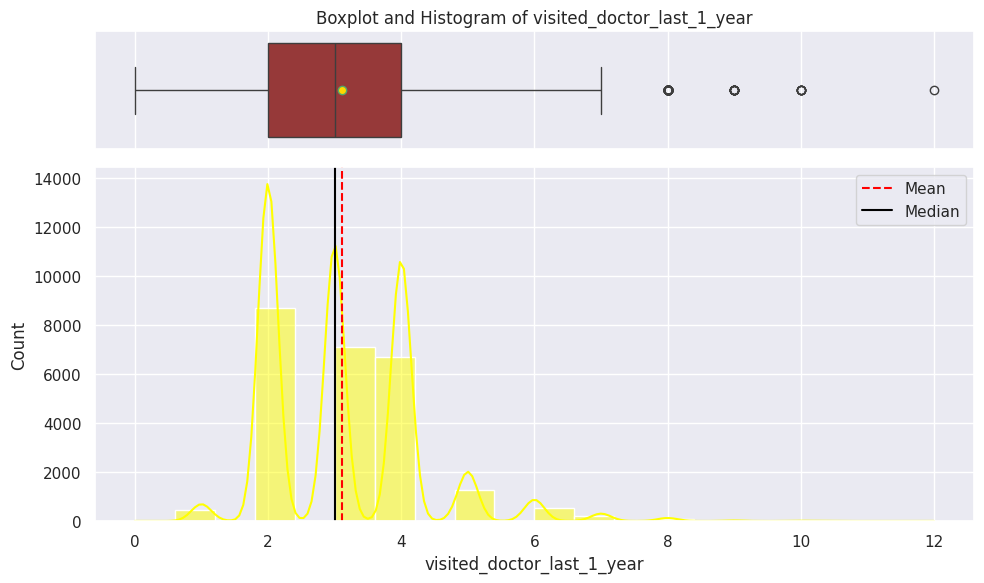

In [39]:
custplot_box_hist(df1, "visited_doctor_last_1_year", show_kde=True, box_color="brown", hist_color="yellow")

In [40]:
df1["visited_doctor_last_1_year"].describe()

,visited_doctor_last_1_year
count,25000.000000
mean,3.104200
std,1.141663
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,12.000000


**Observations:**

- The average number of doctor visits is approximately 3, with a standard deviation of about 1.14.
- The range of the data set goes from a minimum of 0 visits to a maximum of 12 visits.
- The median number of doctor visits is 3, which is almost identical to the mean.
- The data set is skewed towards the right, with a majority of individuals making between 2 and 4 visits to the doctor (interquartile range).
- The plot also suggests a heavy concentration of individuals making 2-4 visits, with the boxplot mathematically indicating outliers above 7 visits as statistical outliers.

**Insights**

- The high alignment of the mean and median suggests that, even though the data set itself is skewed, the mean and median are extremely stable.
- The frequency of visits to the doctor is generally a indicator of an individual's underlying health status, so a high rate of visits should be positively correlated with insurance costs or medical expenditures.
- The outliers, i.e., individuals making 10 or 12 visits, are mathematically indicated as outliers , as shown in the boxplot.

***heart_decs_history***

heart_decs_history
0    23634
1     1366
Name: count, dtype: int64




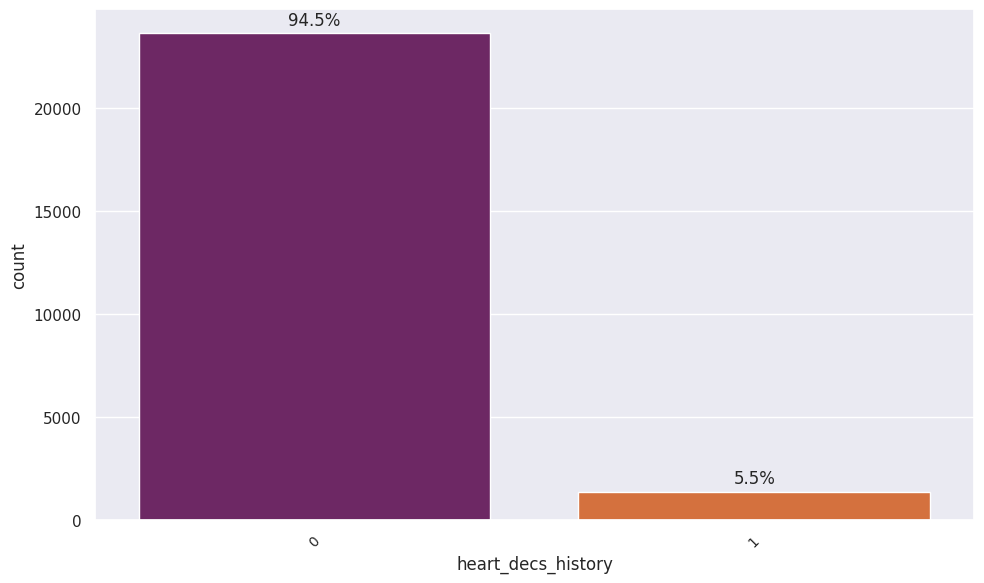

In [41]:
cust_label_barplot(df1, "heart_decs_history", palette="inferno", show_percent=True)

**Observations:**

- The data set is a binary set where 0 indicates no history of heart disease and 1 indicates a history of heart disease.

- The minimum value of the set is 0 and the maximum is 1.

- The median of the set is 0.

- The dataset is highly skewed with 94.5% of people having no history of heart disease and only 5.5% of people having a history of heart disease.

- The plot of the set indicates a stark class imbalance between both sets of people.


**Insights:**

- The high degree of skewness in the set indicates that having a history of heart disease is a rare occurrence in this set of people and hence forms a minority class.

- Having a history of heart disease increases the risk of medical claims and hence is related to insurance costs in a positive manner.

- The class imbalance is severe with the majority class being greater than the minority class.

***other_major_decs_history***

other_major_decs_history
0    22546
1     2454
Name: count, dtype: int64




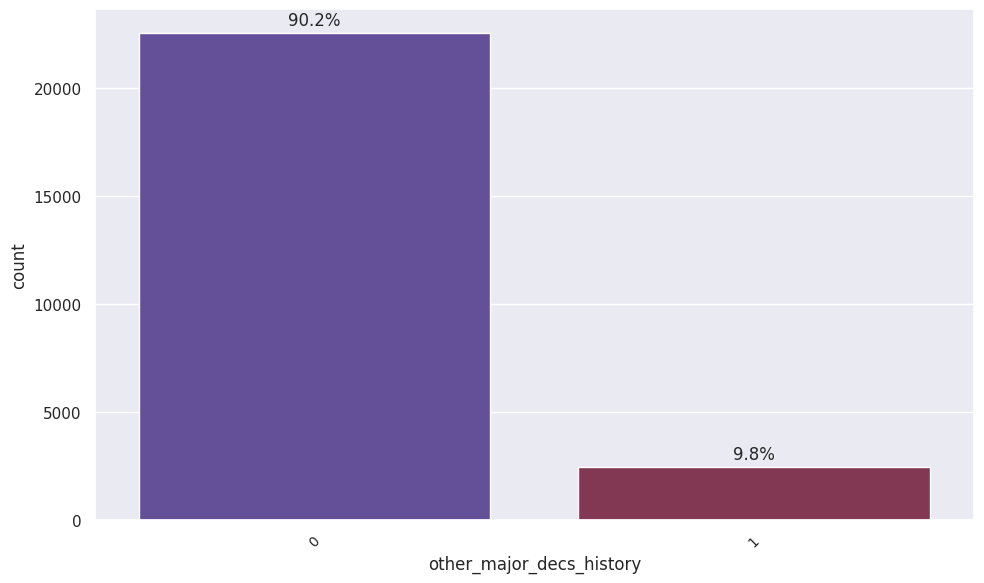

In [42]:
cust_label_barplot(df1, "other_major_decs_history", palette="twilight", show_percent=True)

**Observations:**

* The data points are binary in nature, where 0 represents the absence and 1 represents the presence of other major disease histories.
* The range of the data points is from 0 to 1.
* The median of the data points is 0.
* The data points are highly skewed, with 90.2% of the population showing no other major disease histories and 9.8% showing a positive history.
* The plot shows a high level of stark class imbalance between the two classes.


**Insights:**

* The high level of skewness in the data, with 90.2% of the population showing no other major disease histories, suggests that the presence of other major disease histories is a minority in this population.
* A history of other major disease histories or surgeries generally points towards high risk levels in underwriting; hence, this factor can be expected to have a positive correlation with premium or claim costs.
* The level of class imbalance in this dataset is extremely high, with the majority class(0) significantly higher than the minority class(1).

***Year_last_admitted***

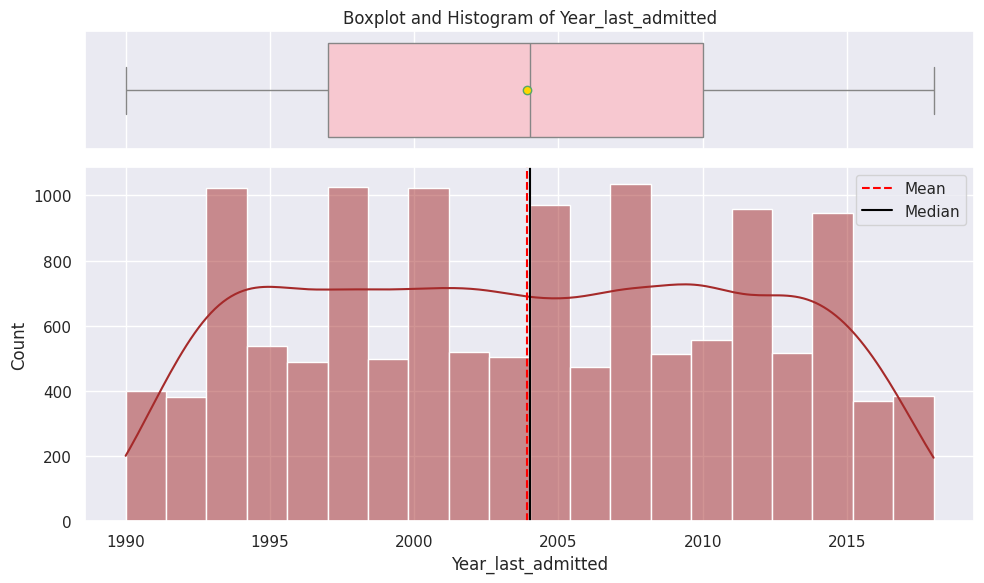

In [43]:
custplot_box_hist(df1, "Year_last_admitted", show_kde=True, box_color="pink", hist_color="brown")

In [44]:
  df1["Year_last_admitted"].describe()

,Year_last_admitted
count,13119.000000
mean,2003.892217
std,7.581521
min,1990.000000
25%,1997.000000
50%,2004.000000
75%,2010.000000
max,2018.000000


**Observations:**

- The average year of last admission is approximately 2003.89. The standard deviation of this figure is around 7.58.
- The range of the data varies from a minimum year of 1990 to a maximum year of 2018.
- The median year of last admission is 2004. This figure is almost identical to the mean.
- The range of the data is relatively uniformly distributed between the interquartile range of 1997 and 2010. The distribution of the data is multi-modal (spiky) as well.
- The boxplot of the data indicates that it is well-contained within the range of 1990 and 2018. There are no mathematical outliers.
- We already know that the number of missing values for the Year_last_admitted feature is 11,881. The total number of rows of the dataset is 25,000. Therefore, it accounts for approximately 47.52% of the data being missing.


**Insights:**

- The periodic peaks (in 1994, 1998, 2001, 2008, 2012, 2015, etc.) suggest periodic variations in hospitalizations, which could be related to certain patterns in recording or sampling.
- As the median year is 2004, a large proportion of the population hasn't been hospitalized in over a decade.

- The recency of hospitalization, or the fact that hospitalization occurred closer to the present (i.e., closer to 2018 than the 1990s), could be a significant factor in determining the premium for a patient, with higher premiums for those hospitalized closer to 2018 compared to the 1990s.

***weight_change_in_last_one_year***

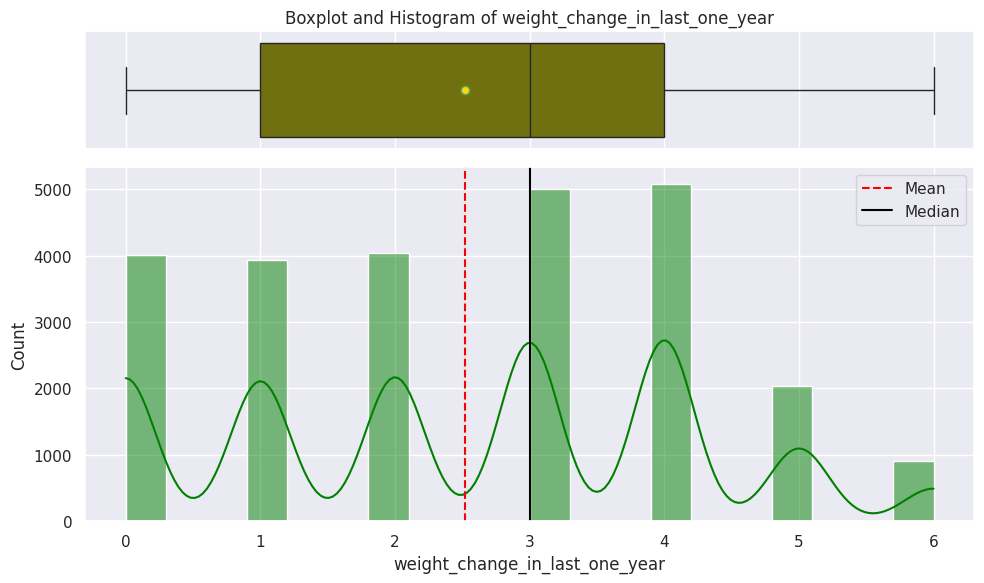

In [45]:
custplot_box_hist(df1, "weight_change_in_last_one_year", show_kde=True, box_color="olive", hist_color="green")

In [46]:
df1["weight_change_in_last_one_year"].describe()

,weight_change_in_last_one_year
count,25000.000000
mean,2.517960
std,1.690335
min,0.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,6.000000



**Observations:**

- The average weight change is about 2.52 units, and the standard deviation is about 1.69 units.
- The data varies between the smallest value of 0 units and the highest value of 6 units.
- The median weight change is about 3 units, which is slightly higher than the mean of 2.52 units.
- The data appears to be multi-modal, and the data has peaks at every whole number integer (0, 1, 2, 3, and 4), suggesting that the data is likely recorded as whole numbers.
- The boxplot indicates that the data is perfectly contained between 0 and 6, with no mathematical outliers.


**Insights:**
- A very high level of data points being multi-modal and peaking only at whole numbers suggests that the data has experienced some form of standard data rounding or binning during the data collection process.
- A history of weight fluctuation is generally a reflection of a change in lifestyle, diet, or metabolic conditions, and this factor is likely to have a positive correlation with premium or claim costs.
- The absence of any outliers suggests that the level of stability in this data is extremely high.

###**Univariate Analysis on categorical variables**

- We will now do univariate analysis on categorical columns to understand their distributions & proportins

***Occupation***

Occupation
Student     10169
Business    10020
Salried      4811
Name: count, dtype: int64




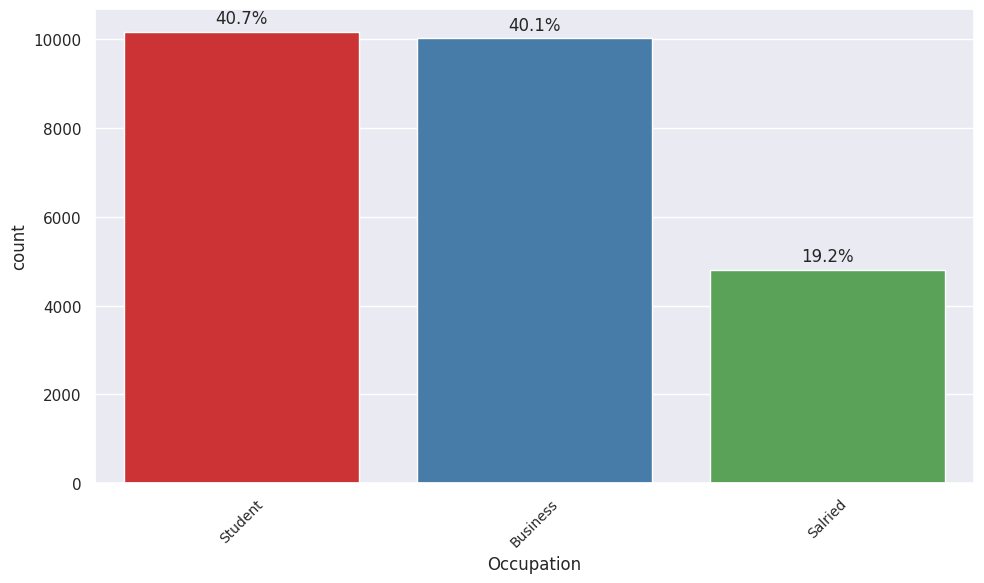

In [47]:
cust_label_barplot(df1, "Occupation", palette="Set1", show_percent=True)

**Observations:**

- The dataset is categorical in nature, representing 3 distinct career classifications of the customer.
- The range of data points covers all Student, Business, and Salried categories.
- The data points indicate that the majority of the population is either Students (40.7%) or Business owners (40.1%), whereas the population that is categorized as Salried is the minority (19.2%).
- The plot indicates that there is a visible class imbalance, where the Student and Business data are greater than twice that of the Salried individuals.

**Insights:**
- The high level of representation for the Student category (40.7%) indicates that a large percentage of this data set is comprised of younger demographics, which generally correlate with a lower baseline medical risks, but a higher potential for retaining policy over the long term.
- A history of an employment type, such as Business or Salried, generally correlates with different stress profiles, different levels of physical exertion, or different income stability, which will have a direct correlation with premium or claim costs.
- The level of class imbalance within this data is moderate, where the Salried class is significantly lower than the other two classes.


***cholesterol_level***

cholesterol_level
150 to 175    8763
125 to 150    8339
200 to 225    2963
175 to 200    2881
225 to 250    2054
Name: count, dtype: int64




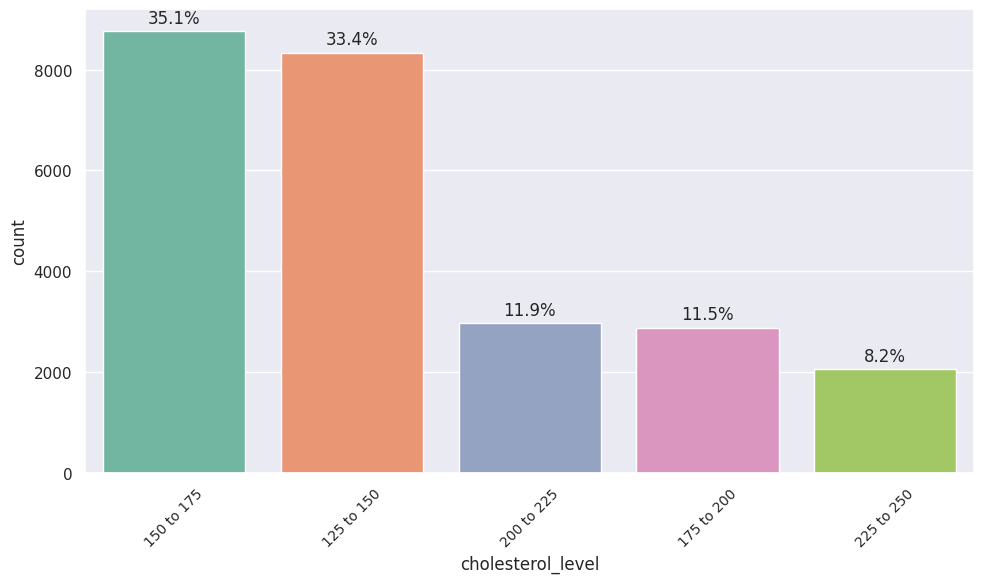

In [48]:
cust_label_barplot(df1, "cholesterol_level", palette="Set2", show_percent=True)

**Observations:**

- The data points are categorical in nature, representing five distinct cholesterol level (medical unit is in mg/dL) ranges of individuals.
- The range of the data points spans from 125 to 150 mg/dL up to 225 to 250 mg/dL.
- From the data points, we see that the distribution is highly concentrated in the lower ranges of 150 to 175 (35.1%) and 125 to 150 (33.4%), while the higher ranges, such as 225 to 250, are a minority (8.2%).
- From the bar plot, we see that there is a visible class imbalance, where the lower ranges of cholesterol are nearly four times as common as the highest range.

**Insights:**

- Given that there is a high level of representation in the lower ranges of cholesterol (68.5% combined for all ranges less than 175), this suggests that this customer population is generally a healthy population.
- Given that a history of higher levels of cholesterol (above 200 mg/dL) generally indicates a higher level of cardiovascular risk, this factor is likely to have a positive correlation with premium or claim costs.


***Gender***

Gender
Male      16422
Female     8578
Name: count, dtype: int64




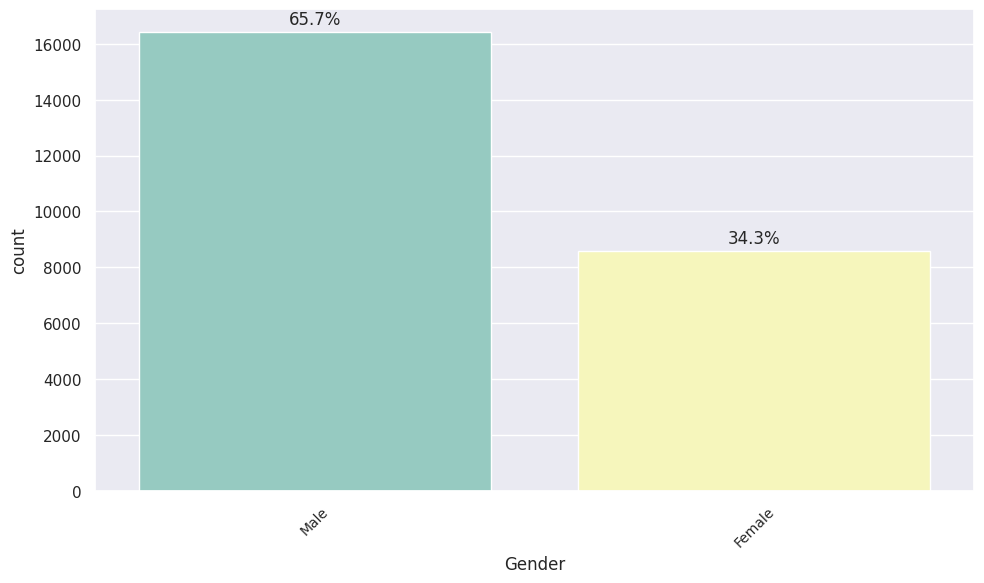

In [49]:
cust_label_barplot(df1, "Gender", palette="Set3", show_percent=True)

**Observations:**
- The data points are of binary types, where the data categories represent Male and Female types.
- The range of data points covers two different classes of genders.
- The data points clearly indicate that the distribution is highly concentrated for Males (65.7%), where Females constitute a minority class (34.3%).
- The plot indicates that there is a clear class imbalance, where Males are almost twice as common as Females.

**Insights:**
- The clear majority (65.7%) of Males in the data representation indicates that this data may be biased towards occupations or history where males have traditionally been the primary policy holders.
- A history of gender classifications generally implies a difference in actuarial risks and life expectancies, which is a direct factor that could be correlated with costs.
- The class imbalance is moderate, where the Female data point is significantly lower compared to the Male class.

***smoking_status***

smoking_status
never smoked       9249
Unknown            7555
formerly smoked    4329
smokes             3867
Name: count, dtype: int64




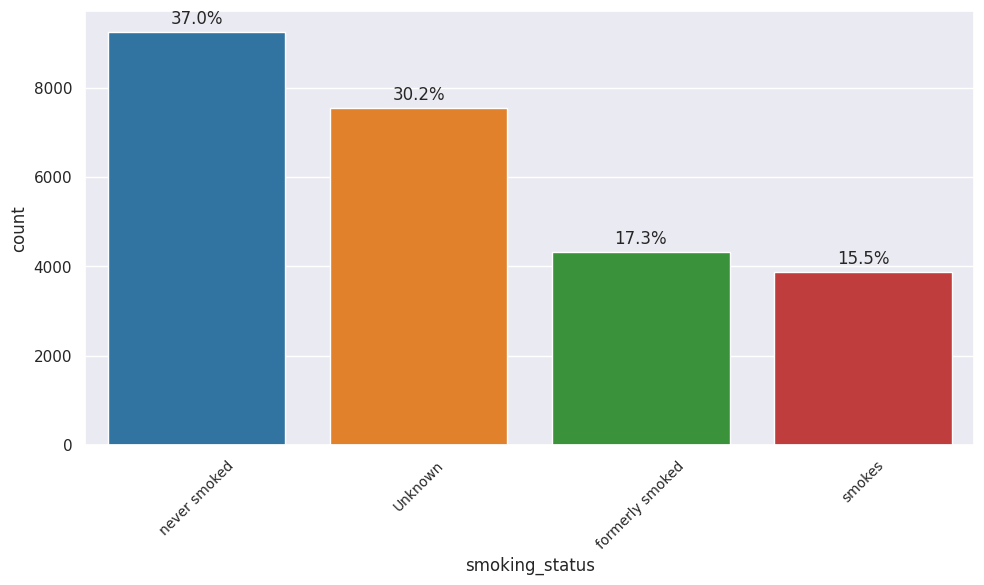

In [50]:
cust_label_barplot(df1, "smoking_status", palette="tab10", show_percent=True)

**Observations:**

- The data points are of a categorical nature, showing different smoking behavioral classes of the population under consideration.
- The range of data points varies from never smoked, Unknown, formerly smoked, and smokes.
- From the data points, it is clear that the highest proportion of people belongs to those who have never smoked (37.0%) and Unknown (30.2%), and those who are currently smoking are in the minority class (15.5%).
- From the bar plot, it is evident that there is class imbalance in the data, as those who have never smoked are more than double the number of people who are currently smoking.

**Insights:**
- The highest proportion of people belonging to the Unknown class (30.2%) indicates that there is incomplete information provided by the applicants, which is a major risk of information asymmetry for insurance companies.
- The class of people who are currently smoking (smokes) indicates a higher risk of respiratory and cardiovascular risks, so it is expected that this factor would have a very high positive correlation with risk levels.
- The class imbalance of this data is moderate, and the class having the least number of people is the smokes class.

***Location***

Location
Bangalore      1742
Jaipur         1706
Bhubaneswar    1704
Mangalore      1697
Delhi          1680
Ahmedabad      1677
Guwahati       1672
Chennai        1669
Kanpur         1664
Nagpur         1663
Mumbai         1658
Lucknow        1637
Pune           1622
Kolkata        1620
Surat          1589
Name: count, dtype: int64




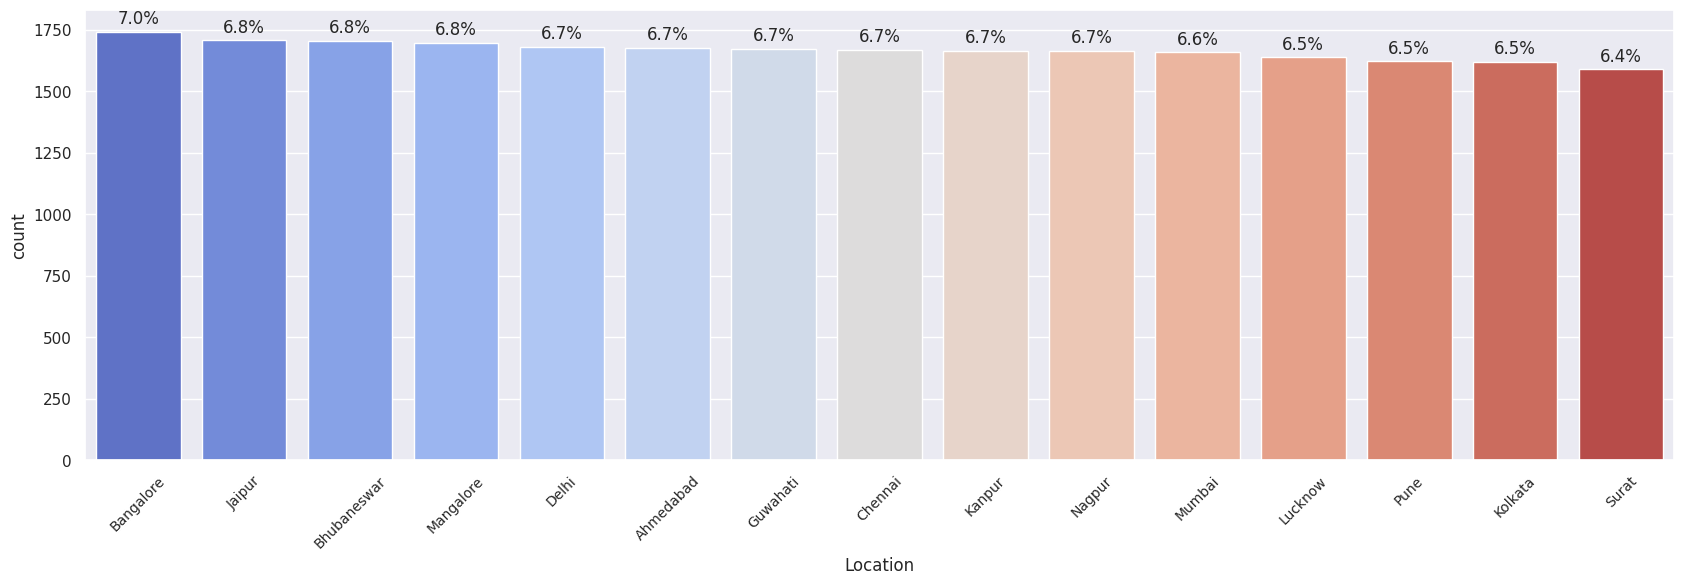

In [51]:
cust_label_barplot(df1, "Location", palette="coolwarm", show_percent=True)

**Observations:**
- The data points are categorical in nature, representing fifteen different city-based geographical classifications of the population under study.
- The range of data points extends across major Indian geographical hubs such as Bangalore and Surat.
- The data points also show that the distribution is almost perfectly uniform across all fifteen cities, with the highest concentration being in Bangalore (7.0%) and the lowest being in Surat (6.4%).
- The plot also shows that there is no class imbalance issue in the data set, with all 15 geographical locations being represented within a tight range of 6.4% to 7.0%.

**Insights:**
- The data points show that the distribution is almost perfectly uniform across fifteen major urban hubs, therefore, this data sampling approach is extremely well-balanced with no regional biases.
- A history of geographical locations usually implies a direct correlation with regional healthcare infrastructure costs, pollution indexes, and cost-of-living adjustments in underwriting.
- The class imbalance issue in the data set is almost zero.

***covered_by_any_other_company***

covered_by_any_other_company
N    17418
Y     7582
Name: count, dtype: int64




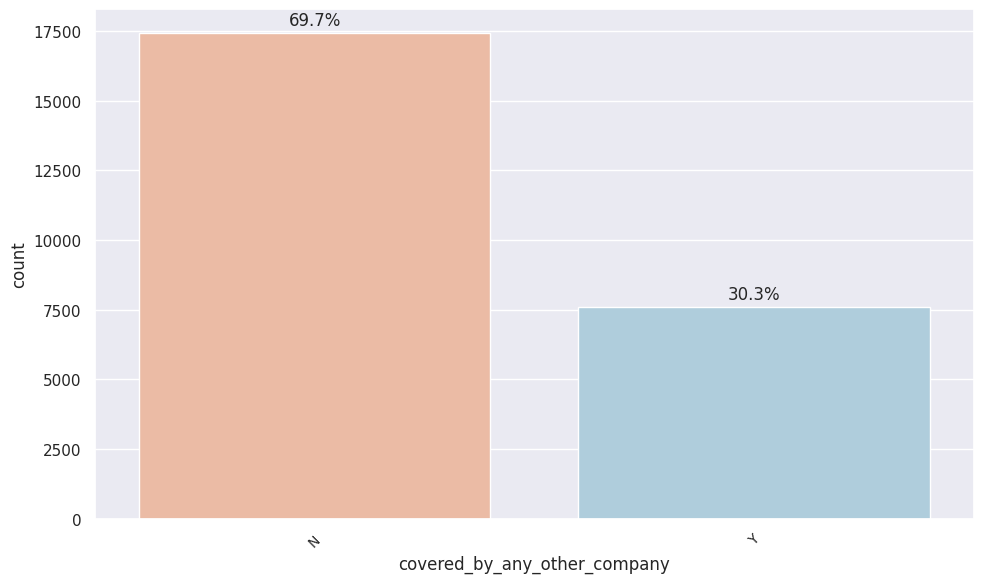

In [52]:
cust_label_barplot(df1, "covered_by_any_other_company", palette="RdBu", show_percent=True)

**Observations:**
- This attribute essentially represents binary information, i.e., whether or not the applicants have overlapping coverage with a secondary insurance provider.
- The range of this attribute is restricted to a binary classification, Y (Yes) or N (No).
- Approximately 70% (69.7%) of the population does not have external coverage, while approximately 30% (30.3%) of the population holds other companies' insurance policies.
- From the above visualization, we can also see that the distribution of the classes in this attribute is highly skewed, with the number of individuals without coverage being over twice as large as the number of individuals with coverage.

**Insights:**
- A high proportion of individuals in the population (approximately 69.7%) are found to be without other coverage, which could mean that the company might be the sole risk bearer for the vast majority of the portfolio.
- Having secondary coverage can be a financial safety net against large claim liabilities, so this attribute should theoretically be negatively correlated with the firm's claim liabilities.
- The distribution of this attribute in the population is somewhat imbalanced.

***Alcohol***

Alcohol
Rare     13752
No        8541
Daily     2707
Name: count, dtype: int64




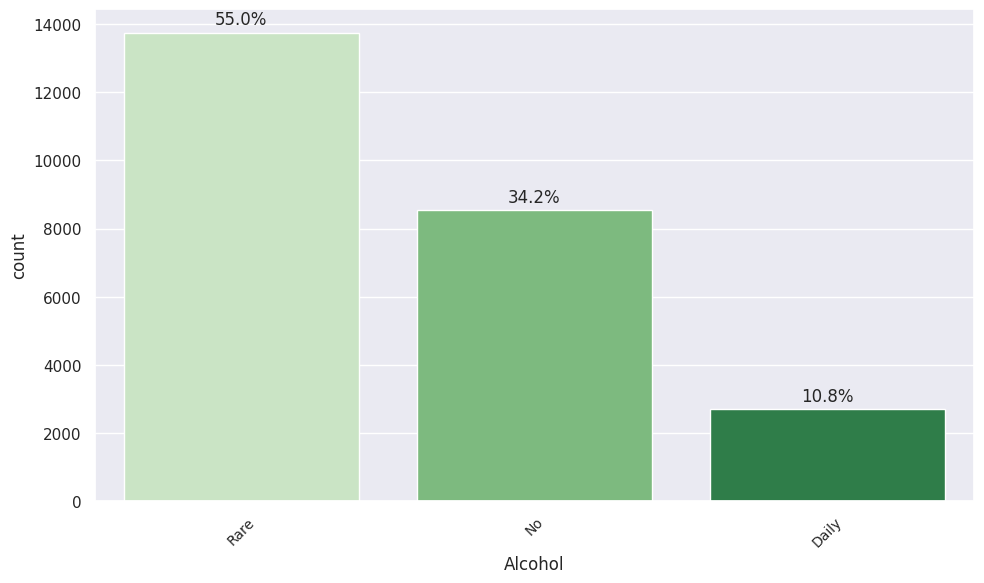

In [53]:
cust_label_barplot(df1, "Alcohol", palette="Greens", show_percent=True)

**Observations:**
- The feature is qualitative, as it categorizes the alcohol consumption patterns of the surveyed population into three ordinal categories.
- The categories include the Rare, No, and Daily consumption brackets.
- The majority of the population (55.0%) fall into the Rare category of alcohol consumption, followed by a smaller segment (34.2%) of people who do not drink at all, and a minor segment (10.8%) of people who drink alcohol every day.
- The visual representation of the feature clearly shows a large class imbalance, as the Rare category of alcohol consumption is more than five times larger than the segment of people consuming alcohol every day.

**Insights:**
- The large proportion of Rare and No alcohol consumption categories (89.2%) suggests that the majority of the portfolio has a low-to-moderate lifestyle profile.
- The health risks of frequently or daily consuming alcohol include a higher probability of metabolic, cardiovascular, and liver diseases. Therefore, this feature should theoretically show a positive correlation with the cost of underwriting and premiums.
- The structural distribution of this feature is moderately imbalanced.

***Exercise***

exercise
Moderate    14638
Extreme      5248
No           5114
Name: count, dtype: int64




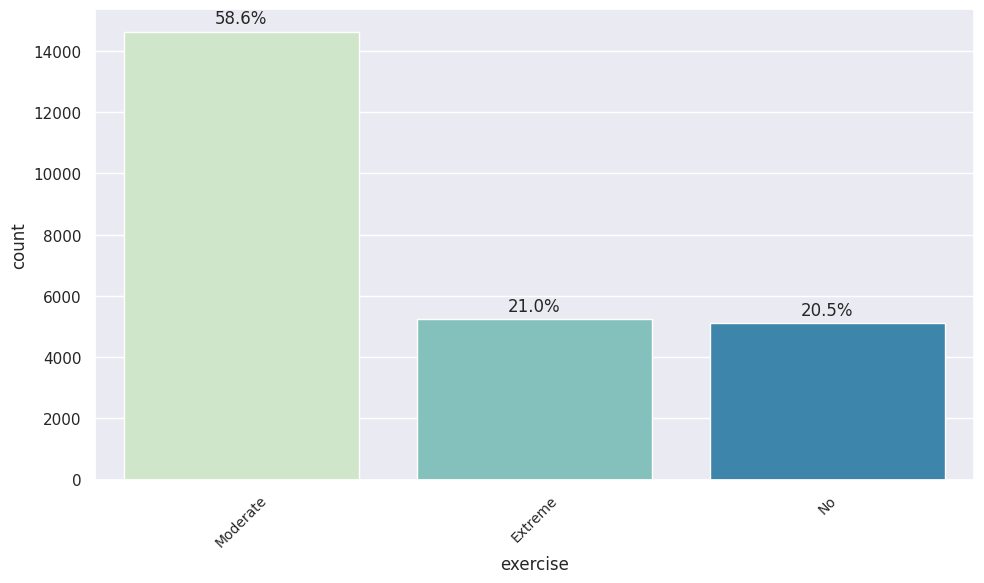

In [54]:
cust_label_barplot(df1, "exercise", palette="GnBu", show_percent=True)

**Observations:**
- This feature can be classified as categorical, as it defines the physical activity patterns of the sampled population, which fall within three different categories.
- These categories are spread out along the scale of Moderate, Extreme, and No Exercise.
- The results reveal that almost 60% (58.6%) of the population are Moderately physically active, 21% are undertaking Extreme physical training, and a meager 20.5% are in the category of people with No Exercise.
- The results also reveal that the distribution of the categories, particularly in the Moderate category, indicates a high level of skewness, as this category is almost three times larger than the Extreme and No Exercise categories.

**Insights:**
- The high proportion of Moderately physically active individuals in the population suggests that the majority of the portfolio comprises individuals with a healthy, active lifestyle.
- Individuals with Sedentary Lifestyle (No Exercise) are known to be at a high risk of heart disease, and individuals with Extreme physical training are at a risk of sports injury; thus, these two categories are expected to have different correlations with respect to policy costs and premium payouts.
- The distribution of this category can be classified as moderately imbalanced.

###**Binary Encoding of Categorical variables**

**Before proceeding to bivariate analysis, let us first create a copy of current data frame and then encode variables.**

In [55]:
# Create a copy of our main dataframe to avoid any accidental change in the dataset.
df2 = df1.copy()

**We will now do binary encoding (Mapping to 0 and 1) columns having for simple Yes/No or Male/Female, covered_by_any_other_company columns.**
**For columns where the categories have a natural ranking from low to high, we will use ordinal mapping:**

  - Alcohol (No = 0, Rare = 1, Daily = 2)

  - exercise (No = 0, Moderate = 1, Extreme = 2)

  - cholesterol_level (125 to 150 = 0, 150 to 175 = 1, etc.)

In [56]:
# Binary Mapping (0 and 1 for simple Yes/No or Male/Female)
df2['Gender'] = df2['Gender'].map({'Male': 0, 'Female': 1})
df2['covered_by_any_other_company'] = df2['covered_by_any_other_company'].map({'N': 0, 'Y': 1})


# Ordinal Mapping (Low to High natural rankings):

# 1. Alcohol Mapping
df2['Alcohol'] = df2['Alcohol'].map({'No': 0, 'Rare': 1, 'Daily': 2})

# 2. Exercise Mapping
df2['exercise'] = df2['exercise'].map({'No': 0, 'Moderate': 1, 'Extreme': 2})

# 3. Cholesterol Mapping
cholesterol_order = {
    '125 to 150': 0,
    '150 to 175': 1,
    '175 to 200': 2,
    '200 to 225': 3,
    '225 to 250': 4
}
df2['cholesterol_level'] = df2['cholesterol_level'].map(cholesterol_order)


# Preview the results to verify
df2[['Gender', 'covered_by_any_other_company', 'Alcohol', 'exercise', 'cholesterol_level']].head()

,Gender,covered_by_any_other_company,Alcohol,exercise,cholesterol_level
0,0,0,1,1,0
1,0,0,1,1,1
2,1,0,2,2,3
3,1,1,1,0,2
4,0,0,0,2,1


**Observations:**
- We can observe that we have successfully implemented binary and ordinal mapping on relevant columns to facilitate further analysis.

##**Bivariate Analysis**

**Feature Selection Strategy for Bivariate Analysis**

The bivariate analysis is intended to reveal how individual features affect the target variable (insurance_cost) and find significant associations among health-related features.

**Feature combinations are selected according to:**
- Statistical signals obtained during correlation analysis
- Knowledge of healthcare risk factors and insurance cost
- The need to remain simple by focusing only on high-impact features without redundancy


---
**1. Target vs Numerical Features**

This category of features is intended to reveal how numerical features directly influence insurance cost.

The selected features include:
- **Body composition**: weight, bmi, fat_percentage, age  
- **Clinical features**: avg_glucose_level
- **Lifestyle activity**: daily_avg_steps  


These features are often used in insurance cost analysis to determine an individual's health risk factors.  
Regression plots are used to reveal trends and the nature of associations.

---

**2. Target vs Categorical Features**

This category of features is intended to reveal how lifestyle factors and medical history influence insurance cost in different groups.

The selected features include:
- **Lifestyle habits**: smoking_status, exercise  
- **Medical history**: heart_decs_history  

These features represent different risk factors that often significantly influence insurance cost.  
Boxplots are used to compare cost distributions among different groups.

---

**3. Clinical Inter-relationships (Feature vs Feature)**

This section of the analysis delves into the inter-relationship of health indicators in a bid to establish potential underlying medical patterns.


***The inter-relationship patterns considered in this case include:***

- fat_percentage vs avg_glucose_level  

- fat_percentage vs daily_avg_steps  

- bmi vs gender

This will help in understanding the relationship that exists between lifestyle and physiological patterns, which can have a secondary effect on insurance costs.

---

**4. Behavioral Pattern Analysis (Categorical vs Categorical)**

This section of the analysis is dedicated to understanding the proportionate relationship that exists between two categorical patterns.


***The patterns considered in this case include:***

- Occupation vs exercise  

- Gender vs smoking_status  

---
**Custom EDA visualization functions have been used in this case to ensure that structured and understandable patterns are demonstrated.**

###**Target vs Numerical Features**

- **In this step, we will do analysis on two variable i.e. insurance_cost (target variable) vs other features in order to understand the effects of features on target variable.**
- **We will use Regplot instead of Scatter plot for plotting as it instantly overlay a fitted regression line and confidence interval on the data, making trends and linear relationships clearer than points alone for making the analysis easier.**

***Weight vs Insurance Cost***

- It assesses the direct effect of body weight on insurance premiums. Weight is one factor that influences insurance cost.


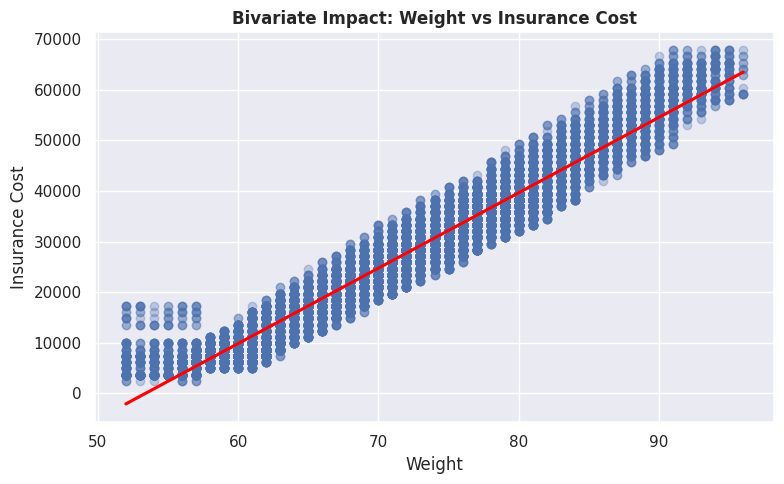

In [57]:
plt.figure(figsize=(8, 5))
sns.regplot(x='weight', y='insurance_cost', data=df2,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Bivariate Impact: Weight vs Insurance Cost', fontsize=12, fontweight='bold')
plt.xlabel('Weight')
plt.ylabel('Insurance Cost')
plt.tight_layout()
plt.show()

**Observations:**

- The presence of a strong positive linear correlation is evident between weight and insurance cost, where cost increases linearly with increasing weight from 52 to 96.

- The majority of the data points lie within the range of 60 to 85, where insurance cost increases linearly with increasing weight, reflecting a stable cost structure.

- However, at lower weight levels, individuals show lower costs, ranging from 1000 to 5000, reflecting a departure from the general trend for individuals weighing between 50 and 60.

**Insights:**

- Weight displays a strong positive relationship with insurance cost, suggesting it may be a dominant factor in pricing within this dataset.

- The presence of lower insurance costs for individuals at similar weight levels suggests that individuals without a medical history or healthy lifestyle habits can reduce risk, thus supporting the objective that individual health behaviors influence insurance cost.



---

***BMI vs Insurance Cost***

- It examines whether the composition of the human body, i.e., the relative weight to height ratio, influences insurance premiums.


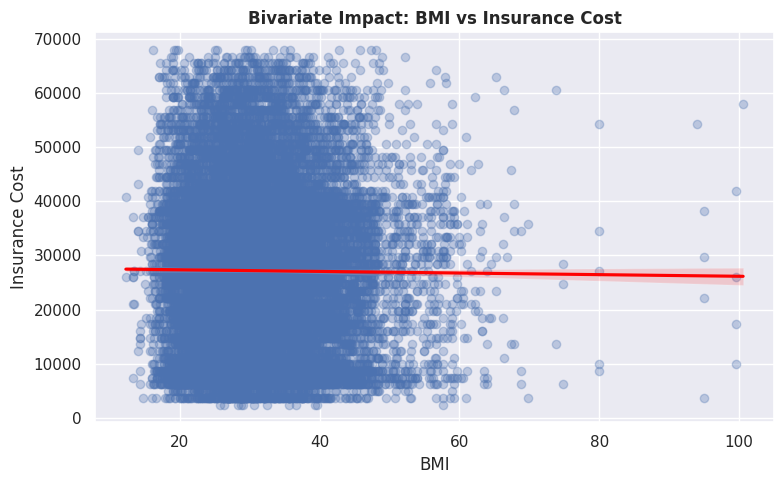

In [58]:
plt.figure(figsize=(8, 5))
sns.regplot(x='bmi', y='insurance_cost', data=df2,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Bivariate Impact: BMI vs Insurance Cost', fontsize=12, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Insurance Cost')
plt.tight_layout()
plt.show()

**Observations:**

- The values of the BMI are spread out across the range of 12 to 100, with most values between 20 and 45.

- The insurance costs are spread out across all the values of the BMI (2000 to 65000), with no particular trend upwards or downwards. The line also remains flat, showing no particular level of correlation between the insurance cost and the BMI.

**Insights:**

- Despite BMI being a standard health indicator, it does not seems too influence the insurance cost in this dataset.  

- This indicates that the insurer do not rely on the BMI alone to asses health risks, but may rely on more direct or observable factors, such as the weight or history, which may limit the effectiveness of the BMI as a predictor.

----

***Fat Percentage vs Insurance Cost***

- It analyzes whether a high percentage of fat composition in the human body, which is a more accurate measure of health, influences insurance premiums.

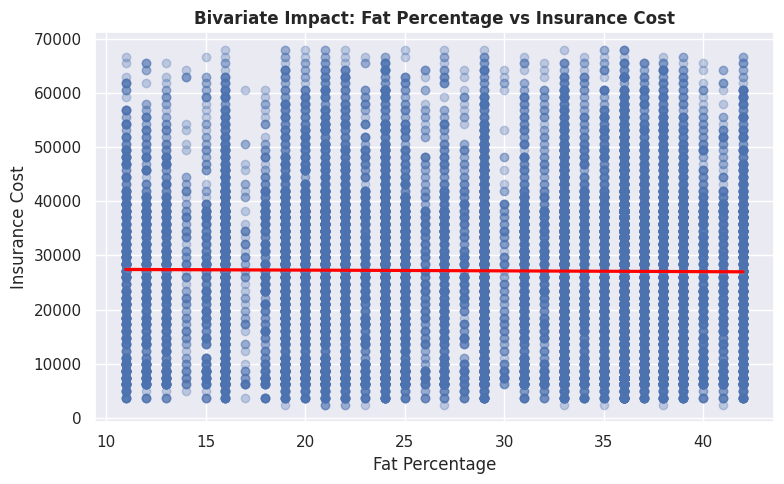

In [59]:
plt.figure(figsize=(8, 5))
sns.regplot(x='fat_percentage', y='insurance_cost', data=df2,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Bivariate Impact: Fat Percentage vs Insurance Cost', fontsize=12, fontweight='bold')
plt.xlabel('Fat Percentage')
plt.ylabel('Insurance Cost')
plt.tight_layout()
plt.show()

**Observations:**

- The percentage of fat varies between 11 and 42. The distribution of the data points is almost uniform.

- The insurance costs vary widely, ranging from 3000 to 67000. All the data points are included, but no specific pattern can be identified.

- The line of regression is almost horizontal, meaning no specific relationship can be established.

**Insights:**

- Fat percentage, although a more specific measure of health, does not show any direct correlation with insurance costs.

- This suggests that insurance companies are not using specific data points like fat percentage to determine insurance costs. This may not be a very specific measure of the actual condition and may not be used to optimize the insurance costs based on the condition.

---

***Avg Glucose Level vs Insurance Cost***

- It investigates the effect of average glucose levels on insurance premiums, which may be a measure of diabetes.

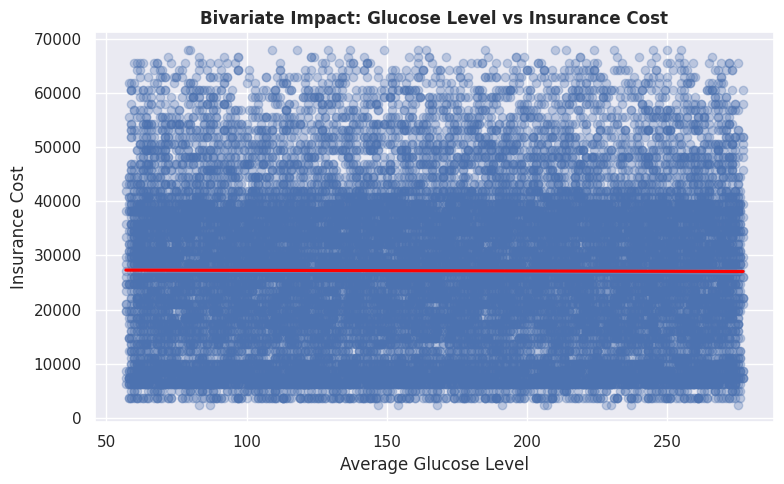

In [60]:
plt.figure(figsize=(8, 5))
sns.regplot(x='avg_glucose_level', y='insurance_cost', data=df2,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Bivariate Impact: Glucose Level vs Insurance Cost', fontsize=12, fontweight='bold')
plt.xlabel('Average Glucose Level')
plt.ylabel('Insurance Cost')
plt.tight_layout()
plt.show()

**Observations:**

- The average glucose level varies between 57 and 277, with densely populated data points for the entire range.

- Insurance costs are highly variable (2000 to 67000) for all glucose level data points, with no concentration or pattern.

- The regression line remains flat, indicating no linear relationship between the glucose level and insurance cost.

**Insights:**

- The average glucose level by itself has little effect on insurance rates, indicating that metabolic health indicators may not be directly taken into account by insurers for insurance pricing.
- This reveals a disconnect between clinical health risk factors and pricing strategy, suggesting that in order to better align with the objective of optimising insurance cost based on health conditions, these variables may need to be combined with other features.


---

***Avg Daily Steps vs Insurance Cost***

- It examines whether increased physical activity levels have a direct correlation with reduced insurance premiums.

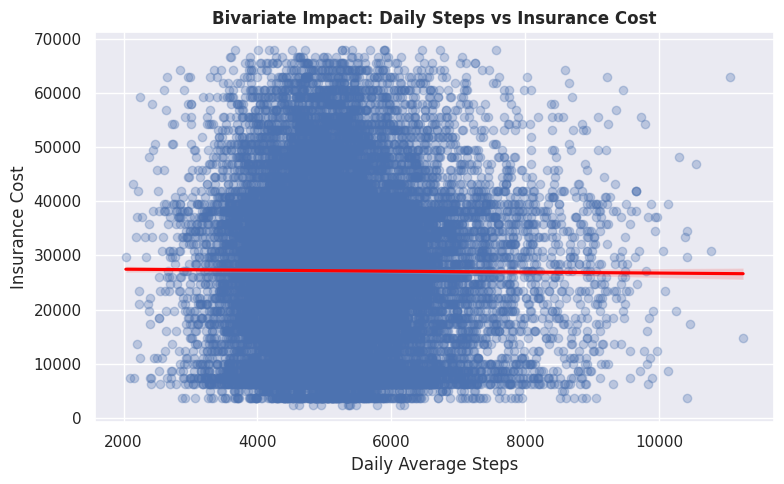

In [61]:
plt.figure(figsize=(8, 5))
sns.regplot(x='daily_avg_steps', y='insurance_cost', data=df2,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Bivariate Impact: Daily Steps vs Insurance Cost', fontsize=12, fontweight='bold')
plt.xlabel('Daily Average Steps')
plt.ylabel('Insurance Cost')
plt.tight_layout()
plt.show()

**Observations:**

- Daily average steps are also evenly distributed, ranging between 2000 and over 11000, with the majority of the data points concentrated between 4000 and 8000.
- Insurance costs are evenly spread over the entire range of data, between 2000 and 68000, for all step levels, with no specific clustering of data points in any particular step level.
- The red regression line is flat and horizontal, indicating that there is no specific linear relationship between the data points.

**Insights:**
- In this raw dataset, walking more steps or daily physical activities does not automatically result in lower insurance costs.
- Insurance companies probably combine exercise habits with other health metrics (such as weight or smoking) rather than looking at daily physical activities alone, as evidenced by the fact that standalone step counts do not determine pricing.


---

***Age vs Insurance Cost***

- It determine whether older age groups s have a direct correlation with increased insurance premiums.

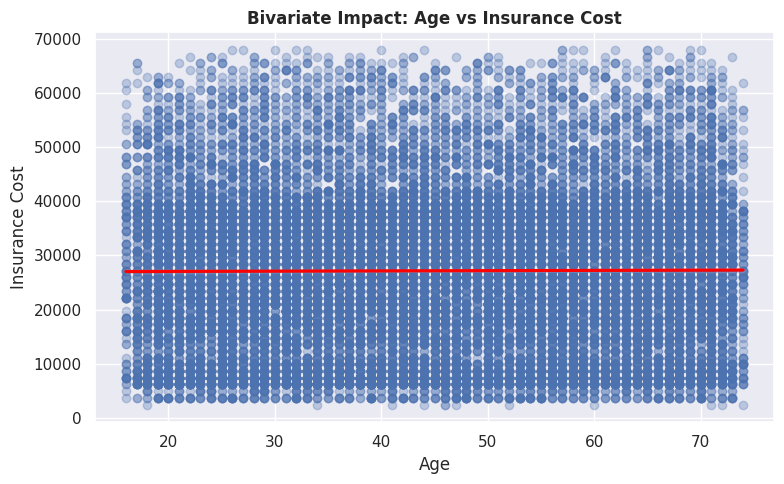

In [62]:
plt.figure(figsize=(8, 5))
sns.regplot(x='age', y='insurance_cost', data=df2,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Bivariate Impact: Age vs Insurance Cost', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Insurance Cost')
plt.tight_layout()
plt.show()

**Observations::**

- The red linear regression line, which is centred at an insurance cost of 27,000, stays perfectly flat over the whole X-axis.
- The data points span the whole age range, from seniors (age 74) to teenagers (age $16$).
- Insurance costs range from less than 5,000 to almost 70,000 for every age group. There isn't an upward diagonal slope.


**Insights:**

- In this dataset, age by itself has no linear predictive power over insurance costs. The maximum premium of 70,000 may be applied to both a 20-year-old and a 70-year-old.

- It demonstrates that other metrics (such as smoking or BMI) totally supersede age as a cost driver because costs are evenly distributed across all age groups.



###**Target vs Categorical Features**

We will use Boxpolts for analysis as  it efficiently compare the distribution, central tendency (median), spread, and outliers of numerical data across different categories side-by-side.

---

***Smoking Status vs Insurance Cost***

- It compares insurance cost based on different smoking statuses to assess the cost implications of this risky lifestyle habit.  

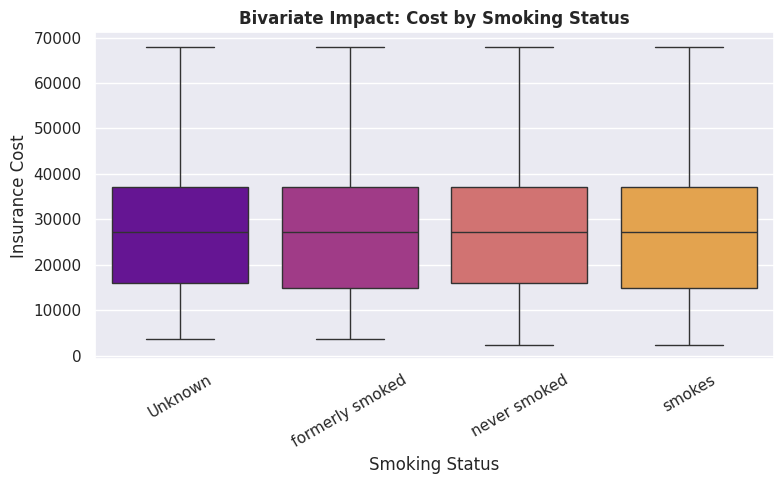

In [63]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoking_status', y='insurance_cost', data=df2, palette= "plasma")
plt.title('Bivariate Impact: Cost by Smoking Status', fontsize=12, fontweight='bold')
plt.xlabel('Smoking Status')
plt.ylabel('Insurance Cost')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observations:**

- Insurance costs for all smoking categories (smokers, never smokers, former smokers, and unknown smokers) range roughly from 3000 to 68000.

- There is no discernible upward or downward shift across groups, with the median cost for all categories falling between 26000 and 28000.

- The middle 50% of the data, or the interquartile range, is roughly between 15000 and 36000 for all categories.

- Regardless of smoking status, the spread and whiskers are almost the same, suggesting similar cost variability.


**Insights:**

- In contrast to a belief that smokers would pay higher premiums, smoking status does not exhibit a significant independent impact on insurance costs in this dataset.

- This implies that smoking behaviour might not be enough to differentiate pricing on its own and might need to interact with other health factors to show its impact.


---

***Exercise vs Insurance Cost***

- This plot evaluates how different levels of exercises influence insurance cost and individual health risks.  


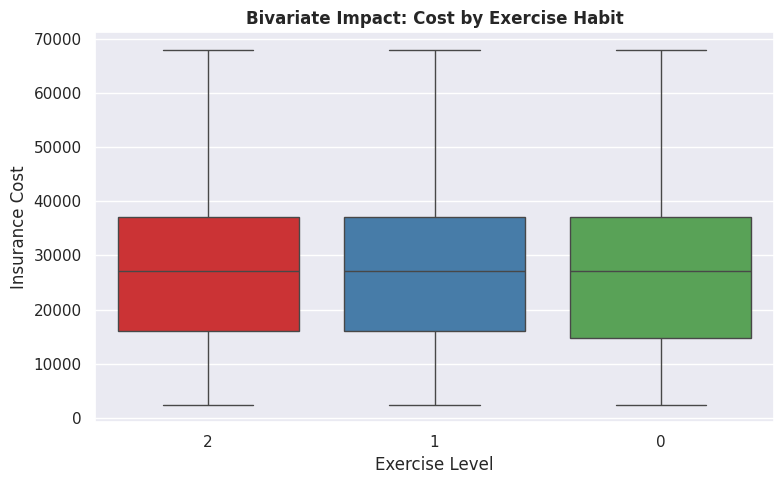

In [64]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='exercise', y='insurance_cost', data=df2, palette= "Set1")
plt.title('Bivariate Impact: Cost by Exercise Habit', fontsize=12, fontweight='bold')
plt.xlabel('Exercise Level')
plt.ylabel('Insurance Cost')
plt.tight_layout()
plt.show()

**Observations:**

- The cost of insurance varies greatly between roughly 3000 and 68000 for all exercise levels (0, 1, 2).

- The median cost, which is between 26,000 and 28,000, is the same for all groups.

- For all exercise levels, the interquartile range is roughly between 15000 and 36000.

- When exercise level rises or falls, there is no discernible change in distribution.

**Insights:**

- Despite expectations that increased activity levels would lower health risk, there is no clear correlation between exercise habits and insurance costs.
- This suggests that exercise might not be a significant pricing factor on its own and that its impact might only become apparent when paired with other lifestyle or medical factors.


---

***Heart Disease History vs Insurance Cost***

- This plot analyzes whether individuals suffering from heart disease are charged more for insurance due to increased medical risks.

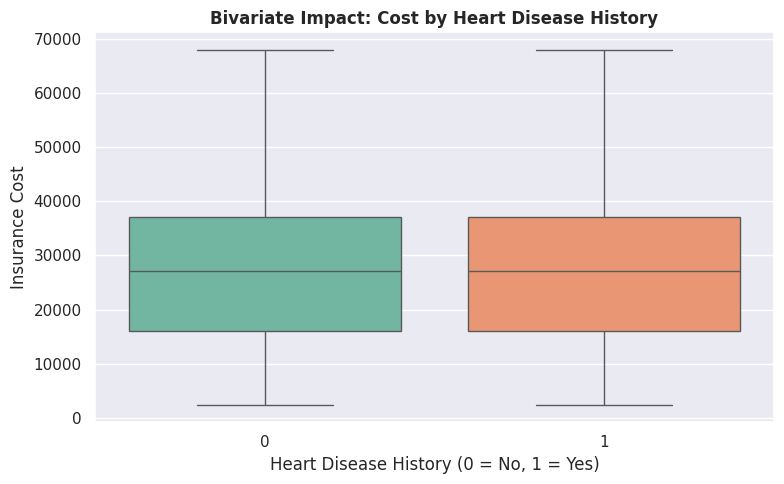

In [65]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='heart_decs_history', y='insurance_cost', data=df2, palette= "Set2")
plt.title('Bivariate Impact: Cost by Heart Disease History', fontsize=12, fontweight='bold')
plt.xlabel('Heart Disease History (0 = No, 1 = Yes)')
plt.ylabel('Insurance Cost')
plt.tight_layout()
plt.show()

**Observations:**

- Both groups insurance premiums (0: No history, 1: History) fall between roughly 3000 and 68,000.

- Both groups median insurance costs are almost the same, ranging from 26,000 to 28,000.

- For both categories, the interquartile range is likewise comparable, falling roughly between 15000 and 36000.

- For those with a history of heart disease, there is no discernible increase in expenses.

**Insights:**

- Given its clinical significance, heart disease history does not appear to have a significant impact on insurance costs on its own.

- This implies that the impact of medical history may depend on how it interacts with other risk factors rather than being directly reflected in pricing.

---


***Location vs Insurance Cost***

- this is to analyse if location have any significant effect on insurance pricing based on different regions.

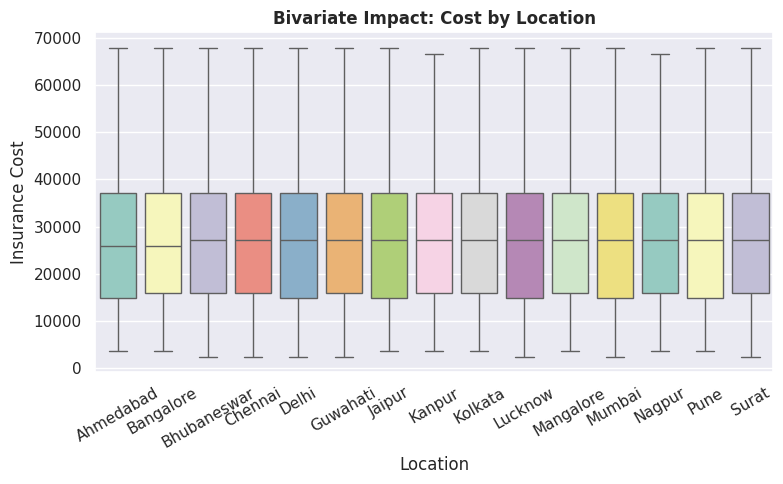

In [66]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Location', y='insurance_cost', data=df2, palette= "Set3")
plt.title('Bivariate Impact: Cost by Location', fontsize=12, fontweight='bold')
plt.xlabel('Location')
plt.ylabel('Insurance Cost')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observations:**

- All 15 cities have roughly comparable median insurance costs, ranging from 25,000 to 27,000.
- The IQR boxes are essentially the same size throughout all cities—roughly 15,000 to 36,000.
- The whiskers extend to similar ranges for every city—from near zero to around 68,000.
- No particular city jumps out with a significantly higher or lower cost distribution.
- Even visually unique cities like Chennai and Lucknow exhibit no significant distinction from the others.


**Insights:**

- In this dataset, there is no notable relationship between location and insurance costs.
- This column provides no predictive value to the model because there is no regional pricing signal.
- We can safely drop this column in data preprocessing sections.




###**Feature vs Feature (Clinical Inter-Relationships)**

- **We used a scatter plot here to visualize the feature vs feature distribution and variability of clinical outcomes across different categories, in order to analyse clusters and outliers that summary statistics might have hidden.**


---

***Fat Percentage vs Avg Daily Steps***

- This plot asses how different levels of physical activity influence fat percentages, reflecting lifestyle implications for individual's health.

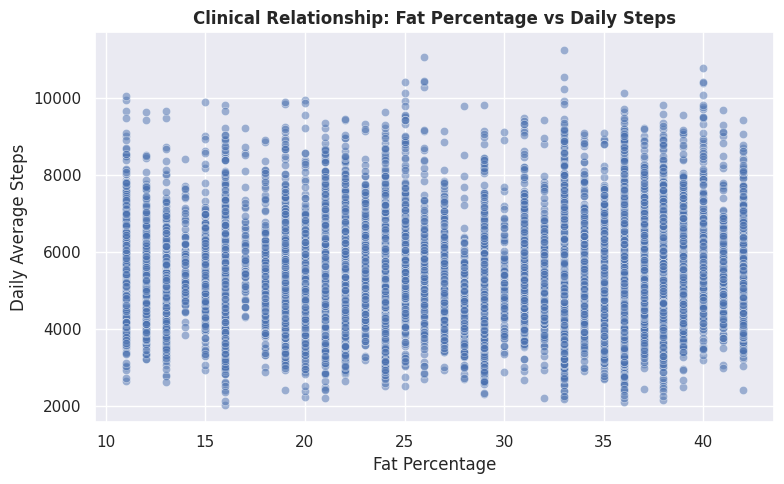

In [67]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='fat_percentage', y='daily_avg_steps', data=df2, alpha=0.5)
plt.title('Clinical Relationship: Fat Percentage vs Daily Steps', fontsize=12, fontweight='bold')
plt.xlabel('Fat Percentage')
plt.ylabel('Daily Average Steps')
plt.tight_layout()
plt.show()

**Observations:**

- Fat percentage ranges from around 11 to 42, while average daily steps vary between 2000 and 11000.

- Plot indicates data points are widely scattered with no visible upward or downward trend.

- For every fat percentage level, average daily steps show high variability, indicating no consistent pattern.

- No clustering or linear relationship is observed between the two variables.

**Insights:**

- This implies that there is no clear relationship with daily physical activity levels and fat percentage, which contrasts with the expectation that higher fat percentage might be associated with lower physical activity.

- This suggests that physical activity and body composition may not be directly correlated in this dataset and should be analyzed alongside additional features for better insights.


---

***Fat Percentage vs Avg Glucose Level***

- It analyzes the implications of body fat percentages on glucose levels to assess potential individual related health risks.  


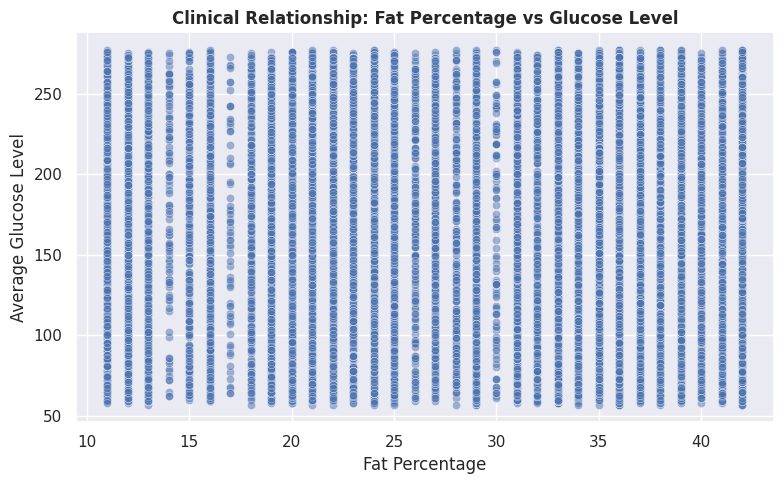

In [68]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='fat_percentage', y='avg_glucose_level', data=df2, alpha=0.5)
plt.title('Clinical Relationship: Fat Percentage vs Glucose Level', fontsize=12, fontweight='bold')
plt.xlabel('Fat Percentage')
plt.ylabel('Average Glucose Level')
plt.tight_layout()
plt.show()

**Observations:**

- Fat percentage ranges approximately from 11 to 42, while average glucose levels span from around 60 to 270.
- The scatter plot shows data points widely dispersed across all fat percentage values with no clear linear trend.
- For each fat percentage level, glucose values exhibit high variability, covering almost the entire range.
- No distinct clustering pattern is visible, indicating heterogeneity in the data.

**Insights:**

- This means that there isn't a strong or direct link between average glucose levels and fat percentage.
- The high variability indicates that glucose levels are affected by various factors in addition to fat percentage.
- Fat percentage alone is not a dependable indicator of glucose level and must be utilized alongside additional clinical and lifestyle factors.
- This shows that we need to use multivariate analysis to better understand the relationships in the dataset.



---

***BMI vs Gender***

- To analyzes the implications of gender on bmi to assess how individual's bmi vary based on gender.  


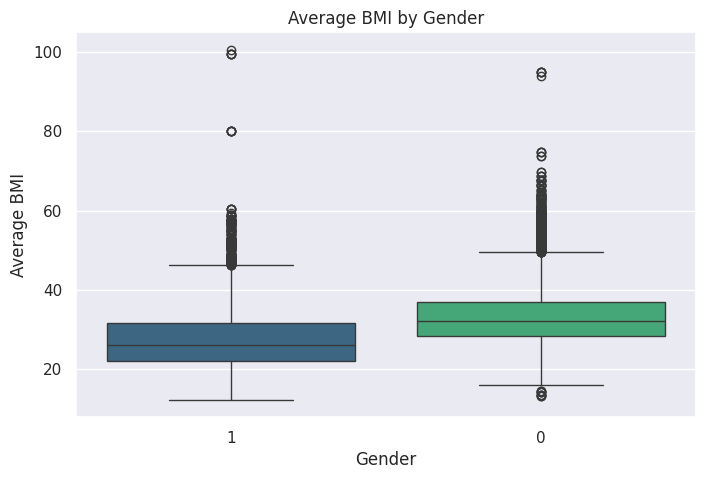

In [69]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df2,y='bmi',x='Gender', palette= "viridis")
plt.xlabel('Gender')
plt.ylabel('Average BMI')
plt.title('Average BMI by Gender');

**Observations:**

- Medians (Female 1 vs. Male 0): The female median BMI is approximately 26. At 32, the median BMI for men is marginally higher.

- The middle 50% of the data for females falls between a BMI of 22 and 32. The IQR is marginally wider for men, falling between a BMI of 28 and 37.

- Extreme outliers beyond the whiskers are seen in both sexes. The highest outliers have BMIs of 95 for men and 100 for women.

**Insights:**

- In this dataset, men's baseline BMI is generally higher than women's.

- Gender by itself is not a reliable indicator of BMI because the boxes overlap considerably (between a BMI of 28 and 32).
- Since BMI has 990 missing values and extreme skewness of up to 100, a simple mean imputation would not help, as these outliers will create an artificial pull on the mean. Therefore, to fill the 990 missing values, we should use the Median (which is resilient to outliers), grouped by Gender.

###**Categorical vs Categorical Features**

Here, I will use a stacked bar plot to show how different categories break down into sub-category, making it easy to see both the total counts and the relative mix of outcomes within each group.


---


***Occupation vs Exercise***

- It evaluates whether occupation influences levels of exercises, reflecting individual lifestyle constraints and implications.  

exercise       2      1     0    All
Occupation                          
Business    2260   5779  1981  10020
Salried      942   2971   898   4811
Student     2046   5888  2235  10169
All         5248  14638  5114  25000
----------------------------------------------------------------------------------------------------


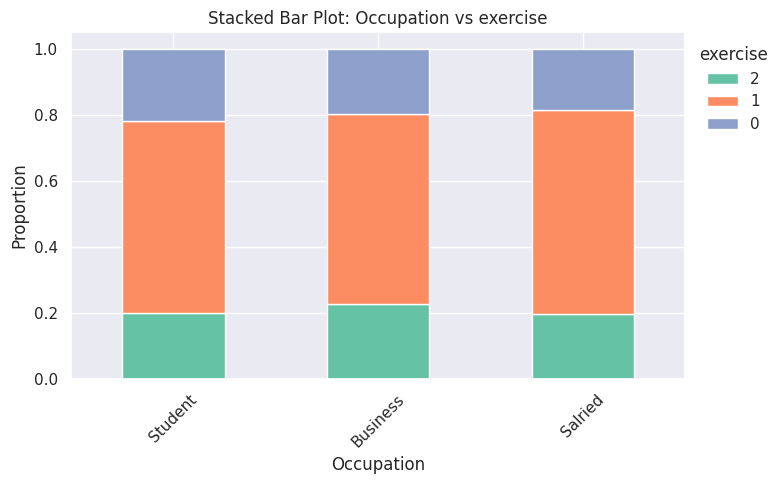

In [70]:
stacked_barplot_custom(data=df2, predictor='Occupation', target='exercise', palette='Set2')

**Observations:**

***Exercise Level 1 (Moderate):***
- Overall, across all occupations, 57% to 62% of individuals participate in moderate exercise.
- This exercise level is the most dominant in all three groups, making it the most frequent exercise level.
- The proportion is the same across the Business, Salaried, and Student groups.

***Exercise Level 2 (Extreme):***
- Overall, across all occupations, this exercise level comprises 19% to 23%.
- The Business group has a slightly higher proportion compared to the Student group and the Salaried group.
- The proportion in the Business group is approximately 22.5%, whereas in the Student group it is approximately 20%, and in the Salaried group it is approximately 19.6%.
- A smaller proportion of individuals participate in extreme exercise compared to moderate exercise.

***Exercise Level 0 (No Exercise):***
- Overall, across all occupations, approximately 18% to 22% of individuals participate in this exercise level.
- The Student group has a slightly higher proportion compared to the Business group and the Salaried group.
- The proportion in the Student group is approximately 22%, in the Business group it is approximately 19.8%, and in the Salaried group it is approximately 18.7%.
- The proportion in this exercise level is relatively stable across groups, only slightly varying.

**Insights:**

- Exercise patterns do not show significant variation across different occupations, as the proportionate distribution is very similar across groups.
- The majority of individuals in all groups participate in moderate exercise, which is a similar trend across the board.
- It seems that occupation is not a significant factor in determining the exercise pattern, which could indicate that other factors have a larger impact.


---

***Gender vs. Smoking Status***

- It analyzes different levels of smoking risks based on gender to assess individual's health risk.

smoking_status  Unknown  formerly smoked  never smoked  smokes    All
Gender                                                               
1                  4403              719          2581     875   8578
0                  3152             3610          6668    2992  16422
All                7555             4329          9249    3867  25000
----------------------------------------------------------------------------------------------------


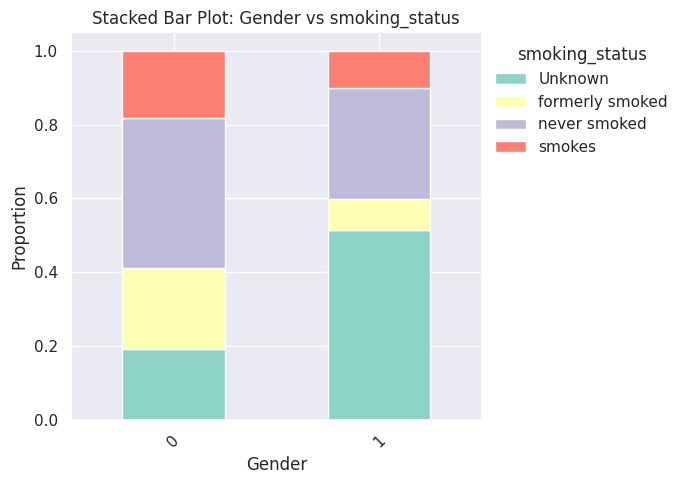

In [71]:
stacked_barplot_custom(data=df2, predictor='Gender', target='smoking_status', palette='Set3')

**Observations:**

* **Females here are represented by 1 and male by 0.**

***Unknown Smoking Status:***
- A significantly higher number of females have "Unknown" smoking status(approximately 51.3%), as opposed to those with males (approximately 19.2%).
- This suggests a large number of missing or unknown smoking status for the people with females.

***Formerly Smoked:***
- Approximately 22.0% of the people in the male group are classified as "Formerly Smoked", as opposed to approximately 8.4% in the female group.
- This category also shows a large disparity in the two groups.

***Never Smoked:***
- The majority of the people in both the groups fall in this category.
- However, the proportion of people in the males group (approximately 40.6%) is much higher than that in the females group (approximately 30.1%).

***Currently Smokes:***
- Approximately 18.2% of the people in the males group are classified as "Currently Smokes", as opposed to approximately 10.2% in the females group.
- This suggests that the prevalence of smoking in the males group is much higher than in the females group.

**Insights:**
- Smoking status shows a large disparity in the two gender groups, differentiating it from the observations made in the analysis of the other features.
- The proportion of people in the male group who are currently smoking or formerly smoked is much higher than that in the females group.
- There are a large number of unknown values in the case of the people in the females group, which may be a problem in the analysis.
- This attribute may also provide valuable insights if combined with the health-related attributes in the multivariate analysis.



---

##**Multivariate Analysis**

**We will perform mutivariate analysis to understanding how multiple factors together influence insurance cost.**

**Multivariate Analysis - Approach and Rationale**

Even though bivariate analysis is useful for understanding relationships between pairs of variables. However, in practice, insurance cost is determined based on the combined influence of all relevant variables. Hence, multivariate analysis is performed to examine interaction effects and uncover more profound relationships among variables.

***1. Correlation Heatmap (Global Relationship Analysis):***

The correlation heatmap is used to analyze the correlation among all numerical variables at once.

It is helpful for:
- Identifying important drivers for the target variable (insurance_cost)
- Detecting multicollinearity among features
- Eliminating less important features for further analysis

The correlation heatmap is a broad overview, and based on this, features can be identified that have strong statistical significance in the data.

***2. Interaction Effect Plots (Multi-variable Relationships):***

To understand how the relationship between the predictor and the target variable changes when the third variable is introduced, Interaction Effect Plots are used.

These plots are used for:
- Understanding the overall effect of lifestyle and clinical factors together
- Determining if certain groups, such as smokers and non-smokers, behave differently under the same conditions
- Uncovering patterns that are not visible through bivariate analysis

**With the inclusion of the third variable through color encoding (adding hue), these plots are simulating real-life conditions where all the factors are considered together, such as the effect of all the risk factors on insurance costs.**

**Overall, the depth of analysis is increased with the inclusion of multivariate analysis, where the focus is on the interactions between the variables.**

###**Correlation Analysis**

- Heatmap Analysis on All Numerical Columns for correlation analysis.

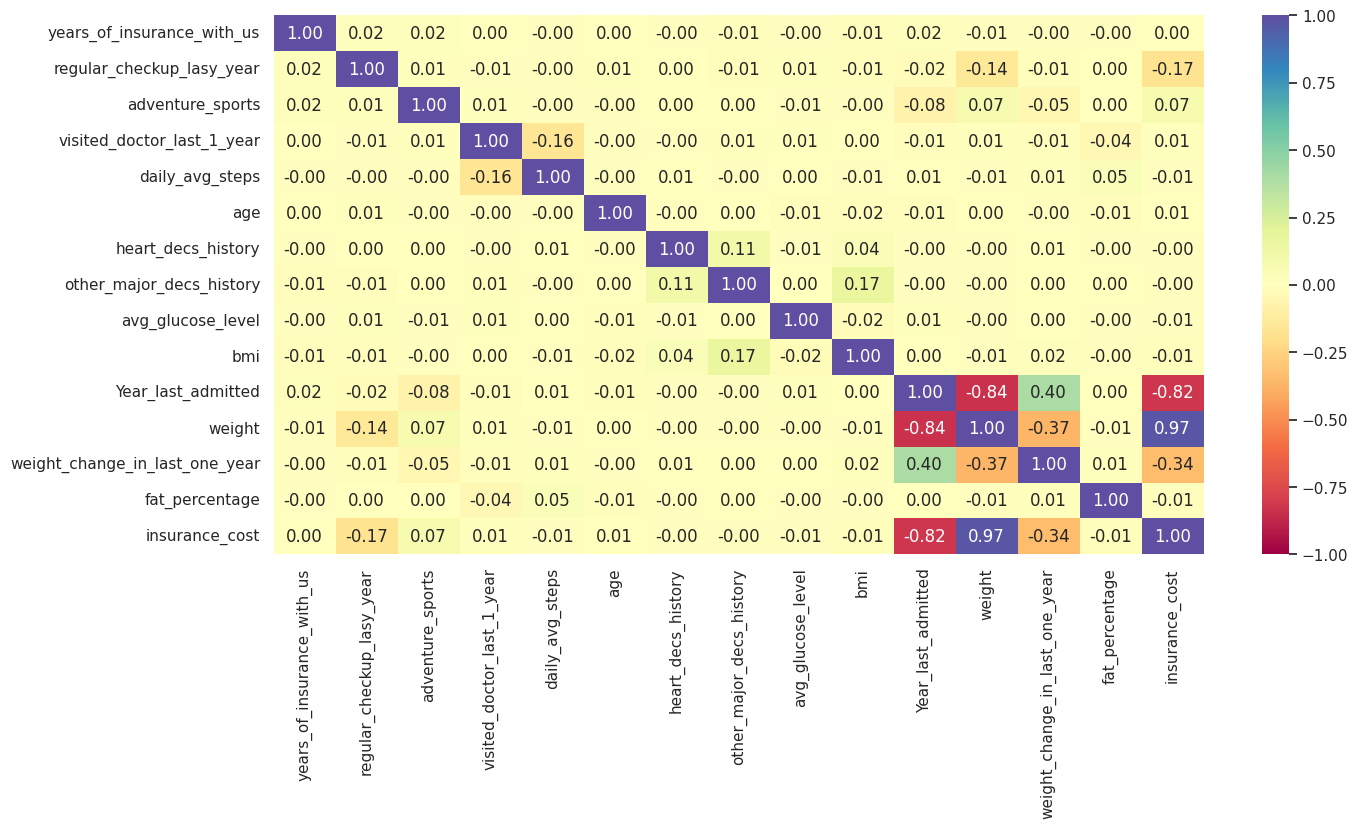

In [72]:
# To create the heatmap, We'll create a list of only the numerical variables
corr = df2.select_dtypes(include=np.number).columns.tolist()

# Now let's plot the heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(
    df2[corr].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observations: Multi-Collinearity Heatmap**
- ***Range:*** The Pearson correlation coefficient ranges from -1.00 to 1.00, covering the entire range.
- ***Top Positive Correlations:*** The 'weight' attribute shows a very high correlation of 0.97 with 'insurance_cost'.
- ***Top Negative Correlations:*** The 'Year_last_admitted' attribute shows a high negative correlation with 'insurance_cost' (-0.82) and 'weight' (-0.84).
-***Secondary Inter-correlations:*** 'weight_change_in_last_one_year' shows a negative correlation with 'weight' (-0.37) and a positive correlation with 'Year_last_admitted' (0.40).
- ***Feature-to-Feature Separation:*** The feature 'heart_decs_history' and 'other_major_decs_history' have a slight positive correlation of 0.11, but all other medical history features do not correlate with each other.
-***Near-Zero Interaction Matrix:*** All attributes, except 'weight', 'weight_change_in_last_one_year', and 'Year_last_admitted', show a near zero correlation with 'insurance_cost', i.e., 'age' (0.01), 'bmi' (-0.01), 'avg_glucose_level' (-0.01), and 'fat_percentage' (-0.01).


**Insights:Feature Interactions and Multi-Collinearity**

- **Primary Linear Weighting:** The near-linear relationship (0.97) between physical mass and financial output suggests that weight is the sole heavy-tailed pricing vector for this portfolio.

- ***Risk of Input Redundancy (Multicollinearity):*** The pairwise correlation of -0.84 between weight and Year_last_admitted indicates a critical multicollinearity threshold.

- ***Note: Standard Underwriting is the behind-the-scenes work done by insurance companies to assess an individual's health, lifestyle, and financial risks. The insurance company is making two decisions:***

   - Should we even offer client an insurance policy?

   - How much should client pay each month for the insurance (the premium)?

   - In insurance science, underwriters are required to follow specific rules. If customers are older, have heart disease, or visit the doctor often, underwriting rules require cost to be more expensive.

- ***Deviations from Standard Underwriting Theory:*** Standard underwriting tables suggest that recent clinical interventions and/or older age should be risk-increasing. However, the negative coefficient of Year_last_admitted (-0.82) and near-zero weighting of age (0.01) suggest a very high degree of architectural deviation from standard medical underwriting theory.



###**Interaction Effects**

***Weight vs. Insurance Cost by Smoking Status***

- This plot is used to assess whether people with similar weight are charged differently based on smoking status.

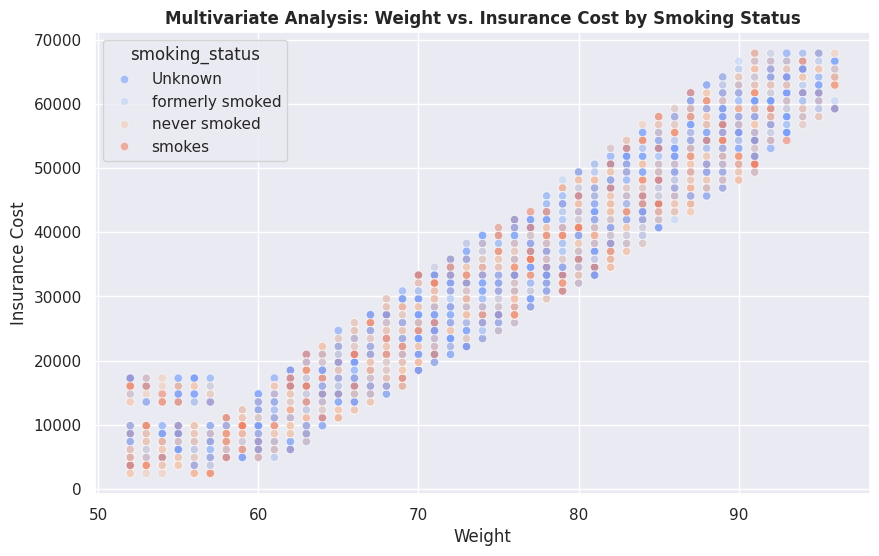

In [73]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='weight', y='insurance_cost', hue='smoking_status', data=df2, palette='coolwarm', alpha=0.6)
plt.title('Multivariate Analysis: Weight vs. Insurance Cost by Smoking Status', fontsize=12, fontweight='bold')
plt.xlabel('Weight')
plt.ylabel('Insurance Cost')
plt.show()

**Observations:**

- The variable weight varies between 52 and 95, whereas the insurance cost varies between 2,000 and 68,000.
- A strong positive linear relationship is observed between the weight variable and the insurance cost variable for all the smoking categories.
- The observations for the 'Unknown,' 'Formerly smoked,' 'Never smoked,' and 'Smokes' categories lie close to the same linear trend line, without any significant vertical separation between the groups.
- For similar weight groups, say in the range 70 to 80, the insurance costs for all the smoking groups lie in the same range, say between 25,000 and 50,000.
- A small amount of scatter is observed for each weight group, but this is not necessarily related to any specific smoking group.

**Insights:**

- Weight is the most significant factor in determining the insurance cost, even after considering the impact of the smoking status variable.
- Smoking status is not seen as a significant factor in the insurance pricing, as all the groups show the same trend in the insurance cost variable.
- The fact that the groups are not significantly separated implies that smoking status is not effectively integrated into the insurance pricing in this dataset.
- Therefore, the interaction between the weight variable and the smoking status variable in this dataset does not impact the insurance cost outcome, which is similar to the earlier observed fact that the weight variable is the most significant factor in determining the insurance cost.



---

***BMI vs Insurance Cost vs Exercise***

- This plot is used to assess whether people with similar BMI are charged differently based on their level of exercise.

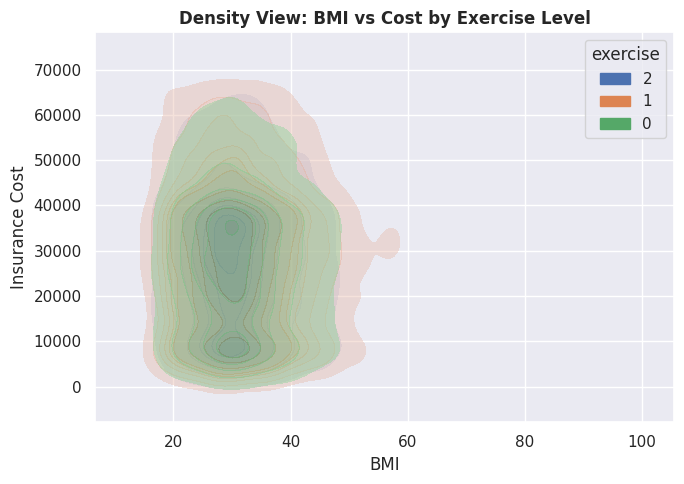

In [74]:
plt.figure(figsize=(7, 5))

sns.kdeplot(
    data=df2,
    x='bmi',
    y='insurance_cost',
    hue='exercise',
    fill=True,
    alpha=0.4
)

plt.title('Density View: BMI vs Cost by Exercise Level', fontsize=12, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Insurance Cost')
plt.tight_layout()
plt.show()

**Observations:**

- ***Central Overlap (BMI 25 to 35, Cost 5,000 to 40,000):*** Exercise levels display a substantial central overlap that cuts across every group.

- ***Lack of Isolation***: Exercise levels simply don't stand apart; they converge in that region with both medium cost and medium weight.

- ***Core Presence of Level 2 (Blue):*** Level 2 has the smallest exercise footprint but sits alongside all other exercise activities. It holds its core spot between BMI 25 to 35 and Costs of 5,000 to 40,000.

- ***Level 1 (Orange) Outer Expansion (BMI ~20 to 60, Cost upto 70,000):*** Level 1 moves out from the center, stretching into higher BMI territory and rising cost, showing that even moderate exercise levels can pair with higher costs at higher BMI.

- ***Level 0 (Green) Wide Distribution:*** Level 0 represents the most inactive group, making a big impact in the higher BMI (up to 50) and higher cost areas (up to 65,000). Its influence doesn't reach much into the lower-cost region.

***Insights:***

- ***High Activity Risk Containment:*** Exercise Level 2 leaves the smallest mark on the graph. People who work out often stay in the standard cost range (under 40,000).

- ***Combined Weight and Activity Limitations:*** Patterns from BMI and exercise frequency reveal BMI as the main driver for costs. People with BMI over 45 don't manage to cut their insurance expenses by ramping up exercise.

- ***Inadequate Cost Separation:*** Exercise levels don't do enough to separate cost ranges. Their central overlap blocks clear cost distinction unless we consider other features.


---

***Average Glucose Level vs Insurance Cost vs Heart Disease***

- This plot is used to assess whether people with similar levels of glucose are charged differently based on whether they have heart diseases.


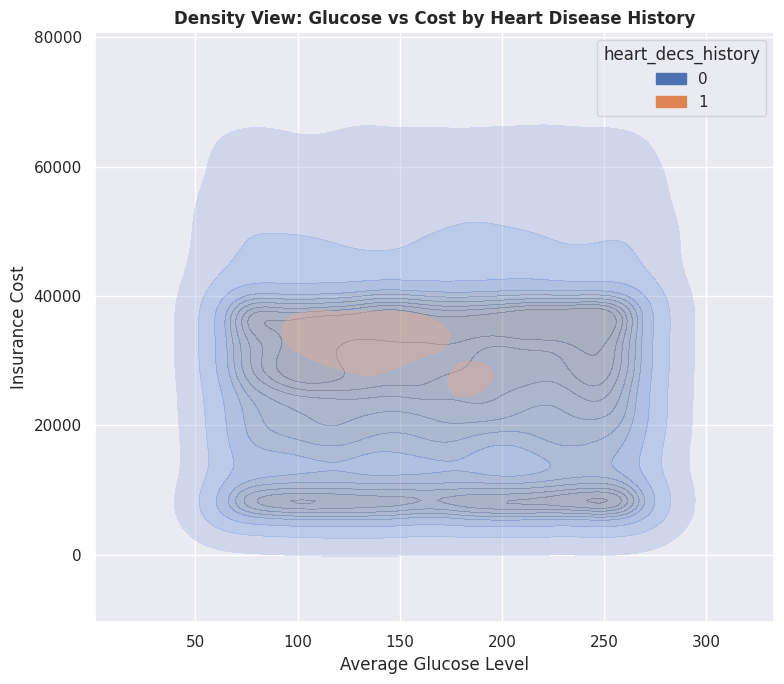

In [75]:
plt.figure(figsize=(8, 7))

sns.kdeplot(
    data=df2,
    x='avg_glucose_level',
    y='insurance_cost',
    hue='heart_decs_history',
    fill=True,
    alpha=0.4
)

plt.title('Density View: Glucose vs Cost by Heart Disease History', fontsize=12, fontweight='bold')
plt.xlabel('Average Glucose Level')
plt.ylabel('Insurance Cost')
plt.tight_layout()
plt.show()

**Observations:**

- ***Dominance of Non-Heart Disease History (Blue)***: Most of the graph is taken up by people without a heart disease history (Level 0). Their density contour stretches evenly from glucose levels of 50 up to 250, and insurance costs running from 5,000 all the way to over 65,000.

- ***Bimodal Cost Peaks for Level 0:*** Within this blue group, you see two clear bands where people cluster—one down near costs of 10,000, and another centered around 35,000.

- ***Compact Heart Disease Islands (Orange):*** People who have a heart disease history (Level 1) don't spread out much. Instead, they show up as tight, isolated groups in the middle of the graph—glucose between 100 and 200, and costs ranging from 25,000 to 40,000.


**Insights**

- ***Cost Normalization for Heart Disease:*** The orange group's tight range between 25,000 and 40,000, suggesting individuals with heart disease appear to be concentrated within a mid-to-high cost range.

- ***Glucose as a Silent Driver:*** For the blue group, insurance cost covers the full range across all glucose levels. So, glucose by itself doesn't act as a strong or simple divider for insurance pricing in this data.






##**Overall Insights From EDA**

**Primary Cost Drivers and Clinical Metrics**

- ***Weight is the primary cost driver:*** Weight has a very strong positive correlation with insurance costs (about 0.97 correlation), indicating that it is the key factor determining pricing in this dataset.
- ***Limited Impact of Independent Clinical Metrics:*** Key health metrics such as BMI, body fat percentage, average glucose levels, and age have almost no correlation with insurance costs. These variables do not independently influence insurance pricing.
- ***Lifestyle, medical history, and geographical factors:*** They show weak direct impact. Exercise, smoking status, heart disease history, and geography all show overlapping cost distributions, indicating that no single factor has a substantial effect on insurance costs. Bivariate analysis of Location vs Insurance_cost yielded nearly similar medians and IQR ranges across all 15 cities, demonstrating that geography has no regional price signal in this dataset.

**Data Quality & Structural Issues**

- ***Significant Structural Gaps in Data:*** There are roughly 990 missing rows in BMI and 47.5% in Year of Last Admission, as well as a big "Unknown" category in smoking status (around 30%).

- ***High Feature Independence & Imbalance:*** Most variables exhibit low inter-correlation and high data imbalance (e.g., adventure sports). This diminishes their predictive value without sufficient data pre-processing.

- ***Deviation from Real-World Underwriting:*** Observed connections (for example, a near-zero correlation between age and insurance cost) contradicts traditional insurance norms, showing synthetic or non-realistic data behaviour.


**The Considerations for Preprocessing**

- ***Missing Value Imputation is Required:*** With 990 missing BMI rows and 47.5% missing Year of Last Admission rows, we must use strong imputation methods (such as Grouped Medians) before feeding data into any algorithm.

- ***Outlier Capping is Required:*** Visual abnormalities that exceed a BMI of 60 and insurance costs of over 70,000 need to be further analysed and they might need for Capping (1% and 99%) to prevent distorted data.

- ***Feature Engineering is Critical:*** Because single predictors are ineffective, we should try integrate numerous features to extract a meaningful signal during preprocessing.



#**DATA PREPROCESSING**

##**Duplicate Values**

- We will check duplicate values.

In [76]:
print("Number of duplicate:")
df2.duplicated().sum()

Number of duplicate:


np.int64(0)

**Observations:**

* There are no duplicate values in our dataset.
* Our data is clean to be used for model.

##**Data Cleaning**

- This step is done to make our dataset accurate, consistent, and usable for further analysis and modeling.
- In this dataset will fix a typo in the column Occupation where the category name will be changed to 'Salried' to 'Salaried'. Also there is a spelling mistake in regular_checkup_lasy_year, we will fix it by renaming column name to regular_checkup_last_year.
- We have already dropped unnecessary column "applicant_id" in data overview section.
- Our EDA bivariate analysis of Location vs. Insurance_cost found nearly comparable cost distributions in all 15 cities, with medians constantly around 26,000 and overlapping IQRs. since, Location contains no regional pricing signal, it we will remove this column to reduce noise and keep the algorithm from learning misleading patterns.


In [77]:
df2['Occupation'] = df2['Occupation'].replace('Salried', 'Salaried')
df2['Occupation'].unique()
print("Unique values in Occupation:")
print(df2['Occupation'].unique())

# fix column name spelling by renaming the column
df2 = df2.rename(columns={'regular_checkup_lasy_year': 'regular_checkup_last_year'})
print("\nUnique values in regular_checkup_last_year:")
print(df2['regular_checkup_last_year'].unique())

Unique values in Occupation:
['Salaried', 'Student', 'Business']
Categories (3, object): ['Business', 'Salaried', 'Student']

Unique values in regular_checkup_last_year:
[1 0 4 3 2 5]


**Observations:**

- We have successfully fixed the typo in the category Salaries of column "Occupation" and column "regular_checkup_last_year".

In [78]:
df2.drop(columns=['Location'], inplace=True)
print(f"Shape after dropping Location: {df2.shape}")

Shape after dropping Location: (25000, 22)


**Observations:**

- We have successfully eliminated "location" column from our dataset.
- Now, shape of our dataset is 25000 rows and 22 columns.


##**Anomalous Value Check**

- This step is performed to check if logically impossible values are present in our dataset.
- For example presence of negative values in age, or bmi, weight, etc.


In [79]:
# Anomalous Value Check

# Age: biologically impossible values only
print("Age < 0:", (df2['age'] < 0).sum())
print("Age > 120:", (df2['age'] > 120).sum())

# Weight: impossible values
print("Weight <= 0:", (df2['weight'] <= 0).sum())

# BMI: impossible values (not extreme, just impossible)
print("BMI <= 0:", (df2['bmi'] <= 0).sum())

# extreme BMI values (Super Obesity threshold, bmi > 60)
print("BMI > 60:", (df2['bmi'] > 60).sum())

# Fat percentage: impossible values
print("Fat % < 0:", (df2['fat_percentage'] < 0).sum())
print("Fat % > 100:", (df2['fat_percentage'] > 100).sum())

# Glucose: impossible values
print("Glucose <= 0:", (df2['avg_glucose_level'] <= 0).sum())

# Insurance cost: impossible values
print("Insurance cost <= 0:", (df2['insurance_cost'] <= 0).sum())


Age < 0: 0
Age > 120: 0
Weight <= 0: 0
BMI <= 0: 0
BMI > 60: 89
Fat % < 0: 0
Fat % > 100: 0
Glucose <= 0: 0
Insurance cost <= 0: 0


**Observations:**

- No anomalous records were found in any of the domain-critical checks; the dataset does not contain any negative ages, weights, glucose levels, or impossible fat percentages.
- The anomalous check only flags 89 records with a BMI greater than 60.
- The medical classification of Super Obesity/Extreme Obesity, which is uncommon but clinically documented and acknowledged, applies to BMI > 60. Additionally, the 25,000 rows, these 89 records make up roughly 0.36%.


**Insights:**

- These records shouldn't be deleted or updated in this step because BMI > 60 is a legitimate medical condition rather than a data entry error or logical impossibility.
- By removing genuine high-risk individuals from the dataset, their removal would introduce selection bias and impair model generalisation.

- Therefore, these records will be addressed during the outlier treatment phase using Winsorization rather than removal.

##**Missing Values Check & Treatment**

- We will check missing values first.

In [80]:
print("Missing values:")
df2.isnull().sum()

Missing values:


,0
years_of_insurance_with_us,0
regular_checkup_last_year,0
adventure_sports,0
Occupation,0
visited_doctor_last_1_year,0
cholesterol_level,0
daily_avg_steps,0
age,0
heart_decs_history,0
other_major_decs_history,0


**Observations:**

- We observed missing values in the columns bmi: 990 missing (~ 4% of dataset) and Year_last_admitted with 11,881 missing (~ 47.5% of the dataset).
- We will treat both columns missing values differently.



###**Missing Values Treatment**

- ***BMI missing  values (~ 4%, low)*** will be handled using median imputation, categorised by gender as bmi differs across different demographics. The median is chosen over the mean due to the occurrence of severe outliers (e.g., BMI > 100), which will ensure robustness and prevented distribution distortion.
- ***Year_last_admitted missing values (~ 47.5%, very high)***, this could be due to people likely never admitted based on domain knowledge. Since almost 48% of the data is missing, therefore using mean/median (≈2004) would falsely suggest hospitalisation, which is statistically incorrect. Our EDA identified this as structural defect in data (not applicable—never hospitalised) and standard imputation methods here would create significant bias. Therefore, we will use feature "ever_hospitalized" using feature engineering method and we will drop the original column to preserve the data integrity.


In [81]:
# Create df3 as a copy of df2
df3 = df2.copy()

# BMI: Treating missing values via grouped Median by Gender
bmi_median_by_gender = df3.groupby('Gender')['bmi'].median()
df3['bmi'] = df3.apply(
    lambda row: bmi_median_by_gender[row['Gender']]
    if pd.isna(row['bmi']) else row['bmi'], axis=1
)

# Year_last_admitted: treating missing values via feature Engineering
df3['ever_hospitalized'] = df3['Year_last_admitted'].notna().astype(int)

reference_year = 2018 # Max value of Year_last_admitted as per statistical summary
df3['years_since_last_admission'] = df3['Year_last_admitted'].apply(
    lambda x: reference_year - int(x) if pd.notna(x) else 0
)

df3.drop(columns=['Year_last_admitted'], inplace=True) #dropping the Year_last_admitted column


print("-" * 30)

# Verify results
print("Missing values remaining:\n", df3.isnull().sum()[df3.isnull().sum() > 0])


print(" " * 30)
print("-" * 30)

print(df3.info())

------------------------------
Missing values remaining:
 Series([], dtype: int64)
                              
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   years_of_insurance_with_us      25000 non-null  int64   
 1   regular_checkup_last_year       25000 non-null  int64   
 2   adventure_sports                25000 non-null  int64   
 3   Occupation                      25000 non-null  category
 4   visited_doctor_last_1_year      25000 non-null  int64   
 5   cholesterol_level               25000 non-null  category
 6   daily_avg_steps                 25000 non-null  int64   
 7   age                             25000 non-null  int64   
 8   heart_decs_history              25000 non-null  int64   
 9   other_major_decs_history        25000 non-null  int64   
 1

**Observations:**

- No Missing values for column bmi & ever_hospitalized after median imputation grouped by gender & feature engineering.
- We created two features from **Year_last_admitted** to retain relevant information:
  - 1. **ever_hospitalized** (binary 0/1): Indicates if patient was **ever hospitalized** (1 if year exists, 0 if NaN). It is of int data type.

  - 2. **years_since_last_admission** (numeric): **Years elapsed** since last admission using 2018 as reference (2018 - Year_last_admitted, 0 if never hospitalized). It is of int data type.

-  We dropped "Year_last_admitted" to avoid redundancy.
- The dataset was found to have zero remaining missing values, suggesting successful completion of the missing value treatment procedure.

##**Outlier Check and Treatment**

- In this step, we will check if there are outliers in our dataset. These outliers represent data points that deviate significantly from the rest of the dataset. Therefore, checking & treating them appropriately is critical for assuring the quality of statistical data, enhancing machine learning model performance, and finding valuable, unusual, or inconsistent information.

- In our EDA section, many columns like bmi, visited_doctor_last_1_year, insurance_cost, etc, have outliers.
- We will also check outliers via IQR method.

###**Outliers Check via IQR Method & Box Plot**

In [82]:
def check_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}:")
    print(f"Lower Bound: {lower:.2f}, Upper Bound: {upper:.2f}")
    print(f"Outliers count: {len(outliers)}")
    print("-"*40)

    return lower, upper



outlier_bounds = {}

for col in ['bmi', 'avg_glucose_level', 'daily_avg_steps',
            'visited_doctor_last_1_year', 'insurance_cost', 'ever_hospitalized']:

    lower, upper = check_outliers_iqr(df3, col)
    outlier_bounds[col] = (lower, upper)

bmi:
Lower Bound: 12.55, Upper Bound: 48.95
Outliers count: 611
----------------------------------------
avg_glucose_level:
Lower Bound: -50.50, Upper Bound: 385.50
Outliers count: 0
----------------------------------------
daily_avg_steps:
Lower Bound: 2762.50, Upper Bound: 7510.50
Outliers count: 952
----------------------------------------
visited_doctor_last_1_year:
Lower Bound: -1.00, Upper Bound: 7.00
Outliers count: 96
----------------------------------------
insurance_cost:
Lower Bound: -15425.00, Upper Bound: 68487.00
Outliers count: 0
----------------------------------------
ever_hospitalized:
Lower Bound: -1.50, Upper Bound: 2.50
Outliers count: 0
----------------------------------------


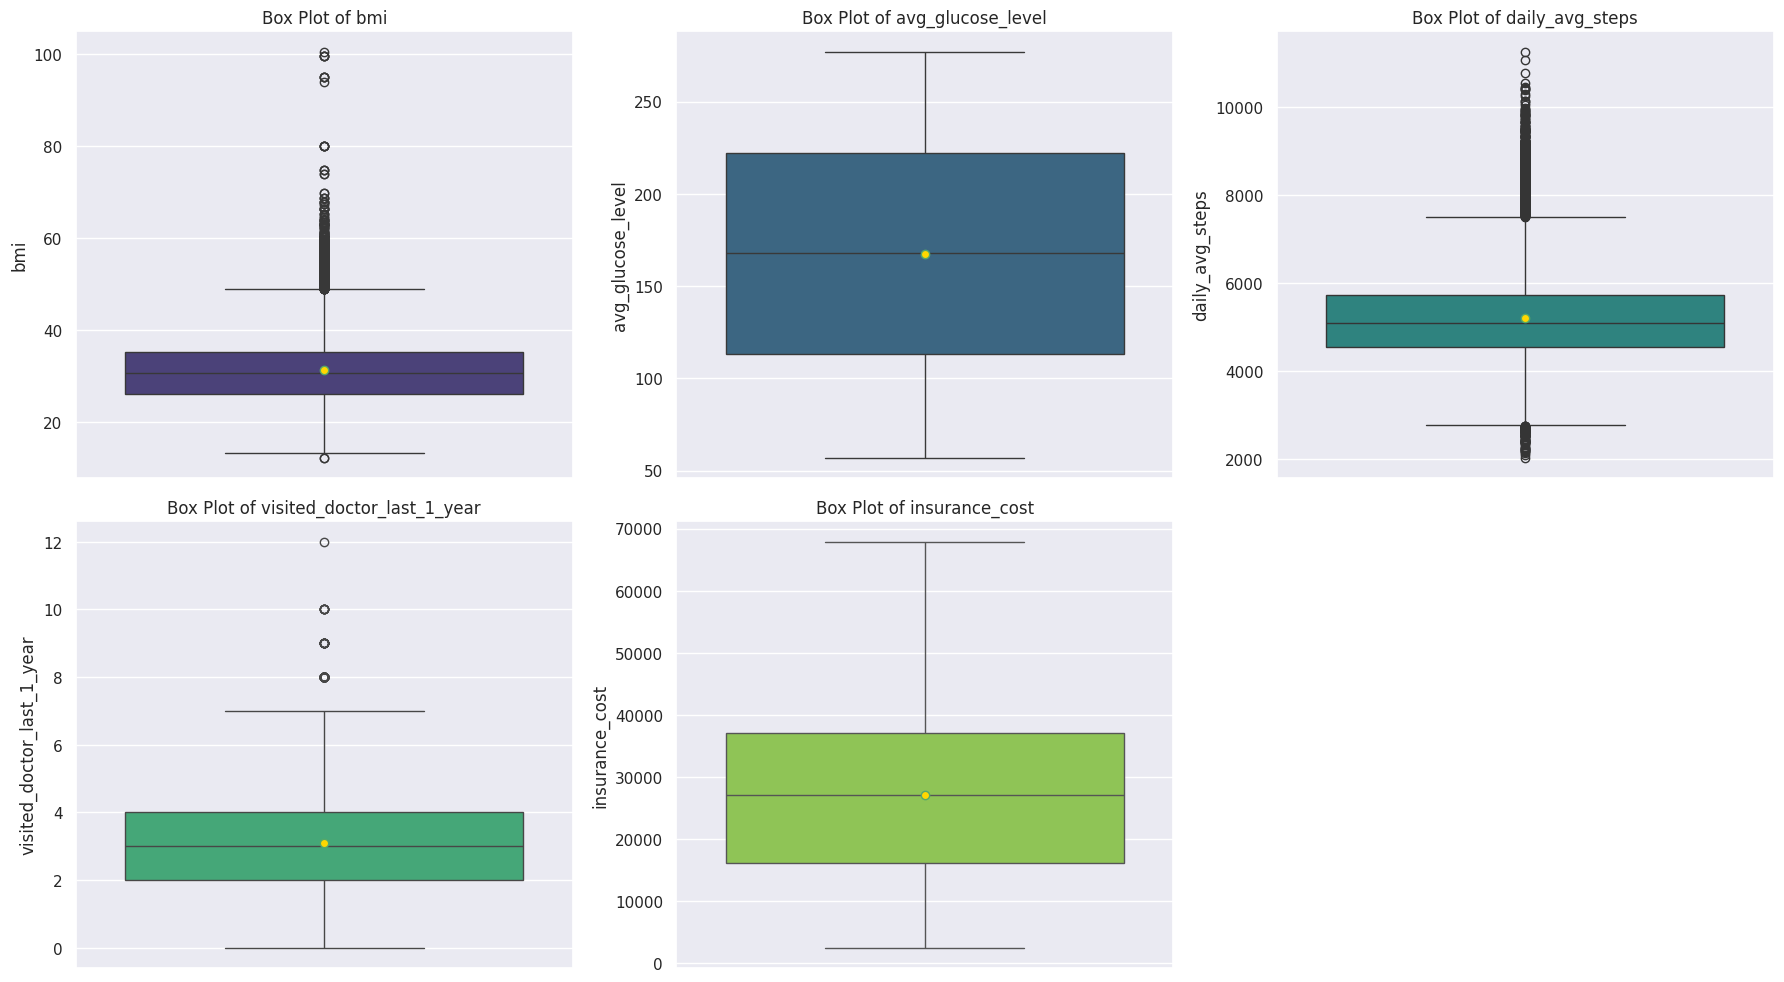

In [83]:
import math

box_cols = ['bmi', 'avg_glucose_level', 'daily_avg_steps', 'visited_doctor_last_1_year', 'insurance_cost']

# Calculate the number of rows and columns needed dynamically
num_plots = len(box_cols)
ncols = 3  # Max 3 columns per row for better readability
nrows = math.ceil(num_plots / ncols)

# Create a single figure with subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))

# Flatten the axes array for easy iteration, handling cases where nrows=1
if nrows == 1 and ncols > 1: # For a single row with multiple columns
    axes = axes
elif nrows == 1 and ncols == 1: # For a single plot
    axes = [axes]
else:
    axes = axes.flatten()

# Generate a color palette for distinct colors
palette = sns.color_palette("viridis", num_plots)

for i, col1 in enumerate(box_cols):
    sns.boxplot(y=df3[col1], ax=axes[i], showmeans=True,
                meanprops={"marker": "o", "markerfacecolor": "gold"}, color=palette[i])
    axes[i].set_title(f'Box Plot of {col1}')
    axes[i].set_ylabel(col1) # Set y-label for clarity
    axes[i].set_xlabel('') # Remove x-label from individual subplots if not needed

# Turn off any unused subplots if the grid has more slots than plots
for j in range(num_plots, nrows * ncols):
    if j < len(axes): # Ensure index is within bounds of flattened axes
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observations:**

- The presence of extreme body mass values is indicated by the BMI's 611 outliers (2.44% of dataset), which have values above the upper bound of 48.95. While some of these might be unrealistic entries, others might be rare medical cases.
- The presence of highly active people is suggested by the daily average steps, which show 952 outliers above 7510 steps. However, these values represent genuine behavioural variation and are realistic in real-world situations.
- There are 96 outliers in the number of doctor visits above 7 visits, which indicate people who use healthcare services at an abnormally high rate.
- There are no statistical outliers in the average glucose level or insurance cost, suggesting that their distributions are valid but naturally wide.
- There are no outliers in ever_hospitalized because it is a binary feature (0 or 1). IQR method, naturally shows no statistical outliers for such variables unless there are invalid enteries outside of binary values.

**Treatment Decisions & Insights:**

***1. bmi — IQR based clipping***

- A disproportionately long right skew is produced by the extreme upper tail stretching from 49 to 100.6, even though BMI values above 60 are clinically valid (Super Obesity).
- Such extreme values can significantly distort model coefficients in linear and distance-based models, pushing predictions toward the extremes and decreasing the ability to generalise.
- In order to compress the extreme tail while maintaining the overall distribution shape, we will use IQR clipping method.

***2. daily_avg_steps—No Treatment***

- 952 outliers represent genuine behavioural variation.
— It represents highly active and sedentary individuals.
- Capping would eliminate true population variety and weaken the predictive signal. Therefore, we will not treat these outliers.


***3. visited_doctor_last_1_year — No Treatment***

- 96 records with more than 7 visits represent genuine high-frequency patients with complex medical conditions. Therefore, they will be retained.


***3. Avg_glucose_level -  No Treatment***

- Zero outliers detected. All values naturally fall inside the IQR-based range.


***4. Insurance_cost — No Treatment***
- No outliers detected. Furthermore, changing the target variable's values would alter the prediction objective regardless of the presence of outliers.


###**Outliers Treatment**

In [84]:
# Before treatment check min/max BMI values
print(f"BMI before treatment: Min={df3['bmi'].min():.2f}, Max={df3['bmi'].max():.2f}")

# IQR - Calculates 25th (Q1) & 75th percentile (Q3) and IQR range = Q3-Q1
Q1 = df3['bmi'].quantile(0.25)
Q3 = df3['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR  #lower bound value : this is an outlier (1.5×IQR below Q1)
upper = Q3 + 1.5 * IQR  #uuper bound value : this is an outlier (1.5×IQR above Q3)

# Clipping
df3['bmi'] = df3['bmi'].clip(lower, upper)  #bmi < lower → becomes lower, bmi > upper → becomes upper, lower ≤ bmi ≤ upper → unchanged

# After treatment- new min/max bmi value
print(f"BMI after treatment : Min={df3['bmi'].min():.2f}, Max={df3['bmi'].max():.2f}")

# Verify
remaining_outliers = df3[(df3['bmi'] < lower) | (df3['bmi'] > upper)].shape[0]
print(f"BMI outliers remaining: {remaining_outliers}")

BMI before treatment: Min=12.30, Max=100.60
BMI after treatment : Min=12.55, Max=48.95
BMI outliers remaining: 0


**Observations:**
- BMI outliers were addressed via IQR-based clipping, with values capped at 12.55 (new min) and 48.95 (new max).
- Post-treatment verification revealed no remaining outliers, keeping the distribution within statistically acceptable bounds.


##**Feature Engineering**

We performed feature engineering to transform raw features into more informative predictors, enabling the model to better capture the underlying clinical signals and improve predictive accuracy.



###**Validating ever_hospitalized feature**

- We created a new feature "ever_hospitalised" from Year last admiited in previous missing value section.

- Before using ever_hospitalized column which we created in missing value treatment section to do further feature engineering, we need to ensure it represents a relevant medical subgroup rather than random missingness.

In [85]:
# Distribution of ever_hospitalized
print("ever_hospitalized distribution:")
print(" "*30)
print(df3['ever_hospitalized'].value_counts())
print(" "*30)
print("-"*30)
print("ever_hospitalized distribution (normalized):")
print(df3['ever_hospitalized'].value_counts(normalize=True).round(2))

print(" "*30)
print("-"*30)
# Relationship with years of insurance
print("\never_hospitalized vs years_of_insurance_with_us:")
print(pd.crosstab(df3['ever_hospitalized'],
                  df3['years_of_insurance_with_us'],
                  normalize='index').round(2))
print(" "*30)
print("-"*30)
# Relationship with external coverage
print("\never_hospitalized vs covered_by_any_other_company:")
print(pd.crosstab(df3['ever_hospitalized'],
                  df3['covered_by_any_other_company'],
                  normalize='index').round(2))

ever_hospitalized distribution:
                              
ever_hospitalized
1    13119
0    11881
Name: count, dtype: int64
                              
------------------------------
ever_hospitalized distribution (normalized):
ever_hospitalized
1    0.52
0    0.48
Name: proportion, dtype: float64
                              
------------------------------

ever_hospitalized vs years_of_insurance_with_us:
years_of_insurance_with_us     0     1     2     3     4     5     6     7  \
ever_hospitalized                                                            
0                           0.25  0.24  0.15  0.06  0.06  0.06  0.06  0.06   
1                           0.00  0.00  0.00  0.17  0.17  0.17  0.16  0.17   

years_of_insurance_with_us     8  
ever_hospitalized                 
0                           0.06  
1                           0.17  
                              
------------------------------

ever_hospitalized vs covered_by_any_other_company:
covered_by_any

**Observations**
-  **Balanced distribution**: 52% hospitalised (13,119); 48% never (11,881), indicating that this is not random missingness but a structurally relevant division.
-  Never-hospitalized group (0) is concentrated in tenure years 0 and 1 (25% and 24%), suggesting that newer customers likely to have no hospitalisation history.
- Hospitalised group (1) has zero representation in tenure years 0 and 1, but then evenly distributed at ~17% from year 3 onwards, indicating that longer tenure customers have more documented medical history.
- The never-hospitalized group has 80% without external coverage, whereas the hospitalised group has 60%; previously hospitalised persons are more inclined to seek extra coverage.

**Insights**
- The significant difference in tenure distribution between groups (0-1 years vs 3+ years) strongly shows that a hospitalisation history becomes more frequent with longer policy tenure. This pattern may reflect either increased likelihood of hospitalization over longer tenure or better documentation of medical history for long-term customers.
- Higher external coverage among the hospitalised group (40% vs 20%) makes logical sense, because individuals with medical history aggressively seek additional insurance protection.
- Most significantly, this non-random distribution across tenure and coverage indicates that ever_hospitalized captures a meaningful subgroup, indicating its good to include it as a in the new feature.

###**Creating new feature "health_risk_score"**

- Features like heart_decs_history, other_major_decs_history, and ever_hospitalized are each a weak binary signal as per our previous analysis. Therefore, combining them into one feature to record medical risk score to capture the entire health risk profile of customers may provide better cost prediction.

In [86]:
df3['health_risk_score'] = (
    df3['heart_decs_history'] +
    df3['other_major_decs_history'] +
    df3['ever_hospitalized']
)

print("health_risk_score value counts:")
print(df3['health_risk_score'].value_counts().sort_index())

health_risk_score value counts:
health_risk_score
0    10169
1    12890
2     1774
3      167
Name: count, dtype: int64


**Observations**

- The health_risk_score runs from 0 to 3, with 0 representing no medical risk factors and 3 suggesting the presence of all three risk factors simultaneously.  
- Score 1 is the most common group, with 12,890 people, closely followed by score 0 group, which has 10,169. These two groups represent 92% of the entire population.  
- Score 2 has 1,774 customers, while score 3 has only 167, accounting for 0.67% of the dataset.  
- The distribution indicates a clear downward trend, as the medical risk grows from 1 to 3, fewer people fall into the higher-risk category, which corresponds to real-world health demographics.

**Insights**

- The dominance of score 1 over score 0 might be mostly due to ever_hospitalized, which accounts for 52% of positive cases, indicating that most customers have at least one risk factor even if they have no disease history.  
- Higher risk scores (0.67%) are relatively rare, which might help the model differentiate high-risk individuals more distinctly.
- Combining multiple health indicators into a one score simplifies the feature while preserving relevant health-related information.



###**EDA on All 3 Engineered Features**

- Now we will do EDA to validate whether newly created features (ever_hospitalized, years_since_last_admission, health_risk_score) show a meaningful variation in insurance cost (target variable) before model training.

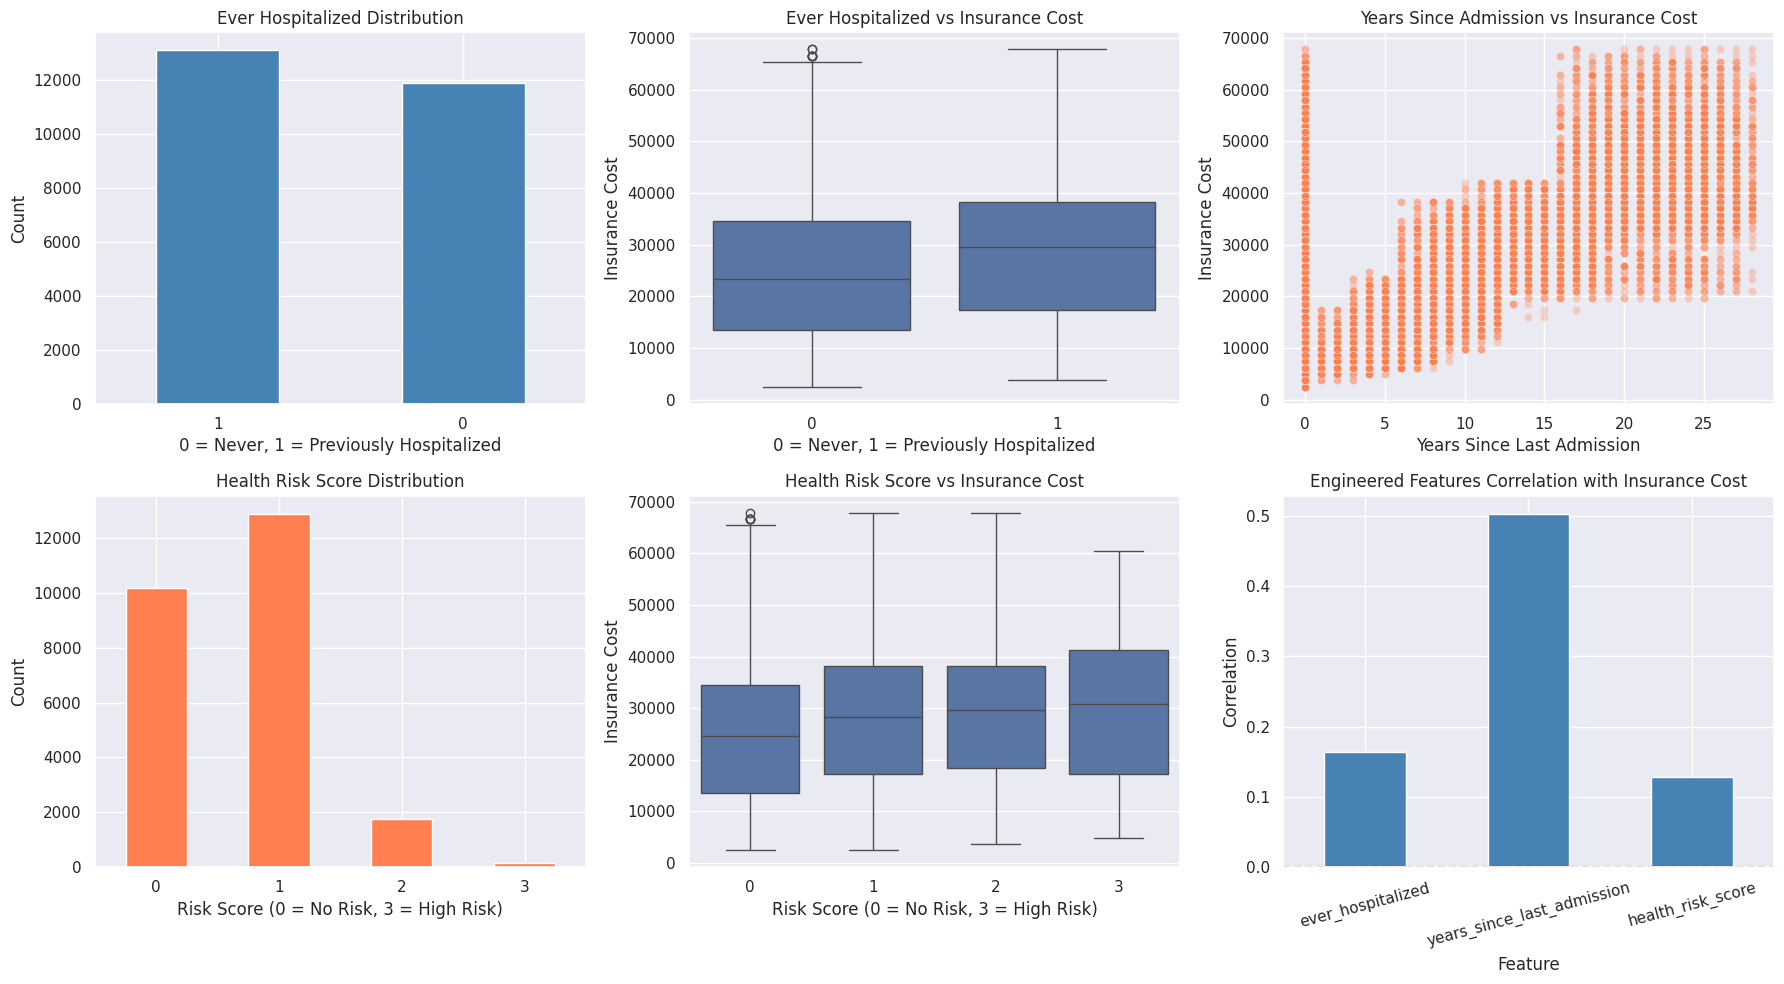

------------------------------

Correlation with insurance_cost:
ever_hospitalized             0.164121
years_since_last_admission    0.502885
health_risk_score             0.128287
insurance_cost                1.000000
Name: insurance_cost, dtype: float64


In [87]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. ever_hospitalized distribution
df3['ever_hospitalized'].value_counts().plot(
    kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Ever Hospitalized Distribution')
axes[0,0].set_xlabel('0 = Never, 1 = Previously Hospitalized')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. ever_hospitalized vs insurance_cost
sns.boxplot(x='ever_hospitalized', y='insurance_cost',
            data=df3, ax=axes[0,1])
axes[0,1].set_title('Ever Hospitalized vs Insurance Cost')
axes[0,1].set_xlabel('0 = Never, 1 = Previously Hospitalized')
axes[0,1].set_ylabel('Insurance Cost')

# 3. years_since_last_admission vs insurance_cost
sns.scatterplot(x='years_since_last_admission', y='insurance_cost',
                data=df3, ax=axes[0,2], alpha=0.3, color='coral')
axes[0,2].set_title('Years Since Admission vs Insurance Cost')
axes[0,2].set_xlabel('Years Since Last Admission')
axes[0,2].set_ylabel('Insurance Cost')

# 4. health_risk_score distribution
df3['health_risk_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Health Risk Score Distribution')
axes[1,0].set_xlabel('Risk Score (0 = No Risk, 3 = High Risk)')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=0)

# 5. health_risk_score vs insurance_cost
sns.boxplot(x='health_risk_score', y='insurance_cost',
            data=df3, ax=axes[1,1])
axes[1,1].set_title('Health Risk Score vs Insurance Cost')
axes[1,1].set_xlabel('Risk Score (0 = No Risk, 3 = High Risk)')
axes[1,1].set_ylabel('Insurance Cost')

# 6. Correlation of engineered features with target
corr_data = df3[['ever_hospitalized', 'years_since_last_admission',
                  'health_risk_score', 'insurance_cost']].corr()['insurance_cost'].drop('insurance_cost')
corr_data.plot(kind='bar', ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Engineered Features Correlation with Insurance Cost')
axes[1,2].set_xlabel('Feature')
axes[1,2].set_ylabel('Correlation')
axes[1,2].tick_params(axis='x', rotation=15)
axes[1,2].axhline(y=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

print("-"*30)
# Print correlation values
print("\nCorrelation with insurance_cost:")
print(df3[['ever_hospitalized', 'years_since_last_admission',
           'health_risk_score', 'insurance_cost']].corr()['insurance_cost'])


**Observations:**

***ever_hospitalised***

- The distribution bar chart shows that the previously hospitalised group (1) is somewhat larger at 13,119 than the never hospitalised group (0) at 11,881, a nearly equal split.
- The boxplot shows that previously hospitalised customers (1) have a much higher median insurance cost of roughly 30,000 than never hospitalised individuals (0) at around 24,000.
- The never hospitalized group (0) had a tighter IQR than the hospitalised group (1), suggesting greater cost variability among previously hospitalised individuals.


***Years since Last Admission***

- The scatter plot shows a general upward trend, it suggests as years since last admission increases, insurance costs tend to increase toward higher ranges.
- A dense vertical cluster at 0 years represents never hospitalized customers, with prices ranging widely.
- Higher cost ranges are more common for data points made after ~15 years after admission, but there is still some variability.


***Health Risk Score***

- The bar chart displays that score 1 is the most common category (12,890), followed by score 0 (10,169), with scores 2 and 3 becoming increasingly uncommon.
- The boxplot shows a distinct rising trend in median insurance cost from score 0 (about 25,000) to score 1, score 2, and score 3 (32,000).
- Score 3 shows a visibly higher median with the widest box among all scores, suggesting higher cost variability at the highest risk group despite having only 167 customers.


***Correlation***

- Years_since_last_admission dominates with a correlation of 0.50 and is visually the highest bar by a substantial margin.
- ever_hospitalized has a moderate positive correlation coefficient of 0.16.
- Health_risk_score has the smallest correlation (0.13) among the three designed features.





###**Overall EDA Insights from Engineered Features**

- All engineered features have positive correlations with insurance costs, which demonstrates that feature engineering has added useful predictive information to the dataset.
Years_since_last_admission is the most influential engineered feature, with the strongest correlation (~0.50) and a noticeable upward trend in the scatter plot.

- ever_hospitalized separates different customer groups, as previously hospitalised clients have higher insurance costs and greater unpredictability.
- health_risk_score detects a steady rise in insurance costs as risk level grows, suggesting that integrating numerous health indicators into a single feature yields a valuable aggregated signal.

- Despite such patterns, there is diversity within each group, indicating that insurance costs are influenced by more than just particular engineering features.

- Overall, the engineered features collectively capture temporal (years), binary (hospitalization status), and cumulative (risk score) aspects of health risk, improving the dataset's potential to represent patterns which are relevant for modeling.



##**Class Imbalance Handling**

- This step is performed to identify any disproportionate distribution of target variable, ensuring the model does not develop a biased preference for the majority class at the expense of rare but critical clinical events.
- In order to determine if we need to handle class imbalance for this dataset, we must verify the insurance_cost (target variable) data type & statistical distributions.



In [88]:
print("Target variable (insurance_cost) type:", df3['insurance_cost'].dtype)
print("-"*45)
print(df3['insurance_cost'].describe())



Target variable (insurance_cost) type: int64
---------------------------------------------
count    25000.000000
mean     27147.407680
std      14323.691832
min       2468.000000
25%      16042.000000
50%      27148.000000
75%      37020.000000
max      67870.000000
Name: insurance_cost, dtype: float64


**Observations:**

- The **target variable "insurance_cost" is continuous** in nature, with values ranging from 2,468 to 67,870 and has an average of around 27,147.

- Since the target variable is continuous & variable in nature (a regression problem), indicating **class imbalance handling is not applicable, and no treatment required in this case**, because class imbalance handling is applied exclusively to classification problems where target variables are discrete and potentially unequal in frequency.



##**Dataframe for GENAI**

- Created a clean A CLEAN CHECKPOINT FOR THE GENAI DASHBOARD (BEFORE ENCODING)

In [89]:
# We make a deep copy of df3 while text columns are still intact as strings,
# but AFTER missing values, outliers, and your new features are completely ready!
genai_df = df3.copy()

print("GenAI narrative checkpoint created! Categorical text features preserved safely.")

GenAI narrative checkpoint created! Categorical text features preserved safely.


##**Data preparation for modeling**

This step requires us to prepare the data so that machine learning algorithms could accurately and without bias process the raw clinical data. In particular, we used:
- Encoding changes categorical labels into numbers that models can understand mathematically.
- We should split the data into a training set and a test set so that you can test the model on data it hasn't seen before. This will make sure that it works well on new data instead of just memorising the training set.
- Feature Scaling normalises variables that have different units (like age and lab values) so that features with larger scales don't have a bigger effect on the model.
- Data Leakage Checks to make sure that information from the test set or the future doesn't "leak" into the training process. If this happens, the performance metrics will be unrealistically high but wrong.

Therefore, performing above steps are crucial to obtain accurate results from modeling.

###**Encoding All Categorical Columns**

- Machine learning algorithms cannot handle categorical (text-based) data points. Therefore, categorical columns must be encoded with binary mapping for yes/no features, ordinal mapping for ranking groups, and one-hot encoding for nominal categories.
- In the EDA section we have already encoded columns like 'Gender', 'covered_by_any_other_company', 'Alcohol', 'exercise', 'cholesterol_level'. So, we will not encode them again.
- However, we will encode remaining categorical columns like 'smoking_status' using binary mapping, and 'Occupation' via one-hot encoding technique.

In [90]:
# Check missing values in categorical columns
cat_cols = df3.select_dtypes(include=['object', 'category']).columns
print("Missing values in categorical columns:", df3[cat_cols].isnull().sum())


Missing values in categorical columns: Occupation                      0
cholesterol_level               0
Gender                          0
smoking_status                  0
covered_by_any_other_company    0
Alcohol                         0
exercise                        0
dtype: int64


**Observations:**
- No missing values in categorical data.
- Since our data is clean, we can proceed with encoding.

In [91]:
# Smoking Status string cleaning
df3['smoking_status'] = df3['smoking_status'].astype(str)
df3['smoking_status'] = df3['smoking_status'].str.strip().str.lower()
df3['smoking_status'] = df3['smoking_status'].replace('unknown', np.nan)

# Fill with mode
df3['smoking_status'].fillna(df3['smoking_status'].mode()[0], inplace=True)

# Encode
df3['smoking_status'] = df3['smoking_status'].map({
    'never smoked': 0,
    'formerly smoked': 1,
    'smokes': 2
})


# One-Hot Encoding
df3 = pd.get_dummies(df3, columns=['Occupation'], drop_first=True)


# Verify
print("Remaining object columns:", df3.select_dtypes(include='object').columns.tolist())
print("Shape after encoding:", df3.shape)
print("-"*30)
print("Total missing values:", df3.isnull().sum().sum())
print("-"*30)
print("Columns after encoding:")
print(df3.columns.tolist())

Remaining object columns: []
Shape after encoding: (25000, 25)
------------------------------
Total missing values: 0
------------------------------
Columns after encoding:
['years_of_insurance_with_us', 'regular_checkup_last_year', 'adventure_sports', 'visited_doctor_last_1_year', 'cholesterol_level', 'daily_avg_steps', 'age', 'heart_decs_history', 'other_major_decs_history', 'Gender', 'avg_glucose_level', 'bmi', 'smoking_status', 'weight', 'covered_by_any_other_company', 'Alcohol', 'exercise', 'weight_change_in_last_one_year', 'fat_percentage', 'insurance_cost', 'ever_hospitalized', 'years_since_last_admission', 'health_risk_score', 'Occupation_Salaried', 'Occupation_Student']


**Observations**

- Both the categorical variables successfully mapped and one-hot encoded.
- Smoking status categories like 'unknown" (over 30% of data) was replaced with NaN value and then imputed with mode values instead of dropping to preserve the data integrity. We successfully mapped 'never smoked': 0, 'formerly smoked': 1, and 'smokes': 2.
- One-hot encoding was performed on the column Occupation succesfully.
- Now, final dataset dimensions are 25,000 rows and 25 columns.
- There are no mising/null values and existing object type column.
- Since, our data is clean, we can proceed with Train-Test split.


###**Train-Test Split-Baseline Model**

* In this step first we will need to select our target ('insurance_cost') variable from the dataframe and separate it from the independent variables(predictors), then finally split the dataset.
* Since our dataset is larger (25000, 25), we need more data for training the model. Therefore, 80-20 split ratio is justified for baseline model.
* Data is split before scaling is done to ensure the scaler is fitted exclusively on training data, preventing test data statistics from influencing the training process

* ***Splitting the data into train and test set for baseline model:***

     * X_train → 80% of feature data used to train the model

     * X_test → 20% of feature data used to test (evaluate) the model

     * y_train → Target values for X_train

     * y_test → Target values for X_test


In [92]:
from sklearn.model_selection import train_test_split

df4 = df3.copy() #creating a copy of df3 dataframe, used for baseline/refined linear model with 80:20 split

X = df4.drop(columns=['insurance_cost']) #dropping the target variable
y = df4['insurance_cost']

# Converting X to float dtype, but only numeric columns explicitly
X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")


X_train shape : (20000, 24)
X_test shape  : (5000, 24)
y_train shape : (20000,)
y_test shape  : (5000,)


**Observations:**

- The dataset was successfully split into training and testing sets at an 80:20 ratio.
- The training set has 20,000 rows, while the testing set has 5,000 rows, providing enough data for both model learning and evaluation.
- The number of features in both the training and testing sets is consistent at 24 columns, suggesting that the split kept the dataset structure.
- The target variable has been properly segregated, with y_train and y_test having only insurance_cost values.

- The split ensures that the model is trained on a large dataset while yet leaving enough unseen test data for meaningful performance evaluation.

###**Feature Scaling**

- Linear regression coefficients are sensitive to the scale of the input characteristics; changing a predictor's units changes the coefficient value. Scaling does not alter predictions or model fit (R², RMSE). Nonetheless, scaling is a popular preprocessing step for various reasons:

 - When features are measured in different units, coefficients become more comparable.

 - Regularised regression (ridge, lasso) algorithms rely on it for their effectiveness.

- However, for the baseline OLS model, we will use unscaled data to maintain coefficients in their original units , allowing for straightforward business interpretation. The scaling phase is documented to ensure completeness and has no effect on the validity of the OLS results.
- Additonally, for all the advance models such as tree-based ensemble methods (Random forest, XGBoost, etc). They are not sensitive to feature scaling because they split based on feature values, not distances or gradients (in the sense of coefficient magnitudes). Therefore, we do not need to scale your features for these models.







####**pre-scaling sanity check**

This step ensures that only continuous features (int64/float64) are scaled, test set alignment,  (same columns), clean data (no NaN/Inf), else scaling will fair and this will lead to pipeline failure later.  



In [93]:
# Reset all four split dataset before scaling
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("=" * 50)
print("PRE-SCALING CAUTION CHECK")
print("=" * 50)

# Check Numeric columns to be scaled
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Columns being scaled:")
print("   ", numeric_cols)
print(f"Total numeric columns: {len(numeric_cols)}")

# Verify same columns exist in test set
test_numeric_cols = X_test.select_dtypes(include=['int64', 'float64']).columns.tolist()
missing_in_test = set(numeric_cols) - set(test_numeric_cols)

if missing_in_test:
    print(f"WARNING: Missing in X_test: {list(missing_in_test)}")
else:
    print("All numeric columns exist in X_test")

# Check for potential issues (infinite/NaN values)
print("\n Data Quality Check:")
for col in numeric_cols:
    inf_count = (X_train[col].isin([np.inf, -np.inf])).sum()
    nan_count = X_train[col].isna().sum()
    if inf_count > 0 or nan_count > 0:
        print(f" {col}: {nan_count} NaN, {inf_count} Inf values")
    else:
        print(f"{col}: Clean")

print("\n" + "=" * 50)
print("Ready to scale!" if not missing_in_test else "Fix issues first!")
print("=" * 50)


PRE-SCALING CAUTION CHECK
Columns being scaled:
    ['years_of_insurance_with_us', 'regular_checkup_last_year', 'adventure_sports', 'visited_doctor_last_1_year', 'cholesterol_level', 'daily_avg_steps', 'age', 'heart_decs_history', 'other_major_decs_history', 'Gender', 'avg_glucose_level', 'bmi', 'smoking_status', 'weight', 'covered_by_any_other_company', 'Alcohol', 'exercise', 'weight_change_in_last_one_year', 'fat_percentage', 'ever_hospitalized', 'years_since_last_admission', 'health_risk_score', 'Occupation_Salaried', 'Occupation_Student']
Total numeric columns: 24
All numeric columns exist in X_test

 Data Quality Check:
years_of_insurance_with_us: Clean
regular_checkup_last_year: Clean
adventure_sports: Clean
visited_doctor_last_1_year: Clean
cholesterol_level: Clean
daily_avg_steps: Clean
age: Clean
heart_decs_history: Clean
other_major_decs_history: Clean
Gender: Clean
avg_glucose_level: Clean
bmi: Clean
smoking_status: Clean
weight: Clean
covered_by_any_other_company: Clean
Alc

**Observations:**
- There are total 17 numeric columns in our dataset and all numeric columns exist in X_test.
- There are no potential issues like infinite/NaN values.
- Therefore, our data is clean and we can proceed with feature scaling step.


####**Scaling**

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
#we do not use this in our project, just kept for future use
# Fit ONLY on train — transform both
X_train_scaled = scaler.fit_transform(X_train) # fit on train, then transform train,
X_test_scaled  = scaler.transform(X_test) # transform test using same scaler

print(f"X_train mean after scaling (should be ~0):  {X_train_scaled.mean().round(4)}")
print(f"X_train std after scaling  (should be ~1):  {X_train_scaled.std().round(4)}")
print(f"X_test mean after scaling (should be ~0):   {X_test_scaled.mean().round(4)}")
print(f"X_test std after scaling  (should be ~1):   {X_test_scaled.std().round(4)}")

X_train mean after scaling (should be ~0):  0.0
X_train std after scaling  (should be ~1):  1.0
X_test mean after scaling (should be ~0):   -0.0052
X_test std after scaling  (should be ~1):   1.0005


**Observations:**
- We used StandardScaler to normalise each feature to have a mean of 0 and a standard deviation of 1. To avoid data leakage, the scaler was applied exclusively to the training set before being used to modify both the training and test sets.
- After scaling, the training set had a mean of 0.0000 and a standard deviation of 1.0000, while the test set had a mean of -0.0052 and a standard deviation of 1.0005, indicating proper application.


###**Final Data verification for modeling**

- This is a final verification step, it ensures dataset is completely clean, fully encoded, correctly shaped, and ready for baseline model training.

In [95]:
# final initial baseline dataset overview
print(f"Final Dataset shape for Initial Baseline: {df4.shape}")
print(f"X_train shape           : {X_train.shape}")
print(f"X_test shape            : {X_test.shape}")
print(f"Any nulls in X_train    : {X_train.isnull().sum().sum()}")
print(f"Any nulls in X_test     : {X_test.isnull().sum().sum()}")
print(f"Any nulls in y_train    : {y_train.isnull().sum()}")
print(f"Any nulls in y_test     : {y_test.isnull().sum()}")
print(f"Feature columns         : {list(X.columns)}")

# Check skewness to determine if log transformation is needed
cols = ['insurance_cost', 'avg_glucose_level', 'bmi','daily_avg_steps']
print("Skewness check before log transformation decision:")
print(df4[cols].skew())

Final Dataset shape for Initial Baseline: (25000, 25)
X_train shape           : (20000, 24)
X_test shape            : (5000, 24)
Any nulls in X_train    : 0
Any nulls in X_test     : 0
Any nulls in y_train    : 0
Any nulls in y_test     : 0
Feature columns         : ['years_of_insurance_with_us', 'regular_checkup_last_year', 'adventure_sports', 'visited_doctor_last_1_year', 'cholesterol_level', 'daily_avg_steps', 'age', 'heart_decs_history', 'other_major_decs_history', 'Gender', 'avg_glucose_level', 'bmi', 'smoking_status', 'weight', 'covered_by_any_other_company', 'Alcohol', 'exercise', 'weight_change_in_last_one_year', 'fat_percentage', 'ever_hospitalized', 'years_since_last_admission', 'health_risk_score', 'Occupation_Salaried', 'Occupation_Student']
Skewness check before log transformation decision:
insurance_cost       0.331650
avg_glucose_level   -0.006389
bmi                  0.446274
daily_avg_steps      0.908867
dtype: float64


**Observations:**

- The final preprocessed dataset has 25,000 rows and 25 columns (24 features plus one target variable).

- After the 80-20 train-test split, X_train has 20,000 rows and X_test has 5,000 rows, both having 24 feature columns, suggesting that no features were mistakenly discarded or duplicated.
- Zero null values were identified in all four splits (X_train, X_test, y_train, and y_test), showing that the dataset is entirely clean and ready for modelling.
- The skewness was checked and returned values less than 1.0 for all relevant features, including insurance_cost (0.33), average_glucose_level (-0.006), bmi (0.45), and daily_avg_steps (0.91). Thus, log transformation is not needed in this case.
- Occupation's one-hot encoding resulted in two dummy columns: Occupation_Salaried and Occupation_Students. When both columns equal 0, and business is implicitly represented, which avoids multicollinearity.
- All 24 feature columns are numeric, there is no object type columns remaining, thus confirming dataset is ready for data leakage handling and model training.


###**Data leakage handling**

- This step is performed to record all leakage prevention techniques implemented during data preprocessing to guarantee that model evaluation accurately represents genuine out-of-sample generalisation performance.

In [96]:
print("="*60)
print("DATA LEAKAGE PREVENTION SUMMARY")
print("="*60)
print("1. StandardScaler fit only on X_train:")
print("   -> Test statistics never influence training")
print("2. No features derived from insurance_cost:")
print("   -> Target leakage fully prevented:")
print("3. ever_hospitalized created from missingness pattern:")
print("   -> Not derived from target variable")
print("4. Train-test split performed before scaling:")
print("   -> No cross-contamination between sets")
print("5. smoking_status Unknown treated via median imputation:")
print("   -> No fake ordinal value introduced")
print("6. No preprocessing step used full dataset statistics before split:")
print("   -> Full pipeline integrity maintained")
print(f"X_test mean after scaling (should be ~0): {X_test_scaled.mean().mean():.4f}")
print(f"X_test std after scaling  (should be ~1): {X_test_scaled.std().mean():.4f}")
print("="*60)


DATA LEAKAGE PREVENTION SUMMARY
1. StandardScaler fit only on X_train:
   -> Test statistics never influence training
2. No features derived from insurance_cost:
   -> Target leakage fully prevented:
3. ever_hospitalized created from missingness pattern:
   -> Not derived from target variable
4. Train-test split performed before scaling:
   -> No cross-contamination between sets
5. smoking_status Unknown treated via median imputation:
   -> No fake ordinal value introduced
6. No preprocessing step used full dataset statistics before split:
   -> Full pipeline integrity maintained
X_test mean after scaling (should be ~0): -0.0052
X_test std after scaling  (should be ~1): 1.0005


**Observations:**

- Six explicit leakage prevention methods were introduced and documented across the preprocessing workflow so far.
- StandardScaler was solely fitted to X_train and applied to X_test, ensuring that test data statistics had no influence on the training process.
- All engineered features using 'ever_hospitalized' were created by using domain knowledge, from EDA and by observing missingness patterns in data, but not from the target variable insurance_cost.
- The X_test mean after scaling is -0.0052 (not precisely 0), and the standard deviation is 1.0005, statistically establishing no leakage. If test data had been utilised for scaling, the mean would have been exactly zero.
- Following the train-test split, no preprocessing step used entire dataset statistics, ensuring full pipeline integrity throughout.
The dataset has been thoroughly preprocessed, encoded, split, scaled, and leakage-free, making it ideal for baseline model building.


#**MODEL BUILDING-BASELINE MODEL**

##**Model Selection**

**Our target variable "insurance_cost" is a continuous numerical variable, hence this is a regression problem. Linear regression was chosen as the baseline model since it is simple, interpretable, and appropriate for continuous target variables. It serves as a performance benchmark for all future complex models. However, EDA our also revealed non-linear patterns, leading to use of advanced models such as Random Forest, Gradient Boosting, and XGBoost. Ensemble methods were selected to capture complex relationships and improve prediction accuracy.**

**Statsmodels OLS will be utilised for extensive statistical analysis such as p-values, F-statistics, and VIF checks, whereas sklearn LinearRegression is used for final predictions and business-relevant error metrics.**



##**Metric of Choice**

Determining how model performance will be evaluated is crucial before building the model. In this scenario, minimising prediction error in insurance costs is the primary objective because large errors can lead to substantial financial loss. Consequently, the primary metric chosen is:

**Primary Metric: RMSE (Root Mean Squared Error)**

- ***Rationale:***
    
    - Insurance pricing is risk-sensitive and large prediction
      errors directly cause financial loss.
    - RMSE penalizes large errors more heavily than MAE
    - Same unit as insurance_cost and it directly interpretable in   business terms
    - Aligns with the core objective of minimizing costly mispricings.


**SUPPORTING METRICS:**
- ***Rationale:***

    - ***MAE (Average absolute error):***
        - Average absolute error in cost units.
        - Less sensitive to outliers than RMSE.
        - Good for understanding typical error magnitude.
    - ***R² (R-Squared):***
        - Proportion of variance explained by model.
        - Useful for academic interpretation.
        - Does not quantify error magnitude directly.

    - ***MAPE (Mean Absolute Percentage Error):***
        - it gives percentage error (optional)
        - Easy for business to interpret.
        - However, it will be used cautiously as dataset contains low values (min cost: 2,468) which can inflate percentage error.

##**Building Initial Baseline Model - Linear Regression**

The next step after identifying the evaluation metrices is to build the baseline predictive model. This step examines predicted performance from a business perspective which is to predict insurance_cost accurately. A Linear Regression with Statsmodels OLS model will be implemented to establish an initial benchmark because:

   - It offers a basic and interpretable baseline.
   - It facilitates evaluation of train and test data.
   - It seamlessly combines with preprocessing procedures like scaling.

We will build the initial linear regression model on training data only and obtain:

  - R² and Adjusted R²
  - p-values
  - F-statistic
  - coefficient significance

At this step, We added a constant only to training data, because statsmodels.api.OLS does not add intercept automatically.

We will use unscaled data in this OLS model. Unscaled coefficients are directly interpretable in business units which is useful when describing the model to stakeholders.


   

In [97]:
import statsmodels.api as sm

# Add constant for intercept to train data
X_train_const = sm.add_constant(X_train)

# Add constant for intercept to test data
X_test_const = sm.add_constant(X_test)

# Fit initial OLS model
ols_model1 = sm.OLS(y_train, X_train_const).fit()

# Full summary
print("Base Model:\n")
print(ols_model1.summary())

Base Model:

                            OLS Regression Results                            
Dep. Variable:         insurance_cost   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                 1.503e+04
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:42:27   Log-Likelihood:            -1.9072e+05
No. Observations:               20000   AIC:                         3.815e+05
Df Residuals:                   19976   BIC:                         3.817e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

**Observations:**

- The initial OLS model had a R² of 0.945 and an Adjusted R² of 0.945, indicating that the specified independent variables account for about 94.5% of the variation in insurance costs.

- The F-statistic is 1.503e+04, with a probability of 0.00, indicating that the total regression model is statistically significant.

- Several factors have p-values less than 0.05, indicating they are statistically significant predictors of insurance costs. These include: "years_of_insurance_with_us", "regular_checkup_lasy_year", "adventure_sports", "visited_doctor_last_1_year", "age", "heart_decs_history", "weight", "covered_by_any_other_company", "weight_change_in_last_one_year", "years_since_last_admission", "health_risk_score".

- Weight has a very large positive coefficient (1465.44) and an exceptionally high t-value, indicating that it is the most important predictor in the model.

- Some factors have p-values greater than 0.05, indicating that they are statistically insignificant in the presence of other variables. These include: "cholesterol_level", "daily_avg_steps", "other_major_decs_history", "Gender", "avg_glucose_level", "bmi", "smoking_status", "Alcohol", "exercise", "fat_percentage", "ever_hospitalized", "Occupation_Salaried", "Occupation_Student".

- The Durbin-Watson statistic is 1.968, which is near to 2 and suggests that there is no significant autocorrelation in the residuals.

- However, the model output shows an unusually large Condition Number (7.28e+18) and warns that the smallest eigenvalue is extremely low. This suggests significant multicollinearity or near-singularity in the design matrix.

**Insights:**

- Even though the model explains a significant percentage of the variance in insurance_costs, the inclusion of a high number of insignificant variables indicates that the model has not yet been fully optimised.

- The excessively high condition number suggests that several variables are highly correlated with each other, making coefficient estimations unstable and unreliable.

- The presence of variables such as heart_decs_history, other_major_decs_history, ever_hospitalized, and health_risk_score, which is created from some of these medical-history-related variables, may contribute to redundancy.

- Similarly, ever_hospitalized and years_since_last_admission may also be overlapping information content, which can increasing multicollinearity.

**Conclusion:**

- The initial OLS model has excellent overall explanatory power and is statistically significant in general. However, the large number of insignificant predictors and the exceptionally high condition number imply that multicollinearity is a big issue. The next stage is to do a VIF analysis to find highly collinear variables and refine the model before moving on to the final version.

###**Baseline Model Coefficients**

The coefficient analysis is done to determine the direction and size of the correlation between each independent variable and the target variable (insurance_cost).

This is helpful in:

   - Identifying which variables increase or reduce insurance costs
   - Understanding the relative importance of features
   - Gaining basic insights on baseline model behaviour prior to model   refining.



In [98]:
# Coefficient table for initial OLS model
olsmodel1_coef_df = pd.DataFrame({
    "Feature": X_train_const.columns,
    "Coefficient": ols_model1.params.values
})

print(olsmodel1_coef_df)

                           Feature   Coefficient
0                            const -78199.318358
1       years_of_insurance_with_us    -89.805426
2        regular_checkup_last_year   -375.711524
3                 adventure_sports    227.832251
4       visited_doctor_last_1_year    -51.563685
5                cholesterol_level     23.117579
6                  daily_avg_steps     -0.015862
7                              age      4.135229
8               heart_decs_history    198.328841
9         other_major_decs_history    -61.737727
10                          Gender    -23.130393
11               avg_glucose_level      0.135723
12                             bmi     -3.111962
13                  smoking_status    -27.346372
14                          weight   1465.439136
15    covered_by_any_other_company   1197.691991
16                         Alcohol     -3.978872
17                        exercise    -21.148345
18  weight_change_in_last_one_year    173.125909
19                  

**Observations:**

- The coefficient table illustrates the direction and magnitude of each feature's impact on insurance costs.
- The variable weight (coefficient ≈1465.44) has the highest positive influence, demonstrating that increasing weight leads to a significant increase in insurance costs.
- Covered_by_any_other_company (≈ 1197.69) shows a significant positive influence, indicating that those who are already covered by another insurance may be considered higher risk.
- Regular health checkups are associated with lower insurance costs, as indicated by the negative coefficient of regular_checkup_lasy_year (≈ -375.71). This is presumably due to better health behaviour.
- Years_of_insurance_with_us (≈ -89.81) indicates that longer client relationships are associated with slightly lower costs, potentially due to loyalty or lower perceived risk.
- Health-related engineered features such as "weight_change_in_last_one_year", "years_since_last_admission",
"health_risk_score", show positive relationships with "insurance_cost", suggesting increased risk.
- Some variables have very small coefficients (e.g., "daily_avg_steps", "avg_glucose_level"), indicating a relatively weaker direct influence on cost.

**Conclusion:**

- The coefficient analysis shows that both lifestyle and health-related features have a considerable influence on insurance costs. However, it seems because of the presence of multicollinearity, these coefficients may not be totally reliable, necessitating to do refinement with VIF.

###**Baseline Model Performance Evaluation**

This step is performed to evaluate the initial OLS model's performance to establish a baseline benchmark prior to any feature refinement. This help us to understanding how well the model fits the data initially. It also help us to Measuring prediction error using different metrics and providing a reference point to compare improvements following feature selection. Metrics like RMSE, MAE, R², Adjusted R², and MAPE are used to evaluate both training performance and generalisation on test data.

In [99]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Adjusted R²
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]

    # handle constant column
    if isinstance(predictors, pd.DataFrame) and "const" in predictors.columns:
        k = predictors.shape[1] - 1
    else:
        k = predictors.shape[1]

    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# MAPE (safe version)
def mape_score(targets, predictions):
    targets = np.array(targets)
    predictions = np.array(predictions)

    # avoid division by zero
    targets_safe = np.where(targets == 0, np.finfo(float).eps, targets)
    return np.mean(np.abs(targets_safe - predictions) / targets_safe) * 100


# Model evaluation
def evaluate_regression(model, predictors, target):
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)
    adjr2 = adj_r2_score(predictors, target, pred)
    rmse = np.sqrt(mean_squared_error(target, pred))
    mae = mean_absolute_error(target, pred)
    mape = mape_score(target, pred)

    df_perf = pd.DataFrame(
        {
            "RMSE": [rmse],
            "MAE": [mae],
            "R-squared": [r2],
            "Adj. R-squared": [adjr2],
            "MAPE (%)": [mape],
        }
    )

    return df_perf

In [100]:
# Train performance
olsmodel1_train_perf = evaluate_regression(ols_model1, X_train_const, y_train)

# Test performance
olsmodel1_test_perf = evaluate_regression(ols_model1, X_test_const, y_test)

print("Original Model Performance:\n")

perf_table_1 = pd.concat([olsmodel1_train_perf, olsmodel1_test_perf], axis=0)
perf_table_1.index = ["Train", "Test"]

print(perf_table_1)

Original Model Performance:

              RMSE          MAE  R-squared  Adj. R-squared   MAPE (%)
Train  3350.446476  2697.218392   0.945379        0.945313  15.057427
Test   3352.451619  2707.200266   0.944835        0.944569  15.297431


**Observations:**
- The model demonstrates approximately 94.5% of the variance in insurance costs, with R² values of 0.945 for both training and testing.
- The Adjusted R² values (~0.945) are near to R², indicating that the model is not overfitting and that the included variables contribute significantly.
- The RMSE is around 3350 for both the train and test sets, indicating that the model's predictions deviates from actual value of insurance costs by about 3350 units on average, with larger errors penalised more severely.
- The MAE is around 2700, which is the average absolute prediction error.
- The MAPE is around 15%, meaning that model predictions deviate from actual values by roughly 15% on average. However, because the dataset contains relatively low-cost values, this statistic should be evaluated with caution.
- The similarity of train and test measures suggests high generalisation performance with no substantial overfitting.

**Conclusion:**

- The initial linear regression model has excellent predictive performance, high predictive power, and consistent findings across training and test datasets. This creates a valid baseline model. However, multicollinearity among predictors must be checked and addressed to increase model stability and interpretability.

##**Refining Baseline Model-Linear Regression**

After building baseline model we need to refine it further in order to improve the model's performance.

###**Multicollinearity Check using VIF scores**

- This stage assesses multicollinearity among independent variables. High multicollinearity may distort coefficient estimates and reduce model stability. VIF is determined solely on the training dataset.

- Multicollinearity occurs when predictors are strongly correlated, which can distort coefficient estimations, make model interpretation unreliable, which may inflate standard errors. It can lead to unstable model behaviour.

- By finding and eliminating high VIF variables, we ensure more stable coefficient estimates, which improves model interpretability and reliable statistical inference.

- Also, while calculating VIF we do not use added constant/intercept as it is not an actual predictor, so it should not be included.
- Here VIF is used feature selection tool.
- This phase comes before p-value analysis because multicollinearity can have an impact on statistical significance.


In [101]:
pd.set_option("display.max_rows", None)  # Show all rows
pd.set_option("display.max_columns", None)  # Show all columns if needed
pd.set_option("display.float_format", "{:.6f}".format)  # Format float output


from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Compute & print vif scores
vif_df = pd.DataFrame()
vif_df["Feature"] = X_train.columns
vif_df["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

vif_df = vif_df.sort_values(by="VIF", ascending=False)
print(vif_df)

                           Feature       VIF
7               heart_decs_history       inf
21               health_risk_score       inf
19               ever_hospitalized       inf
8         other_major_decs_history       inf
13                          weight 52.510703
5                  daily_avg_steps 23.343937
11                             bmi 20.980769
18                  fat_percentage 12.712078
6                              age  8.485722
3       visited_doctor_last_1_year  8.206053
10               avg_glucose_level  7.834353
20      years_since_last_admission  6.260945
0       years_of_insurance_with_us  5.431668
17  weight_change_in_last_one_year  3.482006
16                        exercise  3.467633
4                cholesterol_level  2.848257
23              Occupation_Student  2.727572
15                         Alcohol  2.526954
9                           Gender  1.781805
1        regular_checkup_last_year  1.622965
22             Occupation_Salaried  1.607326
14    cove

**Observations:**
- There are multiple columns with very high VIF values,
and some features like "heart_decs_history", "other_major_decs_history", "ever_hospitalized", "health_risk_score" have infinite VIF values, suggesting perfect or severe multicollinearity. This is behaviour expected because "health_risk_score" is derived from these variables. Thus, causing perfect linear dependency.
- Other variables with very high VIF (>10) are "weight (52.51)", "daily_avg_steps"(23.34), "bmi (20.98)", "fat_percentage (12.71)"
- Variables with moderate multicollinearity (VIF >5) are "age", "visited_doctor_last_1_year", "avg_glucose_level", "years_since_last_admission", "years_of_insurance_with_us".

- In order to handle multicollinearity, we will systematically drop numerical columns with VIF > 5 and high p-value (inf) i.e.,"heart_decs_history", "other_major_decs_history", "ever_hospitalized", and keep "health_risk_score" because they are derived from these medical related features only.

- Steps to remove multicollinearity:

  - Drop every column one by one that has a VIF score greater than 5.
  - Look at the adjusted R-squared and RMSE of all these models.
  - Drop the variable that makes the least change in adjusted R-squared.
  - Check the VIF scores again.
  - Continue till you get all VIF scores under 5.

---


**Droping High VIF features**

- The initial VIF output showed infinite multicollinearity among:
"heart_decs_history", "other_major_decs_history", "ever_hospitalized", "health_risk_score". This happened because health_risk_score is an engineering summary of medical-risk-related factors, and grouping them all together can result in perfect linear dependency.

- At this point, we should only remove the raw overlapping variables and then repeat VIF.
- We are not dropping strong predictors like weight just yet because they should be reviewed after the perfect multicollinearity issue is resolved.
- After every VIF check , we drop a high vif value feature, then refit the model and check R square and adjusted R square. This will be done iteratively.

In [102]:
X_train_2 = X_train.drop(columns=[
    'heart_decs_history',
    'other_major_decs_history',
    'ever_hospitalized',
], axis = 1 )

X_test_2 = X_test.drop(columns=[
    'heart_decs_history',
    'other_major_decs_history',
    'ever_hospitalized',
], axis = 1)

print(f"\nX_train_2 shape: {X_train_2.shape}")
print(f"X_test_2 shape:  {X_test_2.shape}")





X_train_2 shape: (20000, 21)
X_test_2 shape:  (5000, 21)


**Observations:**
- The three columns 'heart_decs_history','other_major_decs_history','ever_hospitalized' have been succesfully removed from train and test data.
- Now, the tarining dataset shape is 20000 rows and 21 columns, while test dataset has 5000 rows and 21 column.


---

**Re-fit model**

In [103]:
import statsmodels.api as sm

# add constant to train & test dataset
X_train_2_const = sm.add_constant(X_train_2)
X_test_2_const = sm.add_constant(X_test_2)


#fit model
ols_model_2 = sm.OLS(y_train, X_train_2_const).fit()


print(
    "R-squared ols_model_2:",
    round(ols_model_2.rsquared, 5),
    "\nAdjusted R-squared ols_model_2",
    round(ols_model_2.rsquared_adj, 5)
)

R-squared ols_model_2: 0.94537 
Adjusted R-squared ols_model_2 0.94531


**Observations:**

- On dropping features "heart_decs_history", "other_major_decs_history", and "ever_hospitalized", the Adjusted R-squared remained almost unchanged (0.9453), suggesting that removal of these variables did not negatively impact the model performance.

---

**Re-running VIF**

In [104]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_df_2 = pd.DataFrame()
vif_df_2["Feature"] = X_train_2.columns
vif_df_2["VIF"] = [
    variance_inflation_factor(X_train_2.values, i)
    for i in range(X_train_2.shape[1])
]

vif_df_2 = vif_df_2.sort_values(by="VIF", ascending=False)
print(vif_df_2)

                           Feature       VIF
11                          weight 49.754652
5                  daily_avg_steps 23.147617
9                              bmi 20.854759
16                  fat_percentage 12.685061
6                              age  8.474058
3       visited_doctor_last_1_year  8.178381
8                avg_glucose_level  7.815416
0       years_of_insurance_with_us  4.836737
18               health_risk_score  4.034774
17      years_since_last_admission  3.873996
14                        exercise  3.463043
15  weight_change_in_last_one_year  3.408305
4                cholesterol_level  2.845598
20              Occupation_Student  2.724693
13                         Alcohol  2.525854
7                           Gender  1.752666
19             Occupation_Salaried  1.606943
12    covered_by_any_other_company  1.559942
1        regular_checkup_last_year  1.549007
10                  smoking_status  1.479687
2                 adventure_sports  1.097748


**Observations:**

- Feature like "bmi" (20.854), "weight" (49.7546), "daily_avg_steps" (23.1476), "fat_percentage" (12.685061) still shows high VIF, means they show multicollinearity.
- However, weight is a extremely significant predictor with p value (0.00). These variables: "bmi, "daily_avg_steps", "fat_percentage" are also highly correlated with weight (correlations >0.8). Therefore, dropping these insignificant features will not harm the predictive power.

- We will drop these one at a time.

---

**Dropping bmi**

In [105]:
X_train_3 = X_train_2.drop(columns=[
    'bmi'
], axis = 1)

X_test_3 = X_test_2.drop(columns=[
    'bmi'
], axis = 1)

print(f"\nX_train_3 shape: {X_train_3.shape}")
print(f"X_test_3 shape:  {X_test_3.shape}")


import statsmodels.api as sm

# add constant to train & test dataset
X_train_3_const = sm.add_constant(X_train_3)
X_test_3_const = sm.add_constant(X_test_3)


#fit model
ols_model_3 = sm.OLS(y_train, X_train_3_const).fit()

print("-"*40)

print(
    "R-squared for ols_model_3:",
    round(ols_model_3.rsquared, 5),
    "\nAdjusted R-squared for ols_model_3:",
    round(ols_model_3.rsquared_adj, 5)
)


X_train_3 shape: (20000, 20)
X_test_3 shape:  (5000, 20)
----------------------------------------
R-squared for ols_model_3: 0.94536 
Adjusted R-squared for ols_model_3: 0.94531


**Observations**:
- On dropping features "bmi", the Adjusted R-squared remained almost unchanged (0.9453), suggesting that removal of these variables did not negatively impact the model performance.
- Now, we have 20 columns.


---

**Dropping fat_percentage**



In [106]:
X_train_4 = X_train_3.drop(columns=[
    'fat_percentage'
], axis = 1)

X_test_4 = X_test_3.drop(columns=[
    'fat_percentage'
], axis = 1)

print(f"\nX_train_4 shape: {X_train_4.shape}")
print(f"X_test_4 shape:  {X_test_4.shape}")


import statsmodels.api as sm

# add constant to train & test dataset
X_train_4_const = sm.add_constant(X_train_4)
X_test_4_const = sm.add_constant(X_test_4)


#fit model
ols_model_4 = sm.OLS(y_train, X_train_4_const).fit()

print("-"*40)

print(
    "R-squared for ols_model_4:",
    round(ols_model_4.rsquared, 5),
    "\nAdjusted R-squared for ols_model_4:",
    round(ols_model_3.rsquared_adj, 5)
)


X_train_4 shape: (20000, 19)
X_test_4 shape:  (5000, 19)
----------------------------------------
R-squared for ols_model_4: 0.94536 
Adjusted R-squared for ols_model_4: 0.94531


**Observations:**
- After dropping features "fat_percentage", the Adjusted R-squared remained almost unchanged (0.94531), suggesting that removal of these variables did not negatively impact the model performance.

- Now, we have 19 columns in both train and test dataset.


---


**Dropping daily_avg_steps**

In [107]:
X_train_5 = X_train_4.drop(columns=[
    'daily_avg_steps'
], axis = 1)

X_test_5 = X_test_4.drop(columns=[
    'daily_avg_steps'
], axis = 1)

print(f"\nX_train_5 shape: {X_train_5.shape}")
print(f"X_test_5 shape:  {X_test_5.shape}")


import statsmodels.api as sm

# add constant to train & test dataset
X_train_5_const = sm.add_constant(X_train_5)
X_test_5_const = sm.add_constant(X_test_5)


#fit model
ols_model_5 = sm.OLS(y_train, X_train_5_const).fit()

print("-"*40)

print(
    "R-squared for ols_model_5:",
    round(ols_model_5.rsquared, 5),
    "\nAdjusted R-squared for ols_model_5:",
    round(ols_model_5.rsquared_adj, 5)
)


X_train_5 shape: (20000, 18)
X_test_5 shape:  (5000, 18)
----------------------------------------
R-squared for ols_model_5: 0.94536 
Adjusted R-squared for ols_model_5: 0.94531


**Observations:**
- After dropping features "daily_avg_steps", the Adjusted R-squared remained almost unchanged (0.94531), suggesting that removal of these variables did not negatively impact the model performance.

- Now, we have 18 columns in both train and test dataset.


---


**Re-running VIF check**

In [108]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_df_3 = pd.DataFrame()
vif_df_3["Feature"] = X_train_5.columns
vif_df_3["VIF"] = [
    variance_inflation_factor(X_train_5.values, i)
    for i in range(X_train_5.shape[1])
]

vif_df_3 = vif_df_3.sort_values(by="VIF", ascending=False)
print(vif_df_3)

                           Feature       VIF
9                           weight 26.482380
5                              age  8.346416
3       visited_doctor_last_1_year  8.082455
7                avg_glucose_level  7.702460
0       years_of_insurance_with_us  4.755561
15               health_risk_score  3.919009
14      years_since_last_admission  3.576826
12                        exercise  3.439675
13  weight_change_in_last_one_year  3.221929
4                cholesterol_level  2.767736
17              Occupation_Student  2.707922
11                         Alcohol  2.511954
6                           Gender  1.589479
10    covered_by_any_other_company  1.559698
1        regular_checkup_last_year  1.541739
16             Occupation_Salaried  1.493744
8                   smoking_status  1.465574
2                 adventure_sports  1.097661


**Observations:**

- We successfully reduced multicollinearity by removing "bmi", "fat_percentage", and "daily_avg_steps".
- Adjusted R square remains unchanged  (~0.9453), so we haven't lost predictive power.
- VIF for "weight" dropped from ~50 to ~26.5 which is a significant improvement.
- Remaining all features have VIFs < 10 except weight (26.5), age (8.3), etc. For prediction, this is acceptable.





**Overall Insights from Multicollinearity Check:**

- VIF was used to identify perfect multicollinearity (infinite values) caused by including both raw medical history data and the engineered health_risk_score. After removing the redundant raw variables, perfect collinearity was achieved. The condition number dropped from
7.28 x 10^18 to approximately 950, suggesting a stable design matrix.

- For the remaining variables, a high VIF (e.g., "weight"-26.48, "age"- 8.34, "visited_doctor_last_1_year"- 8.082, "avg_glucose_level" -7.70) suggests natural correlations (weight correlates with age, medical visits, and so on) but does not indicate a singular design matrix.

- The main objective is prediction and reducing RMSE in insurance costs. Multicollinearity does neither affect predictions nor reduce R square. The model already explains 94.5% of the variance in insurance costs.

- Dropping major factors such as "weight" or "age" would reduce prediction power, which may contradict the business goal.

- After retaining all significant features, we will do final assumption checks and evaluate the test set.


###**Dealing with high p-value variables**






Features with p-values greater than 0.05 are statistically insignificant and do not contribute meaningfully to the model. To avoid shifting p-values of remaining features, we will use a stepwise backward elimination approach. This involves dropping one feature at a time, starting with the highest p-value, refit the model, and repeat until all remaining features have p-values < 0.05.

In [109]:
import statsmodels.api as sm
import pandas as pd
#function to remove high p-value
def backward_elimination(X, y, threshold=0.05):
    """
    Perform backward elimination based on p-values.
    Returns:
        final_model: fitted OLS model on the final feature set
        selected_features: list of feature names that remain
        removed_features: list of features removed in order
        X_final: DataFrame of final features (without constant)
        X_final_const: DataFrame of final features with constant added
    """
    # Work on a copy to avoid altering original
    X_current = X.copy()
    removed_features = []

    while True:
        # Add constant for the current set
        X_const = sm.add_constant(X_current)
        model = sm.OLS(y, X_const).fit()

        # Get p-values, exclude constant
        pvals = model.pvalues.drop('const')
        if pvals.empty:
            print("No features left to evaluate.")
            break

        max_pval = pvals.max()
        max_feat = pvals.idxmax()

        if max_pval > threshold:
            print(f"Dropping '{max_feat}' (p-value = {max_pval:.5f})")
            X_current = X_current.drop(columns=[max_feat])
            removed_features.append(max_feat)
        else:
            print("\nAll remaining features are statistically significant (p ≤ 0.05).")
            break

    # Final model with selected features
    X_refined = X_current
    X_refined_const = sm.add_constant(X_refined)
    refined_model = sm.OLS(y, X_refined_const).fit()

    print("\nFinal selected features:")
    print(list(X_refined.columns))

    print("\nRemoved features (in order):")
    print(removed_features)

    print("\Refined Model Performance:")
    print(f"R-squared: {refined_model.rsquared:.5f}")
    print(f"Adjusted R-squared: {refined_model.rsquared_adj:.5f}")

    return refined_model, list(X_refined.columns), removed_features, X_refined, X_refined_const




In [110]:
ols_model_6, selected_features, removed_features, X_train_6, X_train_6_const = backward_elimination(
    X_train_5, y_train, threshold=0.05
)

# Display full summary
print("\n" + "="*70)
print(ols_model_6.summary())

Dropping 'Alcohol' (p-value = 0.86928)
Dropping 'Gender' (p-value = 0.85267)
Dropping 'avg_glucose_level' (p-value = 0.71625)
Dropping 'exercise' (p-value = 0.60452)
Dropping 'Occupation_Student' (p-value = 0.45853)
Dropping 'cholesterol_level' (p-value = 0.52121)
Dropping 'smoking_status' (p-value = 0.41583)
Dropping 'Occupation_Salaried' (p-value = 0.17172)
Dropping 'health_risk_score' (p-value = 0.08819)

All remaining features are statistically significant (p ≤ 0.05).

Final selected features:
['years_of_insurance_with_us', 'regular_checkup_last_year', 'adventure_sports', 'visited_doctor_last_1_year', 'age', 'weight', 'covered_by_any_other_company', 'weight_change_in_last_one_year', 'years_since_last_admission']

Removed features (in order):
['Alcohol', 'Gender', 'avg_glucose_level', 'exercise', 'Occupation_Student', 'cholesterol_level', 'smoking_status', 'Occupation_Salaried', 'health_risk_score']
\Refined Model Performance:
R-squared: 0.94534
Adjusted R-squared: 0.94532

        

**Observations on refined model:**

- Backward elimination was used to remove variables that were statistically insignificant (p-value > 0.05).
- A total of 9 features were eliminated, including lifestyle, demographic, and weak clinical variables.
- The final selected features are:
'years_of_insurance_with_us', 'regular_checkup_lasy_year', 'adventure_sports', 'visited_doctor_last_1_year', 'age', 'weight', 'covered_by_any_other_company', 'weight_change_in_last_one_year', 'years_since_last_admission'.

- The refined model included 9 significant predictors, all with p-values less than 0.05.
- The Adjusted R-squared was essentially unchanged:
    - Before refinement: 0.94531.
    - After refinement: 0.94532, slightly increased than original model.
    - This shows that the variables that were excluded made no substantial contribution to the model.

**Conclusion:**

- The p-value-based feature selection considerably simplified the model, lowering the number of predictors by half while keeping the same predictive performance. This produces a more interpretable and efficient model while maintaining accuracy.


###**Refined Model Performance Evaluation**

- We will check the refined models performance check on train dataset to ensure to ensure that feature refinement has not degraded the model before proceeding to linear regression assumptions validation.
- The test set performance will not be used yet because:
    - The model is still under validation.
    - Our assumption checks are still pending.
    - In case if any adjustment is required after assumption testing, the model may still change.
    - Therefore, training performance is checked now only as an intermediate validation step, while the final evaluation on test data will be done on final model only.

In [111]:
# Refined model performance on training data only
refined_train_perf = evaluate_regression(
    ols_model_6, X_train_6_const, y_train
)

print("Refined Model Performance (Train Data Only):\n")
print(refined_train_perf)




Refined Model Performance (Train Data Only):

         RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
0 3351.531679 2698.380311   0.945344        0.945319 15.063243


**Observations:**

- The refined model (train dataset) has an R-squared of 0.9453 and an Adjusted R-squared of 0.9453, which are nearly identical to the original model, demonstrating that the model maintains its strong predictive power even after features removal.
- The RMSE rose marginally from 3350.45 (original) to 3351.53 (refined), with relative change equal to 0.03% of the mean cost, indicating only slight increase in prediction error. This increase is statistically insignificant.
- Similarly, MAE increased somewhat from 2697.22 to 2698.38, showing a little shift in average prediction variance.
- The MAPE stayed nearly constant (≈15.06%), suggesting that the model's percentage error performance is stable.
- The relatively minor changes in all performance metrics show that the eliminated features made no significant contribution to prediction performance.


**Conclusion:**

- Despite a significant reduction in functionality, the modified model performs almost similar to the original model.
- The low rise in RMSE suggests that the eliminated variables were redundant or non-informative, and their elimination had no significant impact on predicted accuracy.
- The refined model retains just statistically significant predictors, making it simpler and more interpretable while maintaining performance.
- Thus, the improved model is recommended because it strikes a better balance between model simplicity, interpretability, and predictive performance.

###**Assumption Checks (Refined Model - linear Regression)**

**Assumption checks is done to ensure the refined model satisfy the necessary conditions for valid inference, reliable coefficient estimates, and robust predictive performance before final model evaluation.**

We will be checking the following linear regression assumptions:

 - **No Multicollinearity**

 - **Linearity of variables**

 - **Independence of error terms**

 - **Normality of error terms**

 - **No Heteroscedasticity**

###**Test for Multicollinearity**

* Multicollinearity occurs when predictor variables in a regression model are correlated. There are different ways of detecting (or testing) multicollinearity. One such way is by using the Variance Inflation Factor, or VIF.
    * If VIF is between 1 and 5, then there is low multicollinearity.
    * If VIF is between 5 and 10, we say there is moderate multicollinearity.
    * If VIF is exceeding 10, it shows signs of high multicollinearity.

In [112]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_df_final = pd.DataFrame()
vif_df_final["Feature"] = X_train_6.columns
vif_df_final["VIF"] = [
    variance_inflation_factor(X_train_6.values, i)
    for i in range(X_train_6.shape[1])
]

vif_df_final = vif_df_final.sort_values(by="VIF", ascending=False)
print("final VIF values for refined model:\n")
print(vif_df_final)

final VIF values for refined model:

                          Feature       VIF
5                          weight 16.889288
4                             age  8.254900
3      visited_doctor_last_1_year  7.983753
0      years_of_insurance_with_us  4.408905
7  weight_change_in_last_one_year  3.070130
8      years_since_last_admission  2.608119
6    covered_by_any_other_company  1.556804
1       regular_checkup_last_year  1.510419
2                adventure_sports  1.096862


**Observations:**

- After dropping high p-values , we can observe now "Weight" has a VIF of 16.89, which exceeds the conventional threshold of 10, suggesting high multicollinearity. This is expected behaviour because "weight" is naturally correlated with other health and lifestyle features (e.g., age, doctor visits, etc).

- All other predictors have VIF < 10, with most falling into the low to moderate range (e.g., age-8.25, visited_doctor_last_one_year-7.98).

- Perfect multicollinearity (infinite VIF) has been reduced by eliminating duplicate raw medical history data.

- The refined model has a condition number of 956 (from the refined model OLS summary), which is significantly lower than the threshold for a singular matrix, showing numerical stability.

- We decided to retain Weight and all predictors because:
  - The primary goal of business problem is prediction to reducing RMSE for insurance costs. High multicollinearity does not bias predictions nor reduce R².
  - Dropping "weight", the strongest predictor, would drastically reduce predictive power of our model, which contradicted the business purpose.
  - The model already explains 94.5% of the variation in insurance costs, and the RMSE remains virtually unchanged from the baseline.
  - Any further attempts to lower VIF (for example, by deleting age or visited_doctor_last_1_year) are likely to increase prediction error without any profit to business.

**Conclusions:**
- The assumption of no perfect multicollinearity  for the refined model is satisfied  as the design matrix is full-rank and the condition number is 956. Even though "weight" shows high multicollinearity (VIF = 16.89), this does not bias predictions or reduce R², and is acceptable given the prediction focused business goals.

- Therefore, we keep all remaining 9 significant variables and proceed to test the remaining linear regression assumptions.

###**Test for Linearity of variables and Independence of residuals**

**Why Test:**
* Linearity refers to a straight-line relationship between two variables. Predictor variables must have a linear relationship with the dependent variable.  
* The independence of the error terms (or residuals) is crucial.  If the residuals are not independent, the confidence intervals for coefficient estimates will be reduced, leading us to wrongly conclude that a parameter is statistically significant.

**Procedure:**
* These assumptions can be checked by creating a plot of fitted values vs residuals.  If the residuals do not follow a pattern, the model is linear and independent.
* Otherwise, the model shows evidence of nonlinearity, and the residuals are not independent.
* If the linearity and independence assumptions are not satisfied then we can try to transform the variables and make the relationships linear.

   Actual Values  Fitted Values    Residuals
0          41956   38616.354799  3339.645201
1          61700   54469.463322  7230.536678
2          37020   41130.433894 -4110.433894
3          38254   40824.219228 -2570.219228
4          28382   30475.786251 -2093.786251




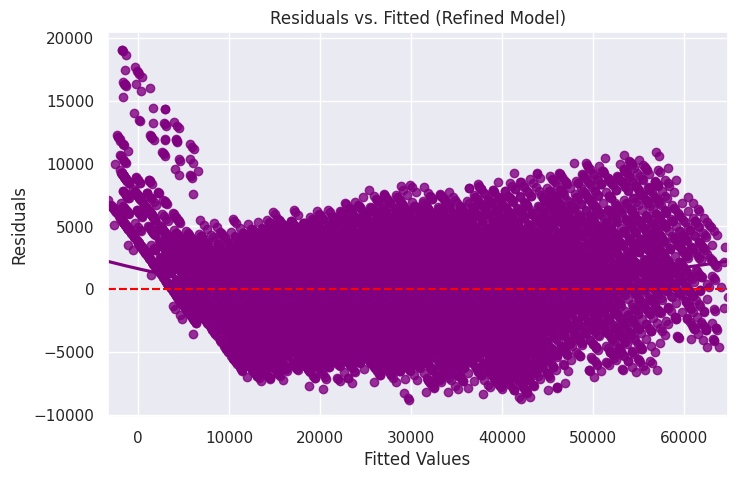

In [113]:
df_pred = pd.DataFrame()
df_pred["Actual Values"] = y_train
df_pred["Fitted Values"] = ols_model_6.fittedvalues   # refined model
df_pred["Residuals"] = ols_model_6.resid

print(df_pred.head())
print("\n")

plt.figure(figsize=(8,5))
sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted (Refined Model)")
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

**Observations:**

- The residuals are centred around zero and have no systematic curvature, which suggests no non-linearity.
- **Horizontal red line (Y=0)** shows No bias
- A few larger residuals appear at the extremes, but they do not dominate the distribution.


**Inference:**

- The plot indicates that the refined model accurately depicts the linear relationship between variables and insurance costs.
- **We see no pattern in the plot above. Hence, the assumptions of linearity and independence are satisfied.**


###**Test For Normality of Residuals**

* **Normality test is done:**
   * The error terms, or residuals, should follow a normal distribution.  If the error components are not normally distributed, the confidence interval for coefficient estimates may become overly large or narrow.  When a confidence interval becomes unstable, it makes it harder to estimate coefficients using least squares minimisation.  Non-normality indicates that a few unexpected data points must be thoroughly investigated in order to create a better model.

* **Normality check steps:**
   * The shape of the residuals histogram can provide a first understanding of normality.
   * It can also be verified using a Q-Q plot of residuals.  If the residuals have a normal distribution, they will result in a straight line plot, otherwise not.
   * The Shapiro-Wilk test is another method for determining normality.
     * Null hypothesis: The residuals are regularly distributed.
     * Alternative hypothesis: The residuals are not normally distributed.

* If assumption failed then we can apply transformations such as log, exponential, and arcsinh, etc., to our data.



**Normality of residuals plot**

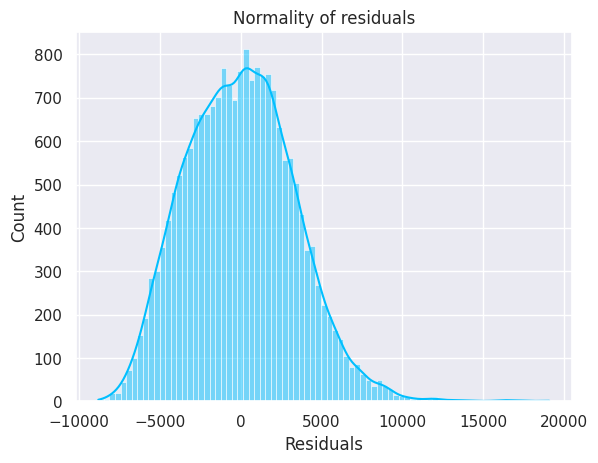

In [114]:
sns.histplot(data=df_pred, x="Residuals", kde=True,color = "deepskyblue")
plt.title("Normality of residuals")
plt.show()

**Observations:**
- The distribution of residuals is roughly symmetric and bell-shaped, with the bulk of observations near zero. but a slight positive skew is present and the right tail extends to ~ 19,000, while the left tail is short (~ -5,000) and contains very few points. This matches the skewness value of 0.367 reported in the model summary.

- Let's check the Q-Q plot.


---


 **Q-Q plot**

Q-Q Residual Plot:


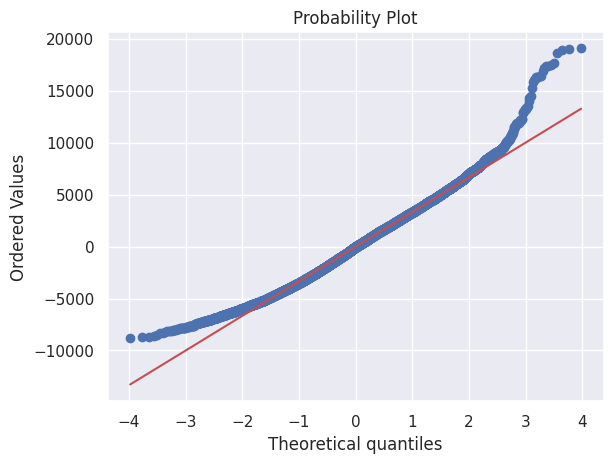

In [115]:
import pylab
import scipy.stats as stats

print("Q-Q Residual Plot:")
stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

**Observations:**

- The points generally follow the reference diagonal line, indicating that the residuals are approximately normally distributed. Minor skewness is visible at the extremes (both lower and upper tails), which is common with large sample sizes (n = 20,000).
- Let us check the results of the Shapiro-Wilk test.


---



**Shapiro-Wilk test**

- The Shapiro-Wilk test can also be used for checking the normality.
- The null and alternate hypotheses of the test are as follows:

  - Null hypothesis - Data is normally distributed.
  - Alternate hypothesis - Data is not normally distributed.

In [116]:
print("Shapiro-Wilk test for Normality of residuals:\n")
stats.shapiro(df_pred["Residuals"])

Shapiro-Wilk test for Normality of residuals:



ShapiroResult(statistic=np.float64(0.9895707193758183), pvalue=np.float64(2.3783139041869752e-35))

**Observations:**

- The test statistic is 0.9896 (near to 1) indicating that the residuals are actually quite close to a normal distribution.
- Since p-value < 0.05, around 2.38x10^-35,so we reject the null hypothesis. This conclude the residuals are not perfectly normal which rejects the null hypothesis of normality.
- In a sample of 20,000 observations, even slight deviations from perfect normalcy can lead to statistical significance.


**Overall Inference from Normality of residuals test:**

- Visual inspection (histogram and Q-Q plot) and the Shapiro-Wilk statistic depicted that the residuals are near to normal.
- Although theoretical standards recommend transformations to achieve normality of residuals, but we do not utilise them here because for large sample sizes like ours, perfect normalcy is not required to make accurate predictions, although it does alter the validity of p-values and confidence intervals. However, our primary goal is accurate insurance cost estimation. Therefore, mild non-normality does not affect model reliability. The model's prediction performance (R² = 0.945, RMSE ≈ 3351.5) remains reliable.







###**Test For Homoscedasticity**

**Homoscedascity:** If the variance of the residuals is symmetrically distributed throughout the regression line, the data is considered homoscedastic. This is ideal because it ensures that the standard errors of the coefficients are accurately estimated, making confidence intervals and p-values reliable.

**Heteroscedascity:** If the variance of the residuals across the regression line is unequal, the data is considered heteroscedastic. Presence of heteroscedascity violates the assumption of constant variance. While it does not bias the coefficient estimates or predictions, it does increase or decrease standard errors, leading to potentially incorrect inference (e.g., declaring a variable significant when it is not).

**Need for the test:**

* The presence of non-constant variance in the residuals causes heteroscedasticity.
* Non-constant variance occurs in the presence of outliers.

**checking for homoscedasticity:**

* The residual vs fitted values plot can be used to test for homoscedasticity.  Heteroscedasticity can result in non-symmetrical residual shapes, such as arrows.  The Goldfeld-Quandt test can also be utilised.  If the p-value exceeds 0.05, we can conclude that the residuals are homoscedastic.  Otherwise, they're heteroscedastic.
     * Null hypothesis: The residuals are homoscedastic (constant variance).
     * Alternative hypothesis: Residuals exhibit heteroscedasticity ( non-constant variance)

* If this assumption is not followed then heteroscedasticity can be reduced by incorporating more essential features or performing transformations.

In [117]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

print("Goldfeld-Quandt test for homoscedasticity:\n")
name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], X_train_6_const)
lzip(name, test)

Goldfeld-Quandt test for homoscedasticity:



[('F statistic', np.float64(0.9944083892896372)),
 ('p-value', np.float64(0.6103447563423754))]

**Observations:**

***Goldfeld-Quandt test***
-  We obtained F-statistic = 0.9944, p-value = 0.6103 from the test results.
- The p-value is greater than 0.05, so we cannot reject the null hypothesis of homoscedasticity. This means that the residuals have the constant variance over the range of fitted values.

***Residual vs. fitted plot***

- The previous section scatter plot shows residuals randomly distributed around zero, with no noticeable funnel shape or systematic increase/decrease in distribution, indicating constant variance.


**Conclusion:**

- The Goldfeld-Quandt test and visual inspection from residual-fitted plot demonstrate that the homoscedasticity assumption is satisfied. Thus, no transformation is required to account for heteroscedasticity.

- This suggests model's standard errors and inference (p-values, confidence intervals) are reliable.

- Since, our prime objective is to predict insurance cost, the model excels in prediction (R² = 0.945, RMSE ≈ 3351.5).




####**Overall Insights from Linear Regression Assumption Checks**

**Multicollinearity:** Perfect collinearity has been resolved; the residual high VIF for weight reflects natural correlations and has no effect on predictions.

**Linearity:** The residual vs. fitted plot demonstrates no systematic curvature, which **satisfies the linearity assumption**.

- The Durbin-Watson statistic is approximately 1.97 from the refined model OLS summary, showing **no significant autocorrelation**.

- **Normality of residuals:** The **Shapiro-Wilk test formally rejects normality (p < 0.05)**, but the large sample size and close alignment of the Q-Q plot indicate only mild deviation, which **does not compromise predictive performance**.

- The Goldfeld-Quandt test (p = 0.610) and residual plot **validate the assumption of homoscedasticity** (constant variance).

- Overall, the improved model fits the key assumptions required for reliable predictions. Minor violations (normality) are irrelevant to the fundamental purpose of accurate insurance cost assessment.

##**Final Baseline-Linear Regression Model**

- The final baseline linear regression model will be build using a 60-20-20 train-validation-test split, following the completion of assumption checks and feature refinement in the previous section in the refined baseline model.

- This final baseline model will be trained using the revised set of nine predictors found by backward elimination in refined baseline model, to ensure stability and interpretability.

- In order to compare it with more sophisticated machine learning models, this final linear regression model will be used. The major metric (RMSE) and auxiliary metrics (MAE, R-square, and MAPE) will used to assess model performance.

- To ensure consistency across comparisons and preserve the interpretability of coefficients, all models are trained using the original scaled data.




###**Final Dataset Preparation (Refined Features)**

**Methodology:**
From our fully preprocessed dataframe (df3), we will select only the 9 statistically significant predictors identified through VIF and p-value elimination in the refined baseline model section. The target variable insurance_cost will be retained.

**Why this step is necessary:**
Using only the refined features removes multicollinearity and irrelevant predictors, creating a clean, stable dataset. This ensures that the final baseline model and all advanced models will be evaluated on the same meaningful feature set.

In [118]:
# df3 is our fully preprocessed dataframe (after encoding, imputation, feature engineering)
# We keep only the 9 refined features + target

selected_features = [
    'years_of_insurance_with_us',
    'regular_checkup_last_year',
    'adventure_sports',
    'visited_doctor_last_1_year',
    'age',
    'weight',
    'covered_by_any_other_company',
    'weight_change_in_last_one_year',
    'years_since_last_admission'
]

df_final = df3[selected_features + ['insurance_cost']].copy()
X = df_final.drop('insurance_cost', axis=1)
y = df_final['insurance_cost']

###**Train / Validation / Test split (60:20:20)**





**Methodology:**
- The dataset is split into three mutually exclusive parts:

  - ***Training set (60%)*** - used to fit all models.

  - ***Validation set (20%)*** - used to compare model performance and tune hyperparameters.

  - ***Test set (20%)*** - kept completely unseen until the final model is selected.

- **Splitting the data into train, validation, and test sets (60:20:20 ratio):**

  - ***X_train_base (60%)*** - It is used to train the model.
  - ***X_val_base (20%)*** - It is used for model validation, hyperparameter tuning, and performance evaluation during development.
  - ***X_test_base (20%)*** - It is used for final, unbiased evaluation of the model after all tuning is complete.
  - ***y_train_base*** - Here the target values corresponding to X_train_base.
  - ***y_val_base*** - The target values for X_val_base.
  - ***y_test_base*** - Target values for X_test_base.
  - Here the data is first split into training (60%) and temporary (40%) sets. The temporary set is then equally divided into validation (20%) and test (20%) sets to maintain the required 60:20:20 ratio.

**Why this step is necessary:**
A separate validation set prevents overfitting during model selection and tuning. The test set provides an unbiased estimate of the final model's real-world performance. This split respects the golden rule of machine learning: ***test only once***.

In [119]:
X_train_base, X_temp_base, y_train_base, y_temp_base = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val_base, X_test_base, y_val_base, y_test_base = train_test_split(
    X_temp_base, y_temp_base, test_size=0.5, random_state=42
)

print(f"Train: {X_train_base.shape}, Val: {X_val_base.shape}, Test: {X_test_base.shape}")

Train: (15000, 9), Val: (5000, 9), Test: (5000, 9)


**Observations:**
- The dataset was successfully divided into training, validation, and test sets in a 60:20:20 ratio, yielding 15,000 rows for training and 5,000 rows each for validation and testing.
- Each subset has the same nine features, ensuring that model input is consistent at all stages.
- This split allows for effective model training, hyperparameter tuning, and unbiased final evaluation.


###**Feature Scaling (Standardization) for Final Baseline Model**

**Methodology:**
A StandardScaler is fitted only on the training set and then used to transform the validation and test sets. The scaler centers features to mean = 0 and scales to unit variance.  

**Why this step is necessary:**
Sklearn's Linear regression uses coefficient based optimisation. Thus, scaling is required for final baseline model. However, Tree-based models are scale-invariant i.e scaling does not change their predictions or splits. Therefore, we applying the same scaling to all models to keep the workflow consistent as it does not harm performance.


In [120]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_base)
X_val_scaled = scaler.transform(X_val_base)
X_test_scaled = scaler.transform(X_test_base)

# Convert back to DataFrame for convenience
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_base.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val_base.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_base.columns)

print("Scaled Training Data:")
print(X_train_scaled.head())

Scaled Training Data:
   years_of_insurance_with_us  regular_checkup_last_year  adventure_sports  \
0                   -0.033764                  -0.648650         -0.298077   
1                    0.349631                  -0.648650         -0.298077   
2                    0.733025                   0.182953         -0.298077   
3                    0.733025                   1.846158         -0.298077   
4                   -1.567344                  -0.648650         -0.298077   

   visited_doctor_last_1_year       age    weight  \
0                    1.697729  0.375186 -0.930063   
1                   -0.077891 -1.681528 -0.070465   
2                   -0.077891 -0.871307  0.036984   
3                   -0.077891  0.936108  0.144434   
4                   -0.965701 -1.182931 -2.004559   

   covered_by_any_other_company  weight_change_in_last_one_year  \
0                      1.530683                       -1.497451   
1                      1.530683                       -1

**Observations:**

- All the 9 features have been successfully scaled, with values standardized (mean ≈ 0, std ≈ 1) across all variables, ensuring consistency and improving model performance.

###**Building Final Baseline Model & Performance Evaluation**

In [121]:
lr_base = LinearRegression()
lr_base.fit(X_train_scaled, y_train_base)

print("\n=== Final Baseline Linear Regression (Training Set) ===\n")
lr_train_results = evaluate_regression(lr_base, X_train_scaled, y_train_base)
print(lr_train_results.to_string(index=False))

print("\n=== Final Baseline Linear Regression (Validation Set) ===")
lr_val_results = evaluate_regression(lr_base, X_val_scaled, y_val_base)
print(lr_val_results.to_string(index=False))


=== Final Baseline Linear Regression (Training Set) ===

       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
3347.506313 2700.838737   0.945361        0.945329 15.028213

=== Final Baseline Linear Regression (Validation Set) ===
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
3354.315955 2668.829456   0.944874        0.944774 15.189007


**Observations:**
- The model performs consistently on both the training and validation sets, with ***RMSE values of 3347.51 (training) and 3354.32 (validation)***. The R-squared values are likewise quite similar (***0.945 vs 0.945***), demonstrating that the model generalises well on validation data.

- The minimal difference between training and validation metrics indicates that the model is not overfitting. Overall, the baseline linear regression model has excellent predictive performance and stability.

- Therefore, the dataset and selected features are well-prepared for applying to advanced models.


#**MODEL BUILDING-ADVANCED MODEL**

For this insurance cost prediction problem, **5 advanced regression models are chosen: Decision Tree, Random Forest, Gradient Boosting, XGBoost, and AdaBoost.** These models are chosen because the target variable may be influenced by complex relationships and interaction effects between predictors such as age, weight, and medical history. While linear regression offers interpretability, tree-based approaches are more suited to capture such complexities.

These models are ideal for structured tabular data and can effectively handle both numerical and category variables. Ensemble methods like as Random Forest, Gradient Boosting, XGBoost, and AdaBoost are used to evaluate whether combining multiple learners improved prediction performance. This contributes to the business goal of providing accurate insurance cost predictions and enables robust model comparison and selection.

While the final baseline model provided interpretability, advanced models will be explored to capture complex non-linear relationships and improve predictive performance further.


##**Decision Tree Regressor**

**Methodology:**
The Decision Tree splits the data recursively based on features with the lowest mean squared error. Predictions are made based on the average value in each leaf node.

**Relevance:**
Captures non-linear interactions between the predictors & target variable, and gives an interpretable baseline for tree-based models.

---

**Fitting the model**

In [122]:
# ---------------------------------------------------
# Decision Tree Regressor
# ---------------------------------------------------
print("\n---Decision Tree Regressor (DTR)---")

# Initialize and train the Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train_base)


---Decision Tree Regressor (DTR)---


DecisionTreeRegressor(random_state=42)

**Observations:**
- We have successfully build the decision tree model.

---

**Decision Tree Performnace Evaluation**

In [123]:
# List to store validation performance of all models for comparison
advanced_results = []

# Evaluate model performance on training set (to check fitting)
print("\nDTR Training Set Performance:")
dt_train_results = evaluate_regression(dt_model, X_train_scaled, y_train_base)
print(dt_train_results.to_string(index=False))

# Evaluate model performance on validation set (used for model selection)
print("\nDTR Validation Set Performance:")
dt_val_results = evaluate_regression(dt_model, X_val_scaled, y_val_base)
print(dt_val_results.to_string(index=False))

# Store validation results for comparison across models
dt_val_summary = dt_val_results.copy()
dt_val_summary.insert(0, 'Model', 'Decision Tree')
advanced_results.append(dt_val_summary)


DTR Training Set Performance:
      RMSE      MAE  R-squared  Adj. R-squared  MAPE (%)
133.287234 6.416800   0.999913        0.999913  0.042278

DTR Validation Set Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
4212.695993 3258.253600   0.913050        0.912893 15.441546


**Observations:**
- The model performs exceptionally well on the training set **(R² ≈ 0.9999, RMSE = 133)**, showing near-perfect memorisation of the training data, **severe overfitting**.
- However, performance on the validation set is significantly lower **(R² = 0.913, RMSE ≈ 4213)**, indicating poor generalisation.
- The notable difference between training and validation performance plainly reflects ***overfitting***, a known ***drawback of decision trees when grown without constraints***.
- As a result, while the decision tree model captures complex patterns, but it ***lacks generalisability and reliable predictive performance on new data*** and may not be viable as a final model without further tuning.

#**Random Forest Regressor**

**Methodology:**
Random Forest builds multiple decision trees using bootstrap samples and averages their predictions to increase performance and reduce variance.

**Relevance:**
Reduces overfitting while properly handling feature interactions.


---

**Fitting the model**

In [124]:
# ---------------------------------------------------
# Random Forest Regressor
# ---------------------------------------------------
print("\n----Random Forest Regressor----")

# Initialize and train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train_base)




----Random Forest Regressor----


RandomForestRegressor(n_jobs=-1, random_state=42)

**Observations:**
- We have successfully build the random forest model with default parameters.


---

**Random Forest Performnace Evaluation**

In [125]:
# Training performance
print("\nRandom Forest Training Set Performance:")
rf_train_results = evaluate_regression(rf_model, X_train_scaled, y_train_base)
print(rf_train_results.to_string(index=False))

# Validation performance
print("\nRandom Forest Validation Set Performance:")
rf_val_results = evaluate_regression(rf_model, X_val_scaled, y_val_base)
print(rf_val_results.to_string(index=False))

# Store validation results
rf_val_summary = rf_val_results.copy()
rf_val_summary.insert(0, 'Model', 'Random Forest')
advanced_results.append(rf_val_summary)


Random Forest Training Set Performance:
       RMSE        MAE  R-squared  Adj. R-squared  MAPE (%)
1179.477492 924.992631   0.993217        0.993213  4.517198

Random Forest Validation Set Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
3083.159635 2455.617697   0.953426        0.953342 11.949105


**Observations:**
- The model performs well on the training set ***(R² = 0.993, RMSE ≈ 1179)***, demonstrating robust learning ability without extreme memorisation.
- The performance on the validation set is consistently strong (***R² = 0.953, RMSE ≈ 3083***), indicating robust generalisation to new data.
- The difference between training and validation performance is moderate, indicating ***controlled overfitting as compared to the Decision Tree model***.
- The validation set's relatively low RMSE and MAE suggest ***good prediction accuracy***, making Random Forest a reliable model for this situation.
- Overall, the model strikes an appropriate balance between bias and variance, giving it a great contender for additional tuning and final model selection.

##**Gradient Boosting Regressor**

**Methodology:**
Gradient Boosting builds trees sequentially, with each new tree correcting the errors of the previous model.

**Relevance:**
Increases prediction accuracy by focusing on residual errors.


---

**Fitting Gradient Boosting**

In [126]:
# ---------------------------------------------------
# Gradient Boosting Regressor
# ---------------------------------------------------
print("\n----Gradient Boosting Regressor ----")

# Initialize and train Gradient Boosting model
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train_base)



----Gradient Boosting Regressor ----


GradientBoostingRegressor(random_state=42)

**Observations:**
- We have successfully build the gradient boosting regressor model with default parameters.


---

**Gradient Boosting Regressor Performance Evaluation**

In [127]:
# Training performance
print("\nGradient Boosting Regressor Training Set Performance:")
gb_train_results = evaluate_regression(gb_model, X_train_scaled, y_train_base)
print(gb_train_results.to_string(index=False))

# Validation performance
print("\nGradient Boosting Regressor Validation Set Performance:")
gb_val_results = evaluate_regression(gb_model, X_val_scaled, y_val_base)
print(gb_val_results.to_string(index=False))

# Store validation results
gb_val_summary = gb_val_results.copy()
gb_val_summary.insert(0, 'Model', 'Gradient Boosting')
advanced_results.append(gb_val_summary)


Gradient Boosting Regressor Training Set Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
2940.551896 2365.906663   0.957839        0.957813 11.652507

Gradient Boosting Regressor Validation Set Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
2932.900850 2357.620479   0.957855        0.957779 11.720966


**Observations:**
- The model performs very consistently on ***training (RMSE = 2941) and validation (RMSE ≈ 2933)*** datasets.
- The nearly comparable **R² values (≈ 0.958)** indicate ***strong generalisation*** and ***minimal overfitting***.
- Error measures ***(RMSE, MAE, MAPE) are stable***, indicating that the model adequately captures underlying patterns without memorising data.
- Overall, Gradient Boosting has a great balance of bias and variance, making it a viable choice for further tuning.

##**XGBoost Regressor**

**Methodology:**
XGBoost is an optimised gradient boosting technique that incorporates regularisation and efficient computation.

**Relevance:**
Provides excellent performance and effectively handles complex patterns.


---


**Fitting XGBoost Model**

In [128]:
# ---------------------------------------------------
# XGBoost Regressor
# ---------------------------------------------------
print("\n=== XGBoost Regressor ===")

# Initialize and train XGBoost model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_train_base)


=== XGBoost Regressor ===


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

**Observations:**
- We have successfully build the XGboost regressor model with default parameters.

---

**XGboost Regressor Performance Evaluations**

In [129]:
# Training performance
print("\nXGBoost Training Set Performance:")
xgb_train_results = evaluate_regression(xgb_model, X_train_scaled, y_train_base)
print(xgb_train_results.to_string(index=False))

# Validation performance
print("\nXGBoost Validation Set Performance:")
xgb_val_results = evaluate_regression(xgb_model, X_val_scaled, y_val_base)
print(xgb_val_results.to_string(index=False))

# Store validation results
xgb_val_summary = xgb_val_results.copy()
xgb_val_summary.insert(0, 'Model', 'XGBoost')
advanced_results.append(xgb_val_summary)


XGBoost Training Set Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
2689.181195 2144.352051   0.964739        0.964718 10.502566

XGBoost Validation Set Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
2927.765701 2342.543701   0.958003        0.957927 11.499298


**Observations:**
- This model achieves better training performance ***(RMSE ≈ 2689, R² ≈ 0.965)*** compared to Gradient Boosting, indicating stronger learning capabilities.
- On the validation set, performance is still strong ***(RMSE = 2928, R² ≈ 0.958)***, indicating ***robust generalisation***.
- A small rise in error from training to validation indicates ***mild overfitting*** within acceptable boundaries.
- The relatively lower validation RMSE and MAE among models suggest ***high prediction accuracy***, making XGBoost a strong contender for tuning and final selection.

##**AdaBoost Regressor**


**Methodology:**
AdaBoost trains sequential weak learners, emphasising weight to mispredicted observations.

**Relevance:**
AdaBoost focuses on difficult cases and offers an alternative boosting approach.

----

**Fitting AdaBoost Model**

In [130]:
# ---------------------------------------------------
# AdaBoost Regressor
# ---------------------------------------------------
print("\n---- AdaBoost Regressor ----")

# Initialize and train AdaBoost model
ada_model = AdaBoostRegressor(n_estimators=100, random_state=42)
ada_model.fit(X_train_scaled, y_train_base)


---- AdaBoost Regressor ----


AdaBoostRegressor(n_estimators=100, random_state=42)

**Observations:**
- We have successfully build the Adaboost regressor model with default parameters.

---

**Adaboost Regressor Performance Evaluations**

In [131]:
# Training performance
print("\nAdaboost Training Set Performance:")
ada_train_results = evaluate_regression(ada_model, X_train_scaled, y_train_base)
print(ada_train_results.to_string(index=False))

# Validation performance
print("\nAdaboost Validation Set Performance:")
ada_val_results = evaluate_regression(ada_model, X_val_scaled, y_val_base)
print(ada_val_results.to_string(index=False))

# Store validation results
ada_val_summary = ada_val_results.copy()
ada_val_summary.insert(0, 'Model', 'AdaBoost')
advanced_results.append(ada_val_summary)


Adaboost Training Set Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
3274.235103 2712.914785   0.947727        0.947696 15.753448

Adaboost Validation Set Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
3256.976464 2696.569060   0.948027        0.947933 16.011246


**Observations:**
- The model performs moderately on the training ***(RMSE = 3274)*** and validation ***(RMSE ≈ 3257)*** datasets.
- The close alignment of training and validation metrics suggests little variation and minimal overfitting, but it also implies ***poor learning ability***.
- AdaBoost produces ***higher error values*** than other ensemble algorithms, suggesting ***weaker predictive power***.
- Even though, the model is reliable, but it does not capture complex patterns as well as Gradient Boosting or XGBoost.

##**Performance comparison of all advance models**

We will compare all model's validation set performance results by analysing the prime metric RMSE.

In [132]:
# Combine all validation results into a single DataFrame
all_adv_results = pd.concat(advanced_results, ignore_index=True)

# Display comparison of all models based on validation performance
print("\n--------- Advanced Models Comparison (Validation Set) -----------")
print(all_adv_results.sort_values(by='RMSE').to_string(index=False))


--------- Advanced Models Comparison (Validation Set) -----------
            Model        RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
          XGBoost 2927.765701 2342.543701   0.958003        0.957927 11.499298
Gradient Boosting 2932.900850 2357.620479   0.957855        0.957779 11.720966
    Random Forest 3083.159635 2455.617697   0.953426        0.953342 11.949105
         AdaBoost 3256.976464 2696.569060   0.948027        0.947933 16.011246
    Decision Tree 4212.695993 3258.253600   0.913050        0.912893 15.441546


**Overall Insights from Advanced Model Performances:**

- Validation RMSE reveals that ***XGBoost (≈ 2928)*** and ***Gradient Boosting (≈ 2933)*** outperform ***Random Forest (≈ 3083)***.
- These models maintain ***high R² values (~0.95-0.96)***, indicating great predictive power and good generalisation.
- ***AdaBoost*** performs ***moderately*** but with higher error, whereas ***Decision Tree*** has the ***lowest validation performance*** due to overfitting.
- Therefore, ***XGBoost, Gradient Boosting, and Random Forest were chosen for hyperparameter tuning*** due to their superior validation performance and their strong ability to capture complex patterns in the data, making them well-suited for accurate insurance cost prediction.

#**ADVANCED MODEL HYPERPARAMETER TUNING**

After comparing the advanced models with the default hyperparameters, the top 3 models (***XGBoost, Gradient Boosting, and Random Forest***) were chosen for further optimisation based on validation performance (RMSE being the primary metric). Training performance was also assessed to guarantee that the models did not suffer from excessive overfitting.


**Hyperparameter Tuning Strategy**:
Hyperparameter tuning is used to find the best parameter combinations that optimise predictive accuracy, generalisation, and model complexity. This stage verifies that the selected models performs best for the given dataset.


**GridSearchCV** will be used for hyperparameter tuning to systematically evaluate all parameter combinations and ensure optimal model performance. This approach provides more reliable and reproducible results for the given data size.

While RandomizedSearchCV is widely used in large-scale industrial settings for efficiency, GridSearchCV was chosen for this project because to its manageable parameter space and the need for a thorough and interpretable evaluation.



##**Random Forest Regressor Model Tuning**

Random Forest Regressor model is selected for tuning due to its strong validation performance and good generalisation. We will be tuning parameters such as number of trees, minimum samples required for splitting and tree depth, as these parameters can reduce validation error. Thus, it can further improve model's stability and prediction accuracy.




In [133]:
# ---------------------------------------------------
# Hyperparameter Tuning - Random Forest Regressor
# ---------------------------------------------------
print("\n---Hyperparameter Tuning: Random Forest---")

# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Define parameter grid (values to test)
rf_param_grid = {
    'n_estimators': [100, 200],          # number of trees
    'max_depth': [None, 10],             # tree depth control
    'min_samples_split': [2, 5]          # minimum samples required to split
}

# Initialize base Random Forest model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Perform Grid Search with 3-fold cross-validation
rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring='neg_root_mean_squared_error',  # optimize RMSE
    cv=3,
    n_jobs=-1
)

# Fit model on training data
rf_grid.fit(X_train_scaled, y_train_base)

# Extract best model after tuning
best_rf = rf_grid.best_estimator_

# Display best parameters
print("Best Parameters:", rf_grid.best_params_)

# Evaluate tuned model on training set (check fit)
print("\nRF Tuned -Train Performance:")
rf_train_tuned = evaluate_regression(best_rf, X_train_scaled, y_train_base)
print(rf_train_tuned.to_string(index=False))

# Evaluate tuned model on validation set (model selection metric)
print("\nRF Tuned-Validation Performance:")
rf_val_tuned = evaluate_regression(best_rf, X_val_scaled, y_val_base)
print(rf_val_tuned.to_string(index=False))


---Hyperparameter Tuning: Random Forest---
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

RF Tuned -Train Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
2549.307751 2030.964965   0.968312        0.968293  9.915369

RF Tuned-Validation Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
2965.314706 2368.909351   0.956918        0.956841 11.529327


**Observations:**

- The best parameters for random forest selected by grid search are **max depth, min samples split and n estimators**.
- The tuned random forest model ***outperforms*** the untuned version in terms of generalisation and has a ***reduced RMSE*** on the validation set (~***2965***).
- There is a moderate gap between training (***RMSE = 2549***) and validation performance, showing ***controlled overfitting*** after tuning.
- The model's ***high R² (~0.957)*** and ***low MAPE (~11.53%)*** demonstrate its ability to accurately identify underlying trends effectively and provides reliable performance.


##**Gradient Boosting Regressor Model Tuning**

Gradient Boosting Regressor has shown highly consistent train and validation performance, suggesting strong generalisation. Since the model is sensitive to parameters such as learning rate, number of estimators, and tree depth, tuning these parameters can enhance predictive power while controlling overfitting.


In [134]:
# ---------------------------------------------------
# Hyperparameter Tuning - Gradient Boosting Regressor
# ---------------------------------------------------
print("\n-----Hyperparameter Tuning: Gradient Boosting------")

# Define parameter grid
gb_param_grid = {
    'n_estimators': [100, 200],          # number of boosting stages
    'learning_rate': [0.05, 0.1],        # contribution of each tree
    'max_depth': [3, 5]                  # depth of individual trees
}

# Initialize model
gb_base = GradientBoostingRegressor(random_state=42)

# Grid Search
gb_grid = GridSearchCV(
    estimator=gb_base,
    param_grid=gb_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1
)

# Fit on training data
gb_grid.fit(X_train_scaled, y_train_base)

# Best model
best_gb = gb_grid.best_estimator_

print("Best Parameters:", gb_grid.best_params_)

# Training performance
print("\nGB Tuned - Train Performance:")
gb_train_tuned = evaluate_regression(best_gb, X_train_scaled, y_train_base)
print(gb_train_tuned.to_string(index=False))

# Validation performance
print("\nGB Tuned - Validation Performance:")
gb_val_tuned = evaluate_regression(best_gb, X_val_scaled, y_val_base)
print(gb_val_tuned.to_string(index=False))


-----Hyperparameter Tuning: Gradient Boosting------
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}

GB Tuned - Train Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
2882.652660 2314.135623   0.959483        0.959458 11.473817

GB Tuned - Validation Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
2916.241603 2344.545926   0.958332        0.958257 11.790326


**Observations:**

- The best parameters for gradient boosting selected by grid search are **'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100** .
- The tuned gradient boosting model's ***performance is very consistent*** across ***training (RMSE = 2883)*** and ***validation (RMSE ≈ 2916)***, showing ***high generalisation***.
- The slight discrepancy across all metrics indicates that tuning has helped establish a ***well-balanced bias-variance trade-off***.
- This model's high ***R² (~0.958***) and stable error metrics make it robust and reliable for insurance cost prediction tasks.




##**XGBoost Regressor Model Tuning**

XGBoost Regressor has achieved the best validation performance among all models, making it a good choice for final model selection. As its performance is strongly influenced by parameters such as learning rate, number of estimators, maximum depth, and subsampling, tuning is necessary to optimise predictive accuracy and ensure model generalisation.



In [135]:

# Hyperparameter Tuning - XGBoost Regressor

print("\n------Hyperparameter Tuning: XGBoost------")

# Define parameter grid
xgb_param_grid = {
    'n_estimators': [100, 200],          # number of trees
    'learning_rate': [0.05, 0.1],        # step size
    'max_depth': [3, 5]                  # depth of trees
}

# Initialize model
xgb_base = XGBRegressor(
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

# Grid Search
xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1
)

# Fit model
xgb_grid.fit(X_train_scaled, y_train_base)

# Best model
best_xgb = xgb_grid.best_estimator_

print("Best Parameters:", xgb_grid.best_params_)

# Training performance
print("\nXGB - Train Performance:")
xgb_train_tuned = evaluate_regression(best_xgb, X_train_scaled, y_train_base)
print(xgb_train_tuned.to_string(index=False))

# Validation performance
print("\nXGB - Validation Performance:")
xgb_val_tuned = evaluate_regression(best_xgb, X_val_scaled, y_val_base)
print(xgb_val_tuned.to_string(index=False))


------Hyperparameter Tuning: XGBoost------
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}

XGB - Train Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
2810.052846 2250.689453   0.961498        0.961475 11.026328

XGB - Validation Performance:
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
2918.313211 2341.372070   0.958273        0.958198 11.541804


**Observations:**

- The best parameters for XGboosting are '**learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200**

- The tuned XGBoost model yields ***high prediction accuracy***, with a validation RMSE of ~2918, comparable to Gradient Boosting.
- The training-validation gap is relatively small, indicating strong generalisation and ***minimal overfitting***.
- The slightly lower MAE and MAPE compared to other models demonstrate the ability to offer more ***precise predictions*** on average.



#**MODEL PERFORMANCE COMPARISON & FINAL MODEL SELECTION**

This step is performed to assess the predictive performance of all models by comparing the train and validation results across all the key metrics (RMSE) as well as supporting metrics (MAE, R-squared, Adjusted R-squared, MAPE). While RMSE is used as the primary criterion for model comparison, the final model is selected based on a balanced evaluation of all metrics to ensure both accuracy and generalisability.



##**Model Comparison**

In [136]:
# ==============================================================================
# COMPARISON TABLES FOR ALL MODELS
# This code section creates:
# - create separate independent copy of each model train results
# as inserting 'Model' column would change our original results
# - Training performance comparison table
# - Validation performance comparison table
# Each table includes all evaluation metrics which we chose during the
# baseline model
# ==============================================================================

import pandas as pd

# --------------------------------------------------------------
# Create an empty list to store training results for all models
# --------------------------------------------------------------
train_results_all = []

# ---------------------------------------------------------
# Add baseline linear regression training results
# ---------------------------------------------------------
lr_train_summary = lr_train_results.copy()                       # copy baseline training metrics
lr_train_summary.insert(0, 'Model', 'Linear Regression (Baseline)')  # add model name column
train_results_all.append(lr_train_summary)                      # store in list

# ---------------------------------------------------------
# Add Decision Tree training results
# ---------------------------------------------------------
dt_train_summary = dt_train_results.copy()
dt_train_summary.insert(0, 'Model', 'Decision Tree')
train_results_all.append(dt_train_summary)

# ---------------------------------------------------------
# Add Random Forest training results
# ---------------------------------------------------------
rf_train_summary = rf_train_results.copy()
rf_train_summary.insert(0, 'Model', 'Random Forest')
train_results_all.append(rf_train_summary)

# ---------------------------------------------------------
# Add Gradient Boosting training results
# ---------------------------------------------------------
gb_train_summary = gb_train_results.copy()
gb_train_summary.insert(0, 'Model', 'Gradient Boosting')
train_results_all.append(gb_train_summary)

# ---------------------------------------------------------
# Add XGBoost training results
# ---------------------------------------------------------
xgb_train_summary = xgb_train_results.copy()
xgb_train_summary.insert(0, 'Model', 'XGBoost')
train_results_all.append(xgb_train_summary)

# ---------------------------------------------------------
# Add AdaBoost training results
# ---------------------------------------------------------
ada_train_summary = ada_train_results.copy()
ada_train_summary.insert(0, 'Model', 'AdaBoost')
train_results_all.append(ada_train_summary)

# ---------------------------------------------------------
# Add tuned Random Forest training results
# ---------------------------------------------------------
rf_tuned_train_summary = rf_train_tuned.copy()
rf_tuned_train_summary.insert(0, 'Model', 'Random Forest (Tuned)')
train_results_all.append(rf_tuned_train_summary)

# ---------------------------------------------------------
# Add tuned Gradient Boosting training results
# ---------------------------------------------------------
gb_tuned_train_summary = gb_train_tuned.copy()
gb_tuned_train_summary.insert(0, 'Model', 'Gradient Boosting (Tuned)')
train_results_all.append(gb_tuned_train_summary)

# ---------------------------------------------------------
# Add tuned XGBoost training results
# ---------------------------------------------------------
xgb_tuned_train_summary = xgb_train_tuned.copy()
xgb_tuned_train_summary.insert(0, 'Model', 'XGBoost (Tuned)')
train_results_all.append(xgb_tuned_train_summary)

# ---------------------------------------------------------
# Combine all training results into one DataFrame
# ---------------------------------------------------------
all_models_train_comp = pd.concat(train_results_all, ignore_index=True)

# ---------------------------------------------------------
# Sort training table by RMSE
# RMSE is the primary metric, but all metrics are retained
# ---------------------------------------------------------
all_models_train_comp = all_models_train_comp.sort_values(by='RMSE').reset_index(drop=True)

# ---------------------------------------------------------
# Display training comparison table
# This table is mainly used to assess overfitting
# ---------------------------------------------------------
print("\n==================Training Performance Comparison of All Models===================")
print(all_models_train_comp.to_string(index=False))


# ===================================================================
# VALIDATION PERFORMANCE COMPARISON TABLE
# - create separate independent copy of each model validation results
# as inserting 'Model' column would change our original results
# This is the main table used for model comparison and
# final model selection during development
# ====================================================================

# ---------------------------------------------------------
# Create an empty list to store validation results
# for all models
# ---------------------------------------------------------
val_results_all = []

# ---------------------------------------------------------
# Add baseline linear regression validation results
# ---------------------------------------------------------
lr_val_summary = lr_val_results.copy()
lr_val_summary.insert(0, 'Model', 'Linear Regression (Baseline)')
val_results_all.append(lr_val_summary)

# ---------------------------------------------------------
# Add Decision Tree validation results
# ---------------------------------------------------------
dt_val_summary = dt_val_results.copy()
dt_val_summary.insert(0, 'Model', 'Decision Tree')
val_results_all.append(dt_val_summary)

# ---------------------------------------------------------
# Add Random Forest validation results
# ---------------------------------------------------------
rf_val_summary = rf_val_results.copy()
rf_val_summary.insert(0, 'Model', 'Random Forest')
val_results_all.append(rf_val_summary)

# ---------------------------------------------------------
# Add Gradient Boosting validation results
# ---------------------------------------------------------
gb_val_summary = gb_val_results.copy()
gb_val_summary.insert(0, 'Model', 'Gradient Boosting')
val_results_all.append(gb_val_summary)

# ---------------------------------------------------------
# Add XGBoost validation results
# ---------------------------------------------------------
xgb_val_summary = xgb_val_results.copy()
xgb_val_summary.insert(0, 'Model', 'XGBoost')
val_results_all.append(xgb_val_summary)

# ---------------------------------------------------------
# Add AdaBoost validation results
# ---------------------------------------------------------
ada_val_summary = ada_val_results.copy()
ada_val_summary.insert(0, 'Model', 'AdaBoost')
val_results_all.append(ada_val_summary)

# ---------------------------------------------------------
# Add tuned Random Forest validation results
# ---------------------------------------------------------
rf_tuned_val_summary = rf_val_tuned.copy()
rf_tuned_val_summary.insert(0, 'Model', 'Random Forest (Tuned)')
val_results_all.append(rf_tuned_val_summary)

# ---------------------------------------------------------
# Add tuned Gradient Boosting validation results
# ---------------------------------------------------------
gb_tuned_val_summary = gb_val_tuned.copy()
gb_tuned_val_summary.insert(0, 'Model', 'Gradient Boosting (Tuned)')
val_results_all.append(gb_tuned_val_summary)

# ---------------------------------------------------------
# Add tuned XGBoost validation results
# ---------------------------------------------------------
xgb_tuned_val_summary = xgb_val_tuned.copy()
xgb_tuned_val_summary.insert(0, 'Model', 'XGBoost (Tuned)')
val_results_all.append(xgb_tuned_val_summary)

# ---------------------------------------------------------
# Combine all validation results into one DataFrame
# ---------------------------------------------------------
all_models_val_comp = pd.concat(val_results_all, ignore_index=True)

# ---------------------------------------------------------
# Sort validation table by RMSE
# RMSE remains the primary comparison metric
# but all supporting metrics are retained for final judgement
# ---------------------------------------------------------
all_models_val_comp = all_models_val_comp.sort_values(by='RMSE').reset_index(drop=True)

# ---------------------------------------------------------
# Display validation comparison table
# This is the main comparison table for selecting the best model
# ---------------------------------------------------------
print("\n\n==================Validation Performance Comparison of All Models===================")
print(all_models_val_comp.to_string(index=False))


==================Training Performance Comparison of All Models===================
                       Model        RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
               Decision Tree  133.287234    6.416800   0.999913        0.999913  0.042278
               Random Forest 1179.477492  924.992631   0.993217        0.993213  4.517198
       Random Forest (Tuned) 2549.307751 2030.964965   0.968312        0.968293  9.915369
                     XGBoost 2689.181195 2144.352051   0.964739        0.964718 10.502566
             XGBoost (Tuned) 2810.052846 2250.689453   0.961498        0.961475 11.026328
   Gradient Boosting (Tuned) 2882.652660 2314.135623   0.959483        0.959458 11.473817
           Gradient Boosting 2940.551896 2365.906663   0.957839        0.957813 11.652507
                    AdaBoost 3274.235103 2712.914785   0.947727        0.947696 15.753448
Linear Regression (Baseline) 3347.506313 2700.838737   0.945361        0.945329 15.028213


==============

**Overall Comparison Insights:**
- The comparison results show that ensemble-based models frequently outperform the baseline linear regression model, emphasising the presence of nonlinear relationships in the data.
- Boosting techniques outperform all other models in terms of predictive performance, with extremely close RMSE values and consistently strong supporting metrics.
- The minor difference in training and validation performance for these models indicates high generalisation ability.



##**Final Model Selection**

- Based on the validation performance, ***Gradient Boosting (Tuned) is chosen as the final model because it has the lowest RMSE among all the models. It also performs well across other important metrics like MAE, R-squared, and MAPE.***

- Moreover, the model shows only a small difference between training and validation performance, which suggests good generalization and reduced overfitting. While XGBoost (Tuned) has similar performance, Gradient Boosting is preferred for its slightly better RMSE and stable results across all evaluation metrics.

- Therefore, Gradient Boosting (Tuned) ***offers the best mix of accuracy and stability*** for this problem statement.







#**Final Model Evaluation on Test Set**

- After choosing the best-performing model based on the performance on validation set, the final model is tested on an unseen test set to get an unbiased estimate of how well the model predicts. The evaluation is done using the main metric (RMSE) and other supporting metrics, like MAE, R-squared, Adjusted R-squared, and MAPE. This step makes sure that the model generalises well to new, unseen data and can be used for real world application.




In [137]:
# FINAL MODEL EVALUATION ON TEST SET
# Evaluating the selected best model (Gradient Boosting Tuned)


# Print clear heading with model name
print("\n--------Final Test Set Performance on Best Model (Gradient Boosting - Tuned)------")

# ---------------------------------------------------------
# Evaluate the final selected model on unseen test data
# best_gb - trained tuned Gradient Boosting model
# X_test_scaled - test features
# y_test_base - actual target values
# ---------------------------------------------------------
final_test_results = evaluate_regression(best_gb, X_test_scaled, y_test_base)


# Display all evaluation metrics

print(final_test_results.to_string(index=False))


--------Final Test Set Performance on Best Model (Gradient Boosting - Tuned)------
       RMSE         MAE  R-squared  Adj. R-squared  MAPE (%)
2977.721725 2384.647836   0.957039        0.956961 11.818321


**Observations:**

- The final tuned Gradient Boosting model ***performs well on the unseen test set***, with an **RMSE of roughly 2978 and MAE of around 2385**, indicating accurate cost predictions.
- The model explains a ***significant proportion of the variance in insurance costs***, as indicated by the ***high R-squared value (~0.957)***.
- The model's ***strong generalisation*** and l***ack of noticeable overfitting*** are verified by the close alignment between test and validation results, making it reliable for real-world applications.




##**Final Model Predictions (Test Set)**

To assess the final model's practical applicability, predictions will be made on an unseen test dataset. A sample comparison of actual and expected insurance costs is shown below.

If the predicted values are relatively close to the actual values, with moderate prediction errors. Then the model generalises effectively to new data and can produce accurate predictions for insurance cost prediction.

In [138]:

# Final Model Predictions on Test Set


# Predict using the final tuned model
y_test_pred = best_gb.predict(X_test_scaled)

# Create comparison DataFrame
prediction_df = pd.DataFrame({
    'Actual': y_test_base.values,
    'Predicted': y_test_pred
})

# Round predicted values for better readability
prediction_df['Predicted'] = prediction_df['Predicted'].round(2)

# Calculate prediction error
prediction_df['Error'] = prediction_df['Actual'] - prediction_df['Predicted']

# Display sample results
print("\n=== Sample Predictions (Actual vs Predicted) ===")
print(prediction_df.head())


=== Sample Predictions (Actual vs Predicted) ===
   Actual    Predicted        Error
0   38254 38902.270000  -648.270000
1    6170  6444.740000  -274.740000
2   17276 21029.500000 -3753.500000
3   18510 16941.750000  1568.250000
4   33318 33661.690000  -343.690000


**Observations:**

- The prediction values are shown are generally close to actual insurance costs, demonstrating that the model catches the overall trend well.
- Most observations have relatively small prediction errors (e.g., ±300-600), indicating good accuracy in typical scenarios.
- Some instances (e.g., ~3750) show larger errors, indicating that the model may struggle with specific circumstances, presumably due to complicated or extreme feature combinations.
- Both overestimation and underestimation are observed, but there is no consistent bias, indicating that the model is well balanced.
- Overall, the model has high prediction capabilities and acceptable error margins for real-world applications.

##**Feature Importance of Final Model**

Since Gradient Boosting is an ensemble of decision trees, feature importance can be derived based on the contribution of each feature in reducing prediction error across all trees.
The feature importance analysis highlights that a few key variables have a significant impact on predicting insurance costs, while others contribute relatively less. This aligns with earlier findings from EDA and modelling, which indicated that major factors such as health-related attributes and historical variables play a crucial role in determining insurance cost.


-----Feature Importance of Final Model (Gradient Boosting Tuned)------
                       Feature  Importance
                        weight    0.991079
    years_since_last_admission    0.002915
  covered_by_any_other_company    0.002342
     regular_checkup_last_year    0.001896
    years_of_insurance_with_us    0.000632
                           age    0.000490
weight_change_in_last_one_year    0.000455
    visited_doctor_last_1_year    0.000155
              adventure_sports    0.000036


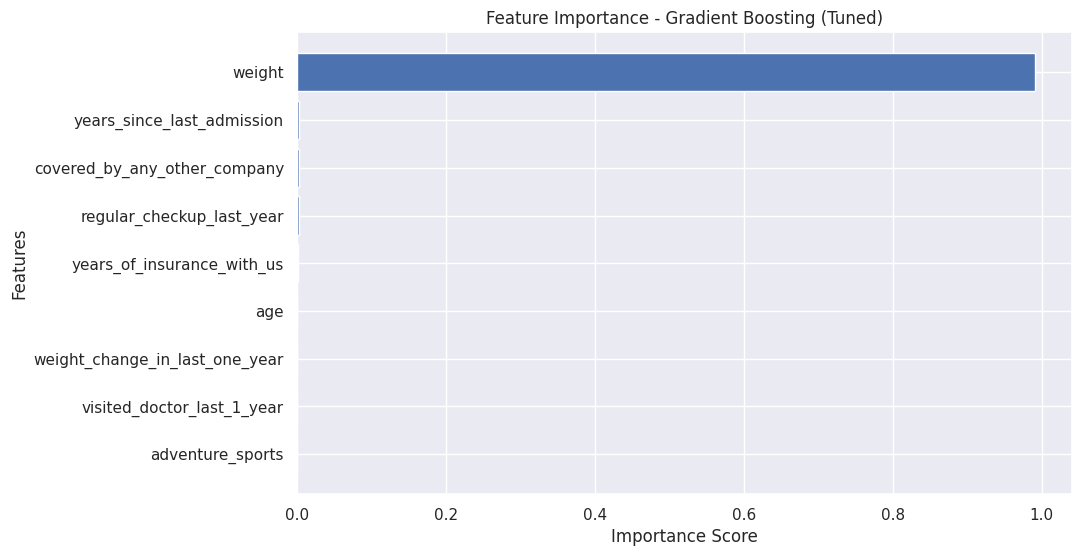

In [139]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance scores from final selected model
gb_feature_importance = best_gb.feature_importances_

# Create DataFrame with final feature names and importance scores
gb_feat_imp_df = pd.DataFrame({
    'Feature': X_train_base.columns,
    'Importance': gb_feature_importance
})

# Sort features by importance in descending order
gb_feat_imp_df = gb_feat_imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display feature importance table
print("\n-----Feature Importance of Final Model (Gradient Boosting Tuned)------")
print(gb_feat_imp_df.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(gb_feat_imp_df['Feature'], gb_feat_imp_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - Gradient Boosting (Tuned)")
plt.show()

**Observations:**

- The feature importance analysis demonstrates that ***weight is the leading predictor***, accounting for more than 99% of the model's decision-making, demonstrating that an individual's weight has a significant influence on insurance costs in this dataset.
- The minimal contributions of other factors, such as ***years since last admission, coverage by another company, and regular health checkups, indicate that they have a secondary role in influencing cost***.
- The ***remaining factors have an extremely low relevance***, indicating that their impact on prediction is small when compared to weight.
- This ***result is consistent with earlier modelling insights***, where weight identified as a key driver. However, the high dominance of a single feature suggests that the ***model's predictions are heavily influenced by weight***, which, while improving accuracy, may reduce robustness if this feature varies significantly across different scenarios.


#**Actionable Insights & Business Recommendations**


Based on the our previous analysis and the final selected model, the following insights & recommendations directly support the business objective of accurately estimating insurance cost and optimising risk-based pricing based on health and behavioural factors.



**1. Weight is the Main Factor in Insurance Cost**

***Insight:***
- Feature importance analysis shows that weight is the most important factor when predicting insurance cost.  

***Recommendation:***
- Since weight is closely linked to health risk, it should be included in pricing strategies. Insurance providers can encourage healthier lifestyles by offering incentives, like lower premiums for those who maintain a healthy weight. This would help reduce long-term risk.

**2. Preventative Healthcare Helps Lower Costs**

***Insight:***
- Regular checkups and preventive health behaviors lead to lower predicted insurance costs.  

***Recommendation:***
- Promoting preventive care can help lower claims and overall risk. Insurance companies can create policies that reward people who actively manage their health, which would improve customer outcomes and cut costs.

**3. Medical History Shows Risk Exposure**

***Insight:***
- Factors related to past hospital visits indicate that recent medical events greatly affect insurance costs.  

***Recommendation:***
- Including medical history in pricing models allows for more accurate risk-based pricing, ensuring that premiums match the true risk profile of individuals.

**4. Customer Behavior and Lifestyle Impact Risk**

***Insight:***
- Health and lifestyle factors together influence predicted insurance costs, highlighting the importance of individual behavior in assessing risk.  

***Recommendation:***
- Insurance companies should consider behavioral factors in underwriting decisions and promote healthier habits through specific programs, which could lower the chances of high-cost claims.

**5. Model Supports Data-Driven Pricing Decisions**

***Insight:***
- The final model provides reliable predictions of insurance costs based on health and lifestyle data.  

***Recommendation:***
- This model can serve as a decision-making tool to optimize premium pricing, enhance underwriting accuracy, and categorize customers based on risk levels.

**6. Monitor Model Dependence for Better Decision-Making**

***Insight:***
- The model depends heavily on weight as the primary predictor.  

***Recommendation:***
- While this boosts prediction accuracy, insurers should track model performance to ensure reliability across different customer groups and avoid relying too much on a single factor.

**7. Continuous Model Monitoring is Crucial for Long-Term Use**

***Insight:***
- Changes in customer health patterns and external factors can influence model performance over time.  

***Recommendation:***
- Regular retraining and validation of the model will ensure that it continues to deliver accurate and trustworthy cost predictions in a dynamic business environment.

**8. Model Predictions Demonstrate Practical Applicability**

***Insight:***

- The comparison between actual and predicted values on the test set shows that the model produces estimates that are generally close to real insurance costs, with only moderate deviations in some cases.

***Recommendation:***

- This suggests that the model is suitable for real-world deployment in insurance pricing and underwriting. It can be effectively used to support decision-making and enhance pricing accuracy, while periodic monitoring can ensure consistent performance over time.

#**GENERATIVE AI - RISK ASSESMENT & COMMUNICATION**

**System Architecture & GenAI Pipeline:**

1. ***Contextual Prompt Engineering:*** Pack the calculated insurance premium, baseline metrics, and user habits into a structured prompt context.
2. ***AI Risk Assessment Narrative:*** Run the prompt through the LLM to generate a natural language explanation of why the user's cost is high or low (e.g., *"High cost due to smoking status combined with low daily steps"*).
3. ***Automated Client Communications:*** Instruct the LLM to synthesize the data into a personalized, warm email draft detailing the quote and offering actionable health tips.



-------------------------------------------------------------------------

##**STEP 1: Installing the Gateway Libraries**



Before interacting with a Large Language Model or building user interfaces, Google Colab needs to download a few specialized packages. We will download langchain (to connect components), langchain-google-genai (our bridge to Gemini), and gradio (to render our interactive UI dashboard).

-------------------------------------------------------------------------

In [4]:

# ENVIRONMENT SETUP & PACKAGE DEPENDENCIES
# We use the '!' prefix to instruct Colab to run this command in the terminal background, Google Colab cells are set up to run Python code by default,
# as Google collab do not understand terminal commands.
# The '-q' flag means 'quiet mode', to hide all those useless download progress bars and text logs on screen, keeps notebook clean
#langchain: The core framework that allows us to chain prompts together, manage memory, and structure your AI workflow.
#langchain-community: A companion library containing third-party integrations (like community-contributed tools, databases, and loaders).
#langchain-google-genai: The official bridge that connects LangChain to Google's Gemini models so we can use Google's AI.
#gradio: A fast web-development library used to instantly build a clean,
#interactive user interface (buttons, input boxes, and text outputs)right inside your Colab notebook.

print("Fetching and installing core framework libraries...")

!pip install -q langchain langchain-community langchain-google-genai gradio

print("Installation complete! System is ready to import modules.")


Fetching and installing core framework libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
Installation complete! System is ready to import modules.


##**STEP 2: Activating the AI Brain (Google Gemini Setup)**

**Secure Connection to Gemini 1.5 Flash:**
We use Google's **Gemini 1.5 Flash** model to generate our risk text and emails. This is the specific AI model created by Google that will read our data and write the responses.

To keep this notebook secure, we use Python's `getpass` tool to enter the API key.

**Becuase:**
   - Hardcoding secret passwords directly into your code is a major security risk.
   - This method masks the key like a password field, keeping it safe from data leaks.

-------------------------------------------------------------------------
**Engineering Choice: Development Model vs. Production Scale:**

For building and testing this project, I chose **Google Gemini 1.5 Flash** instead of expensive, paid enterprise platforms like **Microsoft Azure OpenAI**, **Amazon Bedrock**, or **Google Cloud Vertex AI**. Here is why:

* **Saved Costs:** Gemini Flash is free for developers. This allowed me to build, test, and change my project as much as I wanted without paying out-of-pocket for corporate cloud bills.
* **Faster Setup:** Since I am using Google Colab, Gemini connects instantly. I didn't have to waste hours configuring complex enterprise company servers or security access groups just to test my code.
* **Easy to Switch Later:** Because I built this app using LangChain, the code is highly flexible. If I were to implement this project in real time for a insurance company using Azure or AWS for strict customer data privacy, I can switch my code over to those platforms by changing only few lines of code.




In [5]:
# LLM INITIALIZATION AND SECURITY AUTHENTICATION
import os
import getpass #Loads a secure input module. It lets the user type a password without it appearing on the screen (e.g., typing "1234" shows ****).
from langchain_google_genai import ChatGoogleGenerativeAI

#ChatGoogleGenerativeAI: imports a specific Class (a blueprint for creating objects) from the langchain library.
#This class knows how to communicate with Google's Gemini API.


# Prompt the user for their secret key only if it is not already loaded in the memory environment
""" To get gemini key, go to the Google AI Studio website, click the blue button that says "Get API key".
Click "Create API key", select a project, and copy the long string of random letters (key)
and paste here athen hit Enter. """


if "GOOGLE_API_KEY" not in os.environ:
#Checks the system memory to see if the key is already there.
#os.environ: A dictionary where Python stores global settings for the current session.
#getpass.getpass("text"): Opens a secure input line. The user types their key, but it is hidden for security.

    print("\n Please navigate to Google AI Studio, copy your API key, and paste it below.")
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Gemini API Key: ")

# Initialize our Large Language Model (LLM) i.e. Gemini model instance
# Temperature is set low (0.3) to keep responses strictly factual and stop hallucinations
#The variable name llm is assigned to the AI and gemini-1.5-flash is a specific AI version used here.

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.3    #temp=0.3 is a low number. It means the AI will make the output precise and prevent it from deviatng from facts.
)

print("\n Gemini LLM Engine successfully authenticated and initialized!")


 Please navigate to Google AI Studio, copy your API key, and paste it below.
Enter your Gemini API Key: ··········

 Gemini LLM Engine successfully authenticated and initialized!


## **Step 3: Fetching Business Baseline Constraints**



**Getting Real Averages From Our Data:**
- We need to pull real numbers from our dataset to guide the AI. By giving the AI the true average insurance cost and weight, we make sure it stays accurate and does not guess or make up random numbers.

**Note: We Used a Clean Copy of the Data (Instead of the Final ML Dataframe)**

When building a Generative AI application, choosing the right version of the dataset is critical. We deliberately use a clean copy of the data file that retains original text attributes rather than our final hyper-tuned Machine Learning dataframe for two simple reasons:

1. **AI Brains Read Words, Not Math Vectors:** To train our mathematical ML model, we had to convert text columns into binary numbers (e.g., changing `smoking_status` into `0` and `1`) and scale metrics into abstract decimals. While perfect for math algorithms, an LLM (Large Language Model) needs raw human concepts like *"smokes"* or a real BMI of *"29.2"* to write a clear, readable narrative for a user.
2. **Context-Driven Risk Evaluation:** Large Language Models already possess deep knowledge about human life and medical parameters. By passing clean text fields directly into a structured prompt alongside our calculated company averages, the AI can seamlessly cross-reference applicant metrics to accurately deduce risk without needing to unpack hidden model weights.

This approach neatly isolates our complex mathematical predictive backend from our user-facing communication layer.


In [6]:
# EXTRACTING CLEAN REFERENCE STATS FOR CONTEXT MATCHING
# We fetch numerical averages directly from our new text-friendly checkpoint genai_df.
# This anchors the AI's understanding so it can judge whether an applicant
# is "higher risk" or "lower risk" relative to your actual insurance dataset.


""" Using code checks locals() and globals() because:
Cloud development environments like Google Colab can occasionally time out or clear their RAM cache if left idle.
Instead of letting the application crash with a generic error if the session resets,
this code actively inspects Python's background memory namespace.
If the live dataframe `genai_df` is present, it pulls real-time statistics. If the memory has been cleared,
it automatically triggers a multi-layered defensive fallback strategy by reading our physical backup file (`Data.csv`)
or loading our report's baseline defaults. This ensures a seamless, zero-crash experience for the dashboard user.
"""

print("Querying the genai_df checkpoint for organizational baselines")

try:
    # Read calculations directly from your active notebook checkpoint memory
    if 'genai_df' in locals() or 'genai_df' in globals():
        avg_cost_baseline = float(genai_df['insurance_cost'].mean())
        avg_steps_baseline = float(genai_df['daily_avg_steps'].mean())
    else:

        # Secure fallback parser if the Colab runtime was unexpectedly cleared
        # Fallback: If the data wasn't in memory, the script tries to load the backup file.

        import pandas as pd
        fallback_df = pd.read_csv('Data.csv')
        avg_cost_baseline = float(fallback_df['insurance_cost'].mean())
        avg_steps_baseline = float(fallback_df['daily_avg_steps'].mean())


except Exception as error_msg:
    print(f"Runtime Notice: Baseline parsed via system default settings. Detail: {error_msg}")
    # We are using hard-coded "dummy" numbers. If the code fails, it defaults to these specific values so the script can still run.
    avg_cost_baseline = 27147.02
    avg_steps_baseline = 5089.43

# Formulating clean text variables to pass inside our prompt structures later
# It converts the raw numbers into clean text for the AI prompt.
str_avg_cost = f"${avg_cost_baseline:,.2f}"
str_avg_steps = f"{avg_steps_baseline:,.0f}"

print(f" Baseline reference parameters loaded into pipeline memory:")
print(f" Company Baseline Average Cost: {str_avg_cost}")
print(f" Company Baseline Daily Steps:  {str_avg_steps} steps")

Querying the genai_df checkpoint for organizational baselines
Runtime Notice: Baseline parsed via system default settings. Detail: [Errno 2] No such file or directory: 'Data.csv'
 Baseline reference parameters loaded into pipeline memory:
 Company Baseline Average Cost: $27,147.02
 Company Baseline Daily Steps:  5,089 steps


##**STEP 4: Setting Up the AI Instructions (Prompt Template)**

- In this step, we tell the AI exactly how to behave and format its answers. We give it a clear role i.e., an **Expert Insurance Underwriter** and order the model to break its text response down into exact semantic fields **(Proportional Risk Observation, Premium Rationale, and Outreach Email)**.

- By locking this layout into the code, we make sure the AI always gives us cleanly formatted outputs every single time someone uses the dashboard.


In [7]:
# PROMPT ENGINEERING & PIPELINE CONFIGURATION (LANGCHAIN CORE)

#langchain_core.prompts: The core module in the newer LangChain library (0.2+) containing prompt tools.
#PromptTemplate: A class that organizes instructions for the AI.
#It lets you create a template with placeholders (variables) that get filled in later.
# System prompt layout for the LLM
# 'prompt_blueprint' variable that stores full instructions that will be given to the AI.
#{company_cost_avg} is baseline average cost and {company_steps_avg} baseline average steps.
# {applicant_name}, {applicant_age}, etc. are customer's specific information.
# prompt_component: The variable name for your template object.
# PromptTemplate(...): The constructor that builds the template.
# input_variables=[...]: A list of all the placeholder names (the variables inside curly braces {}).
# These must match exactly with the placeholders in your prompt_blueprint.
# template=prompt_blueprint: Tells the template to use the instructions you wrote in the multi-line string above.

from langchain_core.prompts import PromptTemplate

print("Setting up prompt templates and linking the LangChain pipeline...")


prompt_blueprint = """
You are an Expert Insurance Underwriting Analyst. Your task is to review a customer's health and lifestyle attributes, evaluate their risks against our baseline averages, and generate a clear profile report.

Historical Baseline Reference Averages:
- Baseline Average Premium Cost: {company_cost_avg}
- Baseline Average Daily Steps: {company_steps_avg}

Customer Profile Data under review:
- Customer Name: {applicant_name}
- Age: {applicant_age}
- Occupation: {applicant_occupation}
- Smoking Status: {applicant_smoking}
- Body Mass Index (BMI): {applicant_bmi}
- Daily Average Steps: {applicant_steps} steps
- History of Heart Disease: {applicant_heart_history}

Please split your output into exactly two sections using these exact headers:

### RISK ASSESSMENT NARRATIVE (The Data Analysis Part)
Compare this customer's data directly to our baseline averages. Explain clearly which habits or traits increase or decrease their risk profile (like smoking, step count, or heart history) using simple, plain-language logic.

### AUTOMATED CLIENT COMMUNICATION (The Business Communication Part)
Draft a friendly, professional email to the customer. State their custom insurance premium quotation clearly, acknowledge their positive health habits, and politely offer a few practical wellness tips for improvement.

Your complete report output:
"""

# Define input keys for LangChain
prompt_component = PromptTemplate(
    input_variables=[
        "company_cost_avg", "company_steps_avg", "applicant_name", "applicant_age",
        "applicant_occupation", "applicant_smoking", "applicant_bmi", "applicant_steps", "applicant_heart_history"
    ],
    template=prompt_blueprint
)

# Connect prompt to LLM using LangChain's pipeline pipe syntax
insurance_ai_pipeline = prompt_component | llm

print("Pipeline linked successfully! Ready to process inputs.")


Setting up prompt templates and linking the LangChain pipeline...
Pipeline linked successfully! Ready to process inputs.


##**STEP 5 : Launching the Interactive Insurance Dashboard**

- In this final step, we use **Gradio** to turn our back-end Python logic into a clean, clickable web application right inside our notebook.

- This UI packages our machine learning concepts and generative AI pipeline into basic inputs like sliders, dropdowns, and checkboxes. This allows anyone—even non-technical team members—to instantly run complex insurance analytics without touching a single line of raw code.


In [ ]:
# RUNTIME INTERFACE EXECUTION (INTERACTIVE RISK & DASHBOARD APP)

#Gradio — an open-source Python library that creates web-based user interfaces (UIs) for machine learning models.
# It allows us to run the AI inside a visual dashboard directly in your browser/Colab.


import gradio as gr

def execute_dashboard_analysis(name, age, occupation, smoking, bmi, steps, heart_history_flag):
    """
    Main controller function. Takes the current inputs from the UI screen,
    formats them into readable text fields, runs our LangChain pipeline, and displays the result.
    """
    # Convert the boolean checkbox selection into a simple plain-text string for the AI prompt
    heart_status_string = "Yes, customer has a documented history of heart conditions" if heart_history_flag else "No documented history of heart disease"

    """Take the checkbox value (True or False).
    x if condition else y: A inline conditional (ternary) operator.
    If checked (True) - Display "Yes..."
    If unchecked (False) - Display "No..."""



    # Pass all user metrics and corporate baseline metrics straight into our LangChain pipeline
    #insurance_ai_pipeline.invoke({...}): Runs the LangChain pipeline we built earlier.
    #Passes a dictionary containing all the input variables.
    #Converts values to strings (e.g., str(int(age)) ensures age is an integer string like "42").
    #Uses formatted strings for BMI ({bmi:.1f} → "29.2") and steps ({int(steps):,} → "3,200").


    # Wrapped all incoming variables in strict data casting to completely prevent browser session resets
    pipeline_result = insurance_ai_pipeline.invoke({
        "applicant_name": str(name),
        "applicant_age": str(int(age)),
        "applicant_occupation": str(occupation),
        "applicant_smoking": str(smoking),
        "applicant_bmi": f"{float(bmi):.1f}",
        "applicant_steps": f"{int(steps):,}",
        "applicant_heart_history": heart_status_string,
        "company_cost_avg": str_avg_cost,       # Calculated in  Step 3
        "company_steps_avg": str_avg_steps      # Calculated in  Step 3
    })


    # Return the text generated by Gemini directly back to the visual output box
    return pipeline_result.content

# Set up a clean, modern visual theme for our application window
with gr.Blocks(theme=gr.themes.Soft()) as insurance_dashboard_app:

  #gr.Blocks(): The main container for your Gradio app.
  # theme=gr.themes.Soft(): Applies a soft, modern visual theme.
  #as insurance_dashboard_app: Assigns the interface to a variable so we can launch it later.

    gr.Markdown("# **INTELLIGENT INSURANCE COST & RISK ANALYTICS DASHBOARD**")
    gr.Markdown("---")
    gr.Markdown("### *How to use:* Input a profile's metrics below to instantly evaluate risk deviations against baselines, view premium rationales, and generate an automated email draft.")

    with gr.Row():  #Creates a horizontal row (side-by-side layout).

        # Left Panel: Data Inputs for entering user profile metrics

        with gr.Column(scale=1): #A vertical column. The scale argument controls width ratio.Left column = scale 1 (narrower), Right column = scale 2 (wider — twice as big)

            gr.Markdown("### **Profile Configuration Inputs**")

            ui_name = gr.Textbox(label="Customer Full Name", value="Alexander Wright")
            ui_age = gr.Number(label="Current Age", value=42)
            ui_occupation = gr.Dropdown(choices=["Salaried", "Business", "Student"], label="Occupation Sector", value="Salaried")
            ui_smoking = gr.Radio(choices=["never smoked", "smokes", "formerly smoked"], label="Smoking Status", value="smokes")
            ui_bmi = gr.Slider(minimum=12.0, maximum=48.0, step=0.1, label="Body Mass Index (BMI)", value=29.2)
            ui_steps = gr.Slider(minimum=1000, maximum=16000, step=100, label="Daily Average Steps", value=3200)
            ui_heart = gr.Checkbox(label="Documented History of Heart Illness", value=False)

            submit_action_btn = gr.Button("Generate AI Risk & Communication Report", variant="primary") #gr.Button(): Creates a clickable button.

        # Right Panel: Output window displaying live Markdown results from Gemini
        with gr.Column(scale=2):
            gr.Markdown("### **AI Pipeline Evaluation Output**")
            ui_output_display = gr.Markdown("*The final risk analysis narrative and automated client email draft will appear here after clicking the button on the left.*")

    # Link the submit button to trigger our data pipeline function
    submit_action_btn.click(
        fn=execute_dashboard_analysis,
        inputs=[ui_name, ui_age, ui_occupation, ui_smoking, ui_bmi, ui_steps, ui_heart],
        outputs=ui_output_display
    )

# Run and embed the final dashboard application directly inside our Google Colab view
#launch(...): Opens the Gradio interface.
#debug=True: Enables debug mode (shows errors in the browser).


insurance_dashboard_app.launch(debug=True)

/tmp/ipykernel_6354/1384226862.py:49: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as insurance_dashboard_app:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1cb89cd371fbcf102c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
